In [1]:
import jax
import equinox as eqx
import jax.random as jrandom
from diff_ml.reference_models.analytic import Analytic
from diff_ml.reference_models.bachelier import Bachelier
from diff_ml.reference_models.heston import Heston
from diff_ml.reference_models.mnist import MNIST_ref
from diff_ml.nn.utils import init_linear_weight, trunc_init
import optax
from diff_ml.nn.train import train

from diff_ml.utils import Range, MakeScalar, mse

from jax import vmap
import jax.numpy as jnp

from diff_ml.losses.directions import StreamingHessianSketch

# Single Run

In [2]:

key = jrandom.PRNGKey(1)
key, subkey = jrandom.split(key)



#ref_model_analytic = Analytic(
#    key=key,
#    #type="RHE",
#    #type="Rastrigin",
#    type="Rosenbrock",
#    #type="Ackley", 
#    d=5,
#    min_x=-1.5,
#    max_x=2.5
#)
#RHE: min_x = -5.0, max_x = 5.0
#Rastrigin: min_x = -5.12, max_x = 5.12
#Rosenbrock: min_x = -1.5, max_x = 2.5
#Ackley: min_x = -5.0, max_x = 5.0


#ref_model_mnist = MNIST_ref(
#    key=key, 
#    scale=0.5,
#    target_class=9
#)


basket_dim = 7
ref_model_heston = Heston(
    key = key,
    basket_dim=basket_dim,
    basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0),
    )

#basket_dim = 7
#ref_model_bachelier = Bachelier(
#    key,
#    basket_dim=basket_dim, 
#    weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
#)



#ref_model = ref_model_bachelier
ref_model = ref_model_heston
#ref_model = ref_model_analytic
#ref_model = ref_model_mnist





#test_set = ref_model.get_test_set(n_samples=128, order=2)
test_set = ref_model.get_test_set(n_samples=1*1024, order=2)

#if ref_model.was_normalized:
#    y_std = test_set[4]["y_std"]
#    ref_model.set_y_std(y_std)
#    print(y_std)

print("shapes:")
print("x:", test_set.x.shape)
print("y:", test_set.y.shape)
print("dydx:", test_set.dy.shape)
print("ddyddx:", "-" if test_set.ddy == None  else test_set.ddy.shape)
print("dddydddx:", "-" if test_set.dddy == None  else test_set.dddy.shape)



##train_sample_batch = ref_model.sample(key=key, n_samples=32)
#train_sample_batch = ref_model.sample(key=key, n_samples=256)



shapes:
x: (1024, 14)
y: (1024,)
dydx: (1024, 14)
ddyddx: (1024, 14, 14)
dddydddx: -


In [ ]:
# style change for latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "EB Garamond",
    "font.size": 16
})

### singular spectrum plots

Largest eigenvalue of mean Hessian: 0.25549173
S_var: [Array(0.40472785, dtype=float32), Array(0.19101968, dtype=float32), Array(0.17487894, dtype=float32), Array(0.12903516, dtype=float32), Array(0.04628921, dtype=float32), Array(0.03463636, dtype=float32), Array(0.01737044, dtype=float32), Array(0.00093639, dtype=float32), Array(0.00040222, dtype=float32), Array(0.00032386, dtype=float32), Array(0.00022241, dtype=float32), Array(0.00010616, dtype=float32), Array(3.454061e-05, dtype=float32), Array(1.6794867e-05, dtype=float32)]


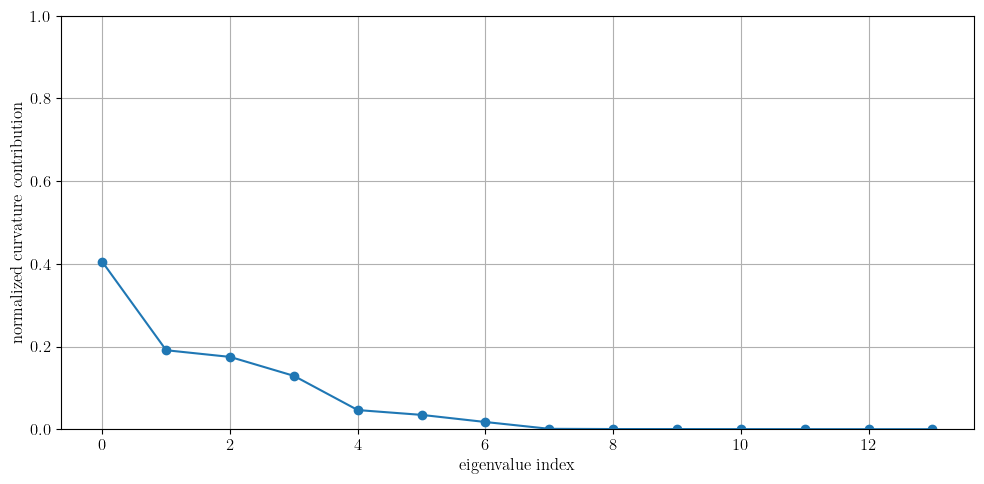

In [13]:
#x = test_set.x[3]
x = test_set.x[0:100]
if len(x.shape) == 1:
    x = x[None, :]
hessians = vmap(jax.hessian(ref_model.reference_fn()))(x)
mean_hessian = jnp.mean(hessians, axis=0)
eigenvalues, eigenvectors = jnp.linalg.eigh(mean_hessian)

largest_eigenvalue = jnp.max(jnp.abs(eigenvalues))
print("Largest eigenvalue of mean Hessian:", largest_eigenvalue)


explained_variance = eigenvalues**2 / jnp.sum(eigenvalues**2)
# sort in descending order
explained_variance = sorted(explained_variance)[::-1]
#print("Explained variance:", explained_variance)
#print("Mean Hessian eigenvalues:", eigenvalues)
#print("Mean Hessian eigenvectors:", eigenvectors)

import matplotlib.pyplot as plt

def plot_singular_spectrum(S_var):
    print("S_var:", S_var)
    fig = plt.figure(figsize=(10, 5))
    plt.plot(S_var, marker='o')
    plt.xlabel('eigenvalue index')
    plt.ylabel('normalized curvature contribution')
    plt.ylim(0, 1)
    plt.grid()
    plt.tight_layout()
    plt.show()
    return fig

fig = plot_singular_spectrum(explained_variance)

In [14]:
import time
now = time.strftime("%d%m_%H:%M")
fig.savefig(f"spectrum_heston7_{now}.pdf", bbox_inches='tight')

### mnist test stuff

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def plot_digit_bw(img):
    
    side_length = int(jnp.sqrt(img.shape[0]))
    gray = img.reshape(side_length, side_length)
    
    plt.figure(figsize=(3,3))
    plt.imshow(gray, cmap="gray", interpolation="nearest")
    plt.axis("off")           # turn off axis ticks
    plt.show()
    


def plot_dy_color(img, figsize=(3,3)):
    
    side_length = int(jnp.sqrt(img.shape[0]))
    arr = img.reshape(side_length, side_length)
    

    # create a 3‐color colormap: red at low end, grey at zero, green at high end
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "red_grey_green", 
        [("red"), ("lightgrey"), ("green")],
        N=256
    )
    # center the color scaling at zero
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)


    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap=cmap, norm=norm, interpolation="nearest")
    plt.axis("off")
    plt.show()



def plot_digit_with_changes(img, dy, alpha=0.6, figsize=(3,3)):
    
    side_length = int(jnp.sqrt(img.shape[0]))
    base = img.reshape(side_length, side_length)
    delta = dy.reshape(side_length, side_length)

    # red–grey–green colormap for changes
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "red_grey_green", ["red", "lightgrey", "green"], N=256
    )
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    plt.figure(figsize=figsize)
    # plot base digit in grayscale
    plt.imshow(base, cmap="gray", interpolation="nearest")
    # overlay changes
    plt.imshow(delta, cmap=cmap, norm=norm, interpolation="nearest", alpha=alpha)
    plt.axis("off")
    plt.show()




shapes:
x shape:  (128, 196)
y shape:  (128,)
dydx shape:  (128, 196)
ddyddx shape:  -
dddydddx shape:  -
(128,)
mask


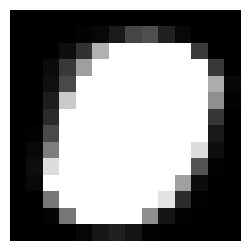

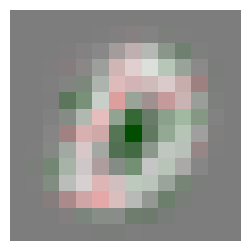

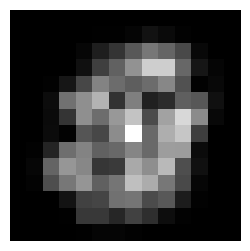

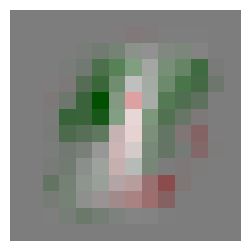

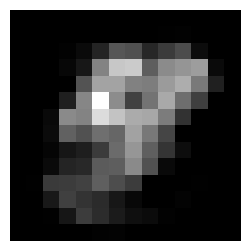

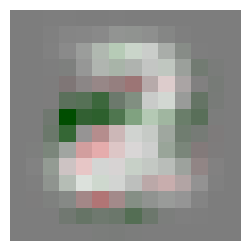

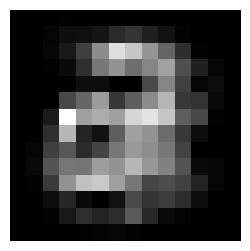

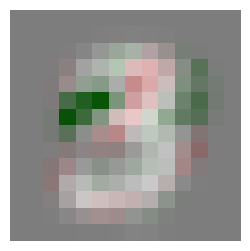

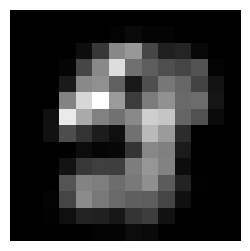

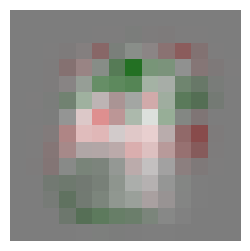

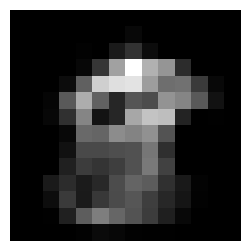

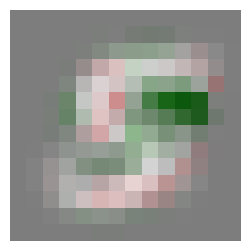

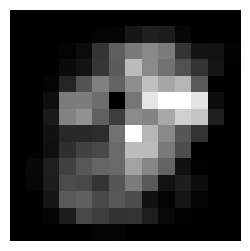

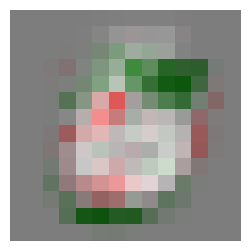

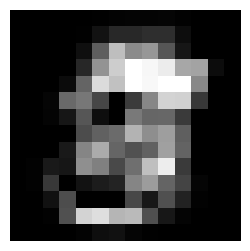

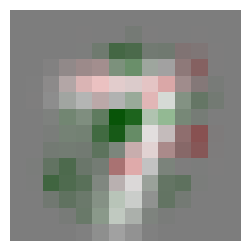

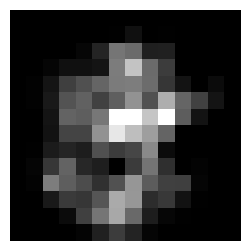

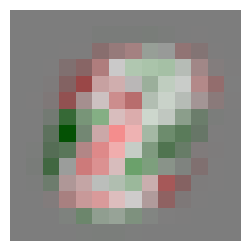

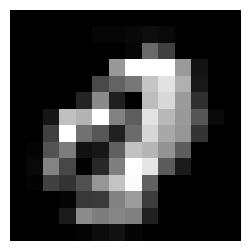

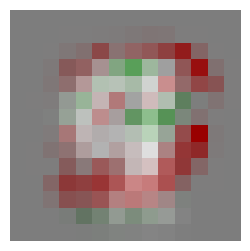

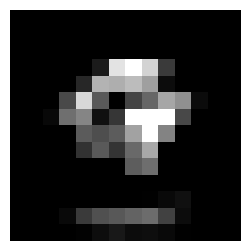

In [ ]:
from diff_ml.typing import DifferentialData

def norm(arr):

    return arr / jnp.max(jnp.abs(arr))

def visualize_data(dataset: DifferentialData, name: str):
    # TODO
    print("shapes:")
    print("x shape: ", dataset.x.shape)
    print("y shape: ", dataset.y.shape)
    print("dydx shape: ", "-" if dataset.dy == None  else dataset.dy.shape)
    print("ddyddx shape: ", "-" if dataset.ddy == None  else dataset.ddy.shape)
    print("dddydddx shape: ", "-" if dataset.dddy == None  else dataset.dddy.shape)


    # get CNN labels for all x
    x_raw = dataset.x.reshape(dataset.x.shape[0], *ref_model_mnist.un_flattened_shape)
    preds = jax.vmap(ref_model_mnist.cnn)(x_raw)
    labels = jnp.argmax(preds, axis=-1)
    print(labels.shape)

    zeros = jnp.zeros_like(dataset.x[0])
    ones = jnp.ones_like(dataset.x[0])
    
    y_and_dy_fn = jax.value_and_grad(ref_model_mnist.reference_fn())
    
    _, maximizing0 = y_and_dy_fn(zeros)
    maximizing0 = norm(maximizing0)
    #print("maximizing from 0")
    #plot_dy_color(maximizing0)

    _, maximizing1 = y_and_dy_fn(ones)
    maximizing1 = norm(maximizing1)
    #print("maximizing from 1")
    #plot_dy_color(maximizing1)

    maximizing = maximizing0 + maximizing1
    maximizing = norm(maximizing)
    #print("maximizing from both")
    #plot_dy_color(maximizing)


    avg_nine = jnp.mean(dataset.x[labels == 9], axis=0)    #plot_digit_bw(avg_nine)
    #print("avg nine")
    #plot_digit_bw(avg_nine)
    
    diff = avg_nine - maximizing
    #print("diff")
    #plot_dy_color(diff)
    

    _, avg_nine_dy = y_and_dy_fn(avg_nine)
    #print("avg nine dy")
    #plot_dy_color(avg_nine_dy)

    back = avg_nine_dy + diff
    #print("avg 9 dy + diff")
    #plot_digit_bw(back)
    
    
    nine_dys = dataset.dy[labels == 9]
    avg_nine_dy = jnp.mean(nine_dys, axis=0)
    
    avg_eight = jnp.mean(dataset.x[labels == 8], axis=0)
    avg_zero = jnp.mean(dataset.x[labels == 0], axis=0)
    
    mask = (avg_eight + avg_zero) / 2
    mask = jnp.minimum(1, mask*10)
    #mask = jnp.minimum(1, (avg_eight + avg_zero))
    #mask = jnp.mean(dataset.x, axis=0)
    #mask = jnp.minimum(1, jnp.sum(dataset.x, axis=0))
    
    #avg_nine_dy = avg_nine_dy*mask
    
    print("mask")
    plot_digit_bw(mask)
    #plot_dy_color(avg_nine_dy*mask)
    for i in range(10):
        i_digits = dataset.x[labels == i]
        avg_i = jnp.mean(i_digits, axis=0)
        #print("avg", i)
        #plot_digit_bw(avg_i)
    
        i_dys = dataset.dy[labels == i]
        avg_dy = jnp.mean(i_dys, axis=0)
        avg_dy = norm(avg_dy*mask)
        #print("avg dy", i)
        #plot_dy_color(avg_dy)
        
        #avg_dy = avg_dy*mask
        
        #avg_dy = avg_dy + diff
        #avg_dy = norm(avg_dy)
        #plot_dy_color(avg_dy)
        
        #print("avg_dy ", i)
        #plot_dy_color(avg_dy)
        #print("avg_nine ")
        #plot_dy_color(avg_nine_dy)
        #print("avg_dy - nine ", i)
        #plot_dy_color(avg_dy-avg_nine_dy)
    
    
        #avg_dy = avg_dy - avg_nine_dy
        
        #avg_dy = avg_dy * jnp.abs(avg_dy)
        
    
        plot_digit_with_changes(avg_i, avg_dy)
        
        applied = avg_i + avg_dy
        applied = jnp.maximum(0, jnp.minimum(1, applied))
        plot_digit_bw(applied)
        

visualize_data(dataset=test_set, name="mnist")

### rest

In [4]:
print(test_set.ddy[0])

[[ 1.6349599e-01  2.2258520e-01  0.0000000e+00 -3.5761256e-02
   0.0000000e+00 -3.5761252e-02  0.0000000e+00 -3.5761252e-02
   0.0000000e+00 -3.5761252e-02  0.0000000e+00 -3.5761256e-02
   0.0000000e+00 -3.5761256e-02]
 [ 2.2258516e-01 -1.7331429e-02 -3.5761256e-02  0.0000000e+00
  -3.5761252e-02  0.0000000e+00 -3.5761252e-02  0.0000000e+00
  -3.5761252e-02  0.0000000e+00 -3.5761256e-02  0.0000000e+00
  -3.5761256e-02  0.0000000e+00]
 [ 0.0000000e+00 -3.5761256e-02  4.6569034e-02  1.9816491e-01
   0.0000000e+00 -3.5761252e-02  0.0000000e+00 -3.5761252e-02
   0.0000000e+00 -3.5761252e-02  0.0000000e+00 -3.5761256e-02
   0.0000000e+00 -3.5761256e-02]
 [-3.5761256e-02  0.0000000e+00  1.9816490e-01 -8.9432794e-04
  -3.5761252e-02  0.0000000e+00 -3.5761252e-02  0.0000000e+00
  -3.5761252e-02  0.0000000e+00 -3.5761256e-02  0.0000000e+00
  -3.5761256e-02  0.0000000e+00]
 [ 0.0000000e+00 -3.5761256e-02  0.0000000e+00 -3.5761256e-02
   1.9909572e-02  2.0804478e-01  0.0000000e+00 -3.5761252e-02


shapes:
x shape:  (1024, 14)
y shape:  (1024,)
dydx shape:  (1024, 14)
ddyddx shape:  (1024, 14, 14)
dddydddx shape:  -


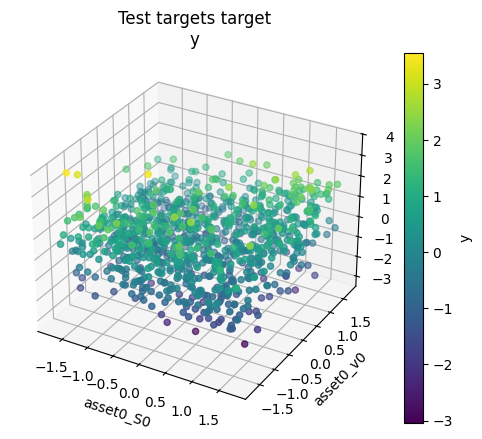

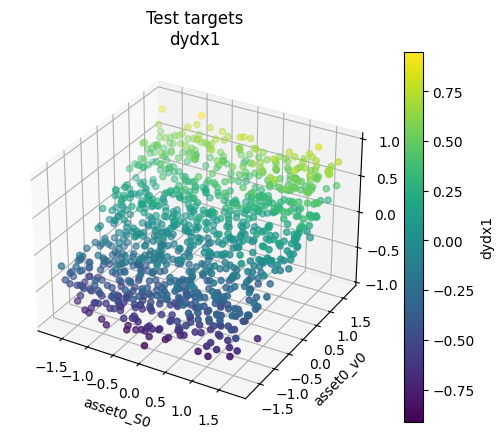

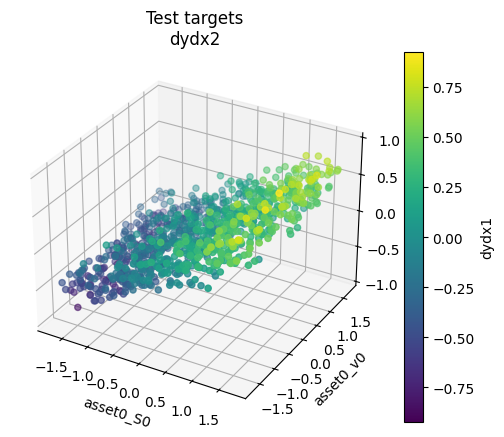

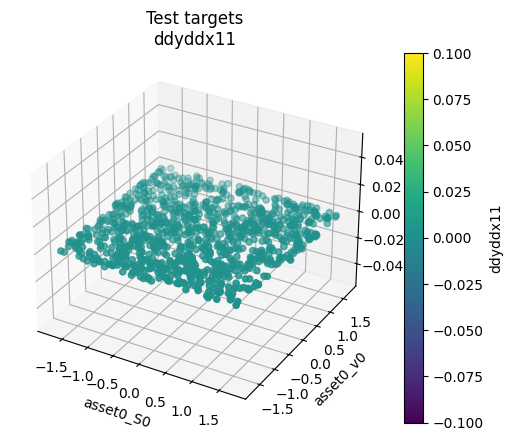

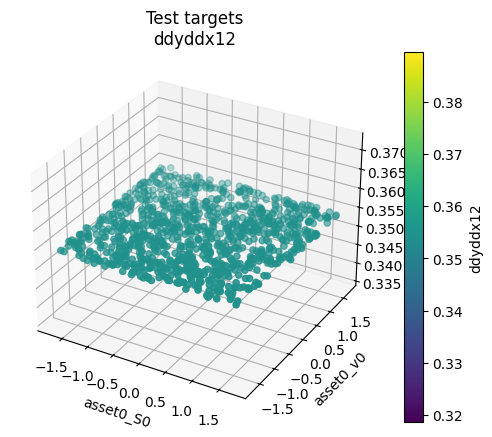

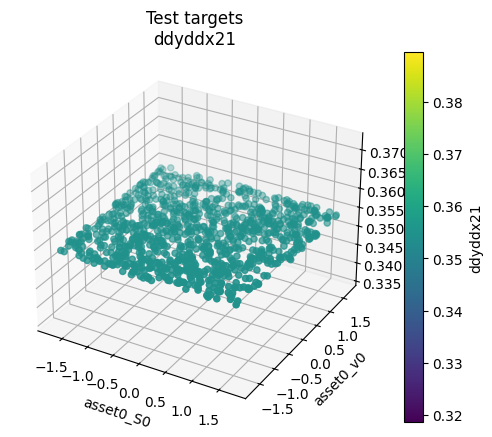

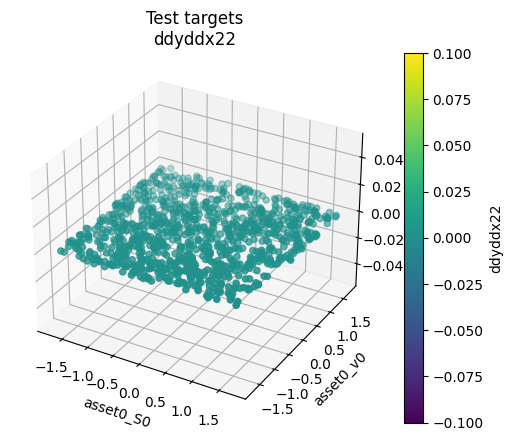

In [4]:
ref_model.visualize_data(test_set, name="Test targets")
#ref_model.visualize_dataset(train_sample_batch, name="Train", is_second_order=False)


In [ ]:

#ref_model.visualize_third(x=test_set[0], dddydddx=test_set[4], name="Test")


In [4]:




#variant = "value"
#variant = "1st"
#variant = "random"
#variant = "pcady"
variant = "batchSVD"
#variant = "3rdBatchSVD"
#variant = "perXSVD"
#variant = "streaming"
#variant = "fullHessian"


learnable_loss_weights = True
k = 2
streaming_r = 2

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#8#32#32 # 32
BATCH_SIZE = 256#16#256#256 # 256
key = jrandom.PRNGKey(42)



# nn model
input_dims = ref_model.n_dims
key, subkey = jax.random.split(key)
mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
mlp = init_linear_weight(mlp, trunc_init, subkey)
surrogate_model = mlp



if variant == "streaming":
    # sketch
    key, subkey = jax.random.split(key)
    sketch = StreamingHessianSketch(
                ref_model=ref_model,
                r=streaming_r,
                k=k, 
                key=subkey)
else:
    sketch = None

# TODO need normalization layers? at least for bachelier?
## Specify the surrogate model architecture
#key, subkey = jrandom.split(key)
#mlp = eqx.nn.MLP(key=subkey, in_size=n_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu) # jax.nn.silu
#key, subkey = jrandom.split(key)
#mlp = init_model_weights(mlp, jax.nn.initializers.glorot_normal(), key=subkey)
#surrogate = Normalized(
#    Normalization(x_train_mean, x_train_std), mlp, Denormalization(y_train_mean, y_train_std)
#)

optim = optax.adam(learning_rate=1e-3)
#opt_state = optim.init(eqx.filter(weighted_model, eqx.is_array))




weighted_model, iteration_datas, sketch, avg_time_per_batch = train(
                        model = surrogate_model, 
                        test_data=test_set,
                        optim=optim, 
                        n_epochs=n_epochs,
                        n_batches_per_epoch=n_batches_per_epoch,
                        batch_size=BATCH_SIZE,
                        ref_model=ref_model,
                        sketch=sketch,
                        variant=variant,
                        k=k,
                        learnable_loss_weights=learnable_loss_weights
                        )


Training for 100 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 1.71078 | Test Value Loss: 1.06330
Finished epoch 2 | Train Loss: 1.67386 | Test Value Loss: 0.97943
Finished epoch 3 | Train Loss: 1.59185 | Test Value Loss: 0.90074
Finished epoch 4 | Train Loss: 1.27453 | Test Value Loss: 0.76922
Finished epoch 5 | Train Loss: 0.82222 | Test Value Loss: 0.58655
Finished epoch 6 | Train Loss: 0.49535 | Test Value Loss: 0.49507
Finished epoch 7 | Train Loss: 0.41208 | Test Value Loss: 0.43522
Finished epoch 8 | Train Loss: 0.18917 | Test Value Loss: 0.39979
Finished epoch 9 | Train Loss: 0.00388 | Test Value Loss: 0.34775
Finished epoch 10 | Train Loss: -0.14017 | Test Value Loss: 0.29606
Finished epoch 11 | Train Loss: -0.23713 | Test Value Loss: 0.25445
Finished epoch 12 | Train Loss: -0.34232 | Test Value Loss: 0.22823
Finished epoch 13 | Train Loss: -0.42214 | Test Value Loss: 0.20430
Finished epoch 14 | Train Loss: -0.52625 | Test Value Loss: 0.19

In [5]:
from diff_ml.utils import rmse
# eval price predictions
test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(weighted_model))(test_set.x)

test_pred_ddys = vmap(jax.hessian(MakeScalar(weighted_model)))(test_set.x)
test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)


test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(weighted_model))))(test_set.x)
#test_pred_dddys = test_pred_dddys.reshape(test_set[4].shape)


print("Test predictions shapes:")
print("test_pred_ys shape: ", test_pred_ys.shape)
print("test_pred_dys shape: ", test_pred_dys.shape)
print("test_pred_ddys shape: ", test_pred_ddys.shape)
#print("test_pred_dddys shape: ", test_pred_dddys.shape)

print("")

y_error = rmse(test_pred_ys, test_set.y)
dy_error = rmse(test_pred_dys, test_set.dy)
ddy_error = rmse(test_pred_ddys, test_set.ddy)
#dddy_error = rmse(test_pred_dddys, test_set[4])

print(f"test y error: {y_error:.5f}")
print(f"test dy error: {dy_error:.5f}")
print(f"test ddy error: {ddy_error:.5f}")
#print(f"test dddy error: {dddy_error:.5f}")



Test predictions shapes:
test_pred_ys shape:  (1024,)
test_pred_dys shape:  (1024, 5)
test_pred_ddys shape:  (1024, 5, 5)

test y error: 0.01932
test dy error: 0.02493
test ddy error: 0.04086


### balancing factors plot

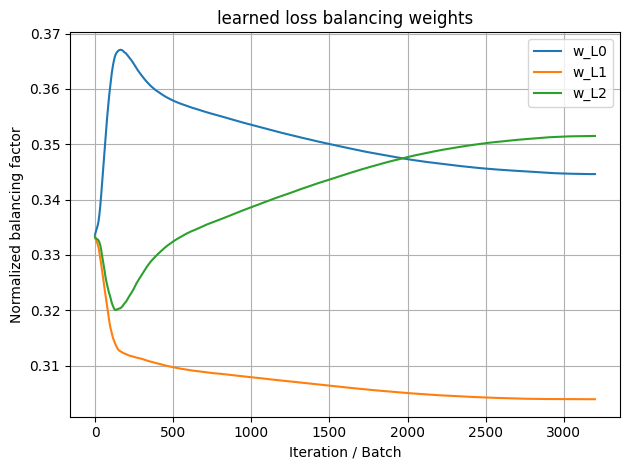

In [7]:
import matplotlib.pyplot as plt
ws = jnp.array([iteration_datas[t]["eff_w_norm"] for t in range(len(iteration_datas))])
active = (ws[0] != 0).astype(int)
ws = ws.T

for i, v in enumerate(active):
    if v:
        plt.plot(ws[i], label=f"w_L{i}")
        

plt.xlabel("Iteration / Batch")
plt.ylabel("Normalized balancing factor")
plt.title("learned loss balancing weights")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# Averaged Runs

In [2]:
def make_MNIST(key, test_set_order=2):
    ref_model = MNIST_ref(
        key=key, 
        scale=0.5,
        target_class=9
    )
    test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    return ref_model, test_set
    

def make_bachelier(key, test_set_order=2):
    
    basket_dim = 7
    ref_model = Bachelier(
        key,
        basket_dim=basket_dim, 
        weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

def make_heston(key, test_set_order=2):
    basket_dim = 7
    ref_model = Heston(
        key = key,
        basket_dim=basket_dim,
        basket_weights=jrandom.uniform(subkey, shape=(basket_dim,), minval=1.0, maxval=10.0)
    )
    if test_set_order ==3:
        test_set = ref_model.get_test_set(n_samples=128, order=test_set_order)
    else:
        test_set = ref_model.get_test_set(n_samples=2*1024, order=test_set_order)
    #y_std = test_set[4]["y_std"]
    #ref_model.set_y_std(y_std)
    return ref_model, test_set
    
def make_analytic(key, test_set_order=2):
    ref_model = Analytic(
        key=key,
        #type="RHE",
        #type="Rastrigin",
        #type="Rosenbrock",
        #type="Ackley",
        type="CubicRankR",
        d=20,
        min_x=-1,
        max_x=1
    )
    #RHE: min_x = -5.0, max_x = 5.0
    ##Rastrigin: min_x = -5.12, max_x = 5.12
    #Rosenbrock: min_x = -1.5, max_x = 2.5
    #Ackley: min_x = -5.0, max_x = 5.0
    #CubicRankR: min_x = -1.0, max_x = 1.0

    test_set = ref_model.get_test_set(n_samples=8*1024, order=test_set_order)
    return ref_model, test_set

### losses

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 1

n_epochs =  
n_batches_per_epoch = 32#8#32 # 32
BATCH_SIZE = 256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2



data = {}
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    print("running variant", variant)
    
    test_losses_values = []
    avg_times = []
 

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key)
        #ref_model, test_set = make_heston(key)
        #ref_model, test_set = make_MNIST(key)
        #ref_model, test_set = make_analytic(key)


        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        fn=ref_model.reference_fn(), 
                        ref_model=ref_model,
                        d=ref_model.n_dims, 
                        r=streaming_r,
                        k=k, 
                        key=subkey)

        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k
                                )
        
        test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
        #test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
        #test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
        #test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
        #train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])


    
        test_losses_values.append(test_losses_value)
        avg_times.append(avg_time_per_batch)

        

    # average the runs
    print("")
    test_losses_values = jnp.array(test_losses_values)

    test_losses_values_mean = test_losses_values.mean(axis=0)
    test_losses_values_std = test_losses_values.std(axis=0)

    avg_times_mean = jnp.mean(jnp.array(avg_times))
        


    data[variant] = {
        "test_losses_values": (test_losses_values_mean, test_losses_values_std),
        "avg_time_per_batch": avg_times_mean
    }

    



running variant value

run 1 / 1 for value
Training for 20 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.05097 | Test Value Loss: 0.19619
Finished epoch 2 | Train Loss: 0.01916 | Test Value Loss: 0.08216
Finished epoch 3 | Train Loss: 0.00886 | Test Value Loss: 0.05606
Finished epoch 4 | Train Loss: 0.00442 | Test Value Loss: 0.03340
Finished epoch 5 | Train Loss: 0.00410 | Test Value Loss: 0.02387
Finished epoch 6 | Train Loss: 0.00290 | Test Value Loss: 0.02405
Finished epoch 7 | Train Loss: 0.00326 | Test Value Loss: 0.02200
Finished epoch 8 | Train Loss: 0.00674 | Test Value Loss: 0.02288
Finished epoch 9 | Train Loss: 0.00352 | Test Value Loss: 0.02240
Finished epoch 10 | Train Loss: 0.00281 | Test Value Loss: 0.02619
Finished epoch 11 | Train Loss: 0.00206 | Test Value Loss: 0.01963
Finished epoch 12 | Train Loss: 0.00207 | Test Value Loss: 0.02486
Finished epoch 13 | Train Loss: 0.00225 | Test Value Loss: 0.01838
Finished epoch 14 | Train 

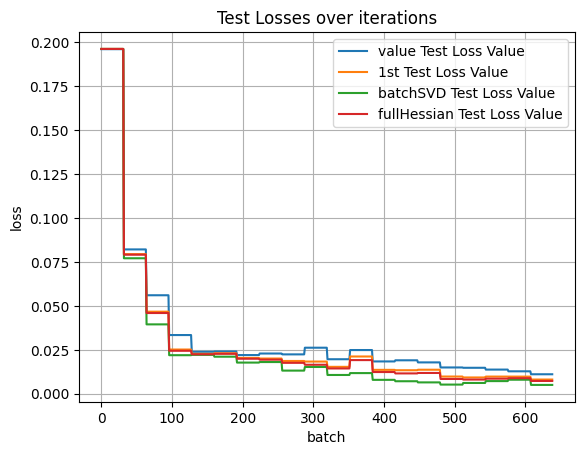

In [ ]:
#test_losses_value = jnp.array([iteration_datas[t]["test value loss"] for t in range(len(iteration_datas))])
#test_losses_grad = jnp.array([iteration_datas[t]["test grad loss"] for t in range(len(iteration_datas))])
#test_losses_hess = jnp.array([iteration_datas[t]["test hess loss"] for t in range(len(iteration_datas))])
#test_losses_proj_hess = jnp.array([iteration_datas[t]["test proj hess loss"] for t in range(len(iteration_datas))])
#train_losses = jnp.array([iteration_datas[t]["train loss"] for t in range(len(iteration_datas))])

#epoch_cap = 32*50
epoch_cap = -1

for variant in ["value", "1st", "batchSVD", "fullHessian"]:
#for variant in ["value", "1st", "random", "batchSVD", "perXSVD", "streaming", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    #test_losses_value_std = results["test_losses_values"][1]

    x = range(len(test_losses_value_mean))

    #plt.plot(x, train_losses, label='Train Loss', alpha=0.2)#, linestyle='-', marker='o')
    # Plot each of the three series
    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")#, linestyle='-', marker='o')
    #plt.plot(x, test_losses_grad, label='Test Loss Grad')#, linestyle='--', marker='s')
    #plt.plot(x, test_losses_hess, label='Test Loss Hess')#, linestyle=':', marker='^')
    #plt.plot(x, test_losses_proj_hess, label='Test Loss Proj Hess')#, linestyle=':', marker='^')


# Add labels & title
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('Test Losses over iterations')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


time per batch for value: 	0.00241s
time per batch for 1st: 	0.00260s
time per batch for batchSVD: 	0.00423s
time per batch for fullHessian: 	0.00554s


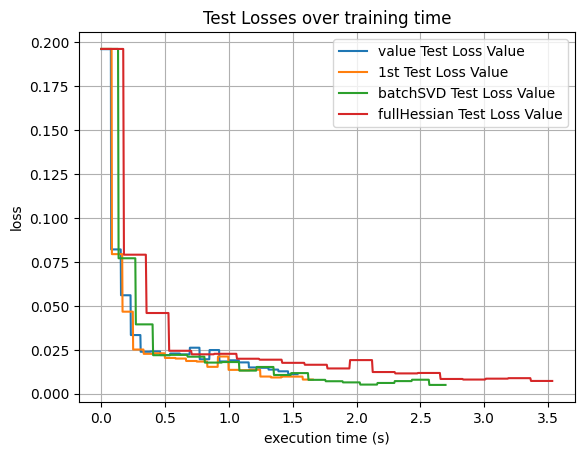

In [ ]:
for variant in ["value", "1st", "batchSVD", "fullHessian"]:
    results = data[variant]
    test_losses_value_mean = results["test_losses_values"][0][:epoch_cap]
    time_per_batch = results["avg_time_per_batch"]
    print(f"time per batch for {variant}: \t{time_per_batch:.5f}s")
    #x = range(len(test_losses_value_mean))


    # TODO scale x axis by time per batch
    # Scale x-axis by execution time
    x = [i * time_per_batch for i in range(len(test_losses_value_mean))]


    

    plt.plot(x, test_losses_value_mean, label=f"{variant} Test Loss Value")
    


# Add labels & title
plt.xlabel('execution time (s)')
plt.ylabel('loss')
plt.title('Test Losses over training time')

# Show a legend
plt.legend()

# Optionally turn on a grid
plt.grid(True)

# Display
plt.show()


### all variants

In [ ]:
main_key = jrandom.PRNGKey(42)


n_runs = 5

n_epochs = 100  # 200 for Heston single asset convergence
n_batches_per_epoch = 32#8#4#32#8#32 # 32
BATCH_SIZE = 256#16#8#256#16 #256 # 256

lr = 1e-3


k = 1
streaming_r = 2
test_set_order = 3
learnable_loss_weights = False
do_approx_metrics = True
do_test_eval = True



data = {}
for variant in ["batchSVD"]:
#for variant in ["streaming"]:
#for variant in ["3rdBatchSVD"]:
#for variant in ["value", "1st", "random", "pcady", "batchSVD", "perXSVD", "streaming", "fullHessian"]:#, "3rdBatchSVD"]:
    print("running variant", variant)
    
    y_errors = []
    dy_errors = []
    ddy_errors = []
    dddy_errors = []
    eFs = []
    e2s = []
    evrs = []
    engs = []
    avg_t_p_bs = []

    run_keys = jrandom.split(main_key, n_runs)
    for i, key in enumerate(run_keys):
        print("")
        print(f"run {i+1} / {n_runs} for {variant}")

        
        # reference model
        key, subkey = jax.random.split(key)

        ref_model, test_set = make_bachelier(key=key, test_set_order=test_set_order)
        #ref_model, test_set = make_heston(key, test_set_order=test_set_order)
        #ref_model, test_set = make_analytic(key, test_set_order=test_set_order)
        #ref_model, test_set = make_MNIST(key, test_set_order=test_set_order)
        

        
        
        # nn model
        key, subkey = jax.random.split(key)
        input_dims = ref_model.n_dims
        mlp = eqx.nn.MLP(key=subkey, in_size=input_dims, out_size="scalar", width_size=20, depth=3, activation=jax.nn.silu)
        mlp = init_linear_weight(mlp, trunc_init, subkey)
        surrogate_model = mlp
    
    
        # sketch
        sketch = None
        if variant == "streaming":
            key, subkey = jax.random.split(key)
            sketch = StreamingHessianSketch(
                        ref_model=ref_model,
                        r=streaming_r,
                        k=k, 
                        key=subkey)
        
    
        optim = optax.adam(learning_rate=lr)
    
    
        surrogate_model, iteration_datas, sketch, avg_time_per_batch = train(
                                model = surrogate_model, 
                                test_data=test_set,
                                optim=optim, 
                                n_epochs=n_epochs,
                                n_batches_per_epoch=n_batches_per_epoch,
                                batch_size=BATCH_SIZE,
                                ref_model=ref_model,
                                sketch=sketch,
                                variant=variant,
                                k=k,
                                learnable_loss_weights=learnable_loss_weights,
                                do_approx_metrics=do_approx_metrics,
                                do_test_eval=do_test_eval
                                )
        
    
        
        # eval price predictions
        test_pred_ys, test_pred_dys = vmap(jax.value_and_grad(surrogate_model))(test_set.x)
        test_pred_ddys = vmap(jax.hessian(MakeScalar(surrogate_model)))(test_set.x)
        test_pred_ddys = test_pred_ddys.reshape(test_set.ddy.shape)



        y_error = jnp.sqrt(mse(test_pred_ys, test_set.y))
        dy_error = jnp.sqrt(mse(test_pred_dys, test_set.dy))
        ddy_error = jnp.sqrt(mse(test_pred_ddys, test_set.ddy))

        if test_set_order > 2:
            test_pred_dddys = vmap(jax.jacfwd(jax.hessian(MakeScalar(surrogate_model))))(test_set.x)
            dddy_error = jnp.sqrt(mse(test_pred_dddys, test_set.dddy))        
        else:
            dddy_error = jnp.nan

        y_errors.append(y_error)
        dy_errors.append(dy_error)
        ddy_errors.append(ddy_error)
        dddy_errors.append(dddy_error)
        print(f"test y error: {y_error:.5f}")
        print(f"test dy error: {dy_error:.5f}")
        print(f"test ddy error: {ddy_error:.5f}")
        if test_set_order > 2:
            print(f"test dddy error: {dddy_error:.5f}")
    
        #print(iteration_datas[0])
        if "approximation metrics ref" in iteration_datas[0]:
            epochs = list(range(len(iteration_datas)))
            eF_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["eF mean"]  for t in epochs])
            e2_vals  = jnp.array([iteration_datas[t]["approximation metrics ref"]["e2 mean"]  for t in epochs])
            evr_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["evr mean"] for t in epochs])
            eng_vals = jnp.array([iteration_datas[t]["approximation metrics ref"]["eng mean"] for t in epochs])
            mean_eF  = jnp.nanmean(eF_vals)
            mean_e2  = jnp.nanmean(e2_vals)
            mean_evr = jnp.nanmean(evr_vals)
            mean_eng = jnp.nanmean(eng_vals)
        else:
            mean_eF  = 0.0
            mean_e2  = 0.0
            mean_evr = 0.0
            mean_eng = 0.0
        eFs.append(mean_eF)
        e2s.append(mean_e2)
        evrs.append(mean_evr)
        engs.append(mean_eng)
        print(f"eF: {mean_eF:.5f}")
        print(f"e2: {mean_e2:.5f}")
        print(f"evr: {mean_evr:.5f}")
        print(f"eng: {mean_eng:.5f}")
        avg_t_p_bs.append(avg_time_per_batch)
        print(f"avg time per batch: {avg_time_per_batch:.5f}")

    # average the runs
    print("")
    y_errors = jnp.array(y_errors)
    dy_errors = jnp.array(dy_errors)
    ddy_errors = jnp.array(ddy_errors)
    dddy_errors = jnp.array(dddy_errors)

    y_errors_mean = y_errors.mean()
    dy_errors_mean = dy_errors.mean()
    ddy_errors_mean = ddy_errors.mean()
    dddy_errors_mean = dddy_errors.mean()
    y_errors_std = y_errors.std()
    dy_errors_std = dy_errors.std()
    ddy_errors_std = ddy_errors.std()
    dddy_errors_std = dddy_errors.std()

    print(f"y errors: \tmean: {y_errors_mean:.5f} \tstd: {y_errors_std:.5f}")
    print(f"dy errors: \tmean: {dy_errors_mean:.5f} \tstd: {dy_errors_std:.5f}")
    print(f"ddy errors: \tmean: {ddy_errors_mean:.5f} \tstd: {ddy_errors_std:.5f}")
    if test_set_order > 2:
        print(f"dddy errors: \tmean: {dddy_errors_mean:.5f} \tstd: {dddy_errors_std:.5f}")


    eFs = jnp.array(eFs)
    e2s = jnp.array(e2s)
    evrs = jnp.array(evrs)
    engs = jnp.array(engs)

    eFs_mean = eFs.mean()
    e2s_mean = e2s.mean()
    evrs_mean = evrs.mean()
    engs_mean = engs.mean()
    eFs_std = eFs.std()
    e2s_std = e2s.std()
    evrs_std = evrs.std()
    engs_std = engs.std()

    print(f"eFs: \tmean: {eFs_mean:.5f} \tstd: {eFs_std:.5f}")
    print(f"e2s: \tmean: {e2s_mean:.5f} \tstd: {e2s_std:.5f}")
    print(f"evrs: \tmean: {evrs_mean:.5f} \tstd: {evrs_std:.5f}")
    print(f"engs: \tmean: {engs_mean:.5f} \tstd: {engs_std:.5f}")

    avg_t_p_bs = jnp.array(avg_t_p_bs)


    print(f"avg time per batch: {avg_t_p_bs.mean():.5f}")



        


    data[variant] = {
        "y errors":   (y_errors_mean, y_errors_std),
        "dy errors":  (dy_errors_mean, dy_errors_std),
        "ddy errors": (ddy_errors_mean, ddy_errors_std),
        "dddy errors": (dddy_errors_mean, dddy_errors_std),
        "eFs":  (eFs_mean, eFs_std),
        "e2s":  (e2s_mean, e2s_std),
        "evrs": (evrs_mean, evrs_std),
        "engs": (engs_mean, engs_std),
        "avg time per batch": avg_t_p_bs.mean(),
    }

    



running variant 3rdBatchSVD

run 1 / 5 for 3rdBatchSVD
Training for 100 epochs with 32 batches per epoch and batch size 256.
Finished epoch 1 | Train Loss: 0.14149 | Test Value Loss: 0.19628
Finished epoch 2 | Train Loss: 0.14582 | Test Value Loss: 0.06289
Finished epoch 3 | Train Loss: 0.17262 | Test Value Loss: 0.03928
Finished epoch 4 | Train Loss: 0.11867 | Test Value Loss: 0.02278
Finished epoch 5 | Train Loss: 0.13622 | Test Value Loss: 0.01935
Finished epoch 6 | Train Loss: 0.15002 | Test Value Loss: 0.01531
Finished epoch 7 | Train Loss: 0.13442 | Test Value Loss: 0.01910
Finished epoch 8 | Train Loss: 0.16103 | Test Value Loss: 0.01771
Finished epoch 9 | Train Loss: 0.11112 | Test Value Loss: 0.01375
Finished epoch 10 | Train Loss: 0.13703 | Test Value Loss: 0.01043
Finished epoch 11 | Train Loss: 0.15883 | Test Value Loss: 0.01704
Finished epoch 12 | Train Loss: 0.15947 | Test Value Loss: 0.01445
Finished epoch 13 | Train Loss: 0.14580 | Test Value Loss: 0.01039
Finished epoc

### formatting

In [4]:
key_map = {
    "y errors": "y_error",
    "dy errors": "dy_error",
    "ddy errors": "ddy_error",
    "eFs": "eFs",
    "e2s": "e2s",
    "evrs": "evrs",
    "engs": "engs",    
    "avg time per batch": "time_p_b"
}

variant_nicknames = {
    "3rdBatchSVD": "t3BatchSVD",
    "fullHessian": "fullHessian",
    "streaming": "streaming",
    "perXSVD": "perxRandSVD",
    "batchSVD": "batchRandSVD",
    "pcady": "pcady",
    "random": "random",
    "1st": "1st",
    "value": "value",
}

# variants that should only get y/dy/ddy errors
restricted_keys_variants = {"fullHessian", "1st", "value"}

def format_results(data, name):
    lines = []
    all_prefixes = []

    # Collect all var_prefix strings first
    for variant, results in reversed(list(data.items())):
        for k in results.keys():
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors"):
                continue
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix = f"{name}_{variant}_{suffix}"
            all_prefixes.append(var_prefix)

    # Find the maximum length for alignment
    max_len = max(len(p) for p in all_prefixes)
    max_len += 6 # account for '_mean'

    # Build the output with alignment
    for variant, results in reversed(list(data.items())):
        
        label = f"# {variant}"
        lines.append(label)
        variant_nickname = variant_nicknames.get(variant)

        for k, v in results.items():
            #(mean, std) = v
            if type(v) == tuple:
                mean, std = v 
            else:
                mean = v
                std = .0
            
            if variant in restricted_keys_variants and k not in ("y errors", "dy errors", "ddy errors", "avg time per batch"):
                continue
            if k in ("eFs", "e2s", "evrs", "engs"):
                offset = 0
            else:
                offset = 4
            suffix = key_map.get(k, k.replace(" ", "_"))
            var_prefix_mean = f"{name}_{variant_nickname}_{suffix}_mean"
            var_prefix_std = f"{name}_{variant_nickname}_{suffix}_std"
            
            # Pad with spaces so all "=" align
            lines.append(
                f"{var_prefix_mean.ljust(max_len)}, {var_prefix_std.ljust(max_len)} {''.ljust(offset)} = {mean:.5f}, {std:.5f}"
            )

        #lines.append("")  # blank line after each block

    return "\n".join(lines)
print(format_results(data, name="bachelier7"))

# 3rdBatchSVD
bachelier7_t3BatchSVD_y_error_mean      , bachelier7_t3BatchSVD_y_error_std             = 0.00913, 0.00390
bachelier7_t3BatchSVD_dy_error_mean     , bachelier7_t3BatchSVD_dy_error_std            = 0.00368, 0.00074
bachelier7_t3BatchSVD_ddy_error_mean    , bachelier7_t3BatchSVD_ddy_error_std           = 0.00337, 0.00076
bachelier7_t3BatchSVD_dddy_errors_mean  , bachelier7_t3BatchSVD_dddy_errors_std         = 0.00324, 0.00086
bachelier7_t3BatchSVD_eFs_mean          , bachelier7_t3BatchSVD_eFs_std             = 0.00068, 0.00003
bachelier7_t3BatchSVD_e2s_mean          , bachelier7_t3BatchSVD_e2s_std             = 0.00068, 0.00003
bachelier7_t3BatchSVD_evrs_mean         , bachelier7_t3BatchSVD_evrs_std            = 0.94057, 0.00578
bachelier7_t3BatchSVD_engs_mean         , bachelier7_t3BatchSVD_engs_std            = 0.94057, 0.00578
bachelier7_t3BatchSVD_time_p_b_mean     , bachelier7_t3BatchSVD_time_p_b_std            = 0.00441, 0.00000


### ojas results 1

In [ ]:
# batchSVD
Rosenbrock20_batchRandSVD_y_error_mean          , Rosenbrock20_batchRandSVD_y_error_std                 = 0.46215, 0.01280
Rosenbrock20_batchRandSVD_dy_error_mean         , Rosenbrock20_batchRandSVD_dy_error_std                = 0.33157, 0.00821
Rosenbrock20_batchRandSVD_ddy_error_mean        , Rosenbrock20_batchRandSVD_ddy_error_std               = 0.18079, 0.00282
Rosenbrock20_batchRandSVD_dddy_errors_mean      , Rosenbrock20_batchRandSVD_dddy_errors_std             = nan, nan
Rosenbrock20_batchRandSVD_eFs_mean              , Rosenbrock20_batchRandSVD_eFs_std                 = 0.91161, 0.00004
Rosenbrock20_batchRandSVD_e2s_mean              , Rosenbrock20_batchRandSVD_e2s_std                 = 0.93846, 0.00006
Rosenbrock20_batchRandSVD_evrs_mean             , Rosenbrock20_batchRandSVD_evrs_std                = 0.16804, 0.00008
Rosenbrock20_batchRandSVD_engs_mean             , Rosenbrock20_batchRandSVD_engs_std                = 0.16804, 0.00008
Rosenbrock20_batchRandSVD_time_p_b_mean         , Rosenbrock20_batchRandSVD_time_p_b_std                = 0.00378, 0.00000
# streaming
Rosenbrock20_streaming_y_error_mean             , Rosenbrock20_streaming_y_error_std                    = 0.46244, 0.01291
Rosenbrock20_streaming_dy_error_mean            , Rosenbrock20_streaming_dy_error_std                   = 0.33210, 0.00829
Rosenbrock20_streaming_ddy_error_mean           , Rosenbrock20_streaming_ddy_error_std                  = 0.18107, 0.00283
Rosenbrock20_streaming_dddy_errors_mean         , Rosenbrock20_streaming_dddy_errors_std                = nan, nan
Rosenbrock20_streaming_eFs_mean                 , Rosenbrock20_streaming_eFs_std                    = 0.87016, 0.00305
Rosenbrock20_streaming_e2s_mean                 , Rosenbrock20_streaming_e2s_std                    = 0.90183, 0.00354
Rosenbrock20_streaming_evrs_mean                , Rosenbrock20_streaming_evrs_std                   = 0.24163, 0.00527
Rosenbrock20_streaming_engs_mean                , Rosenbrock20_streaming_engs_std                   = 0.16454, 0.00318
Rosenbrock20_streaming_time_p_b_mean            , Rosenbrock20_streaming_time_p_b_std                   = 0.01921, 0.00000
# streamingLite
Rosenbrock20_None_y_error_mean                  , Rosenbrock20_None_y_error_std                         = 0.46585, 0.01205
Rosenbrock20_None_dy_error_mean                 , Rosenbrock20_None_dy_error_std                        = 0.33273, 0.00761
Rosenbrock20_None_ddy_error_mean                , Rosenbrock20_None_ddy_error_std                       = 0.18088, 0.00204
Rosenbrock20_None_dddy_errors_mean              , Rosenbrock20_None_dddy_errors_std                     = nan, nan
Rosenbrock20_None_eFs_mean                      , Rosenbrock20_None_eFs_std                         = 0.90595, 0.00060
Rosenbrock20_None_e2s_mean                      , Rosenbrock20_None_e2s_std                         = 0.93323, 0.00088
Rosenbrock20_None_evrs_mean                     , Rosenbrock20_None_evrs_std                        = 0.17827, 0.00111
Rosenbrock20_None_engs_mean                     , Rosenbrock20_None_engs_std                        = 0.17827, 0.00111
Rosenbrock20_None_time_p_b_mean                 , Rosenbrock20_None_time_p_b_std                        = 0.00370, 0.
# ExplorationExploitation
Rosenbrock20_None_y_error_mean                  , Rosenbrock20_None_y_error_std                         = 0.46274, 0.01254
Rosenbrock20_None_dy_error_mean                 , Rosenbrock20_None_dy_error_std                        = 0.33036, 0.00821
Rosenbrock20_None_ddy_error_mean                , Rosenbrock20_None_ddy_error_std                       = 0.17993, 0.00243
Rosenbrock20_None_dddy_errors_mean              , Rosenbrock20_None_dddy_errors_std                     = nan, nan
Rosenbrock20_None_eFs_mean                      , Rosenbrock20_None_eFs_std                         = 0.89085, 0.00157
Rosenbrock20_None_e2s_mean                      , Rosenbrock20_None_e2s_std                         = 0.91524, 0.00287
Rosenbrock20_None_evrs_mean                     , Rosenbrock20_None_evrs_std                        = 0.20525, 0.00287
Rosenbrock20_None_engs_mean                     , Rosenbrock20_None_engs_std                        = 0.20525, 0.00287
Rosenbrock20_None_time_p_b_mean                 , Rosenbrock20_None_time_p_b_std                        = 0.00368, 0.00000
# EE2
Rosenbrock20_None_y_error_mean                  , Rosenbrock20_None_y_error_std                         = 0.46293, 0.01255
Rosenbrock20_None_dy_error_mean                 , Rosenbrock20_None_dy_error_std                        = 0.33040, 0.00804
Rosenbrock20_None_ddy_error_mean                , Rosenbrock20_None_ddy_error_std                       = 0.17994, 0.00243
Rosenbrock20_None_dddy_errors_mean              , Rosenbrock20_None_dddy_errors_std                     = nan, nan
Rosenbrock20_None_eFs_mean                      , Rosenbrock20_None_eFs_std                         = 0.88871, 0.00034
Rosenbrock20_None_e2s_mean                      , Rosenbrock20_None_e2s_std                         = 0.91184, 0.00058
Rosenbrock20_None_evrs_mean                     , Rosenbrock20_None_evrs_std                        = 0.20909, 0.00059
Rosenbrock20_None_engs_mean                     , Rosenbrock20_None_engs_std                        = 0.20909, 0.00059
Rosenbrock20_None_time_p_b_mean                 , Rosenbrock20_None_time_p_b_std                        = 0.00393, 0.00000
# streamingOjasLite
Rosenbrock20_None_y_error_mean                  , Rosenbrock20_None_y_error_std                         = 0.46041, 0.01300
Rosenbrock20_None_dy_error_mean                 , Rosenbrock20_None_dy_error_std                        = 0.32971, 0.00807
Rosenbrock20_None_ddy_error_mean                , Rosenbrock20_None_ddy_error_std                       = 0.17994, 0.00281
Rosenbrock20_None_dddy_errors_mean              , Rosenbrock20_None_dddy_errors_std                     = nan, nan
Rosenbrock20_None_eFs_mean                      , Rosenbrock20_None_eFs_std                         = 0.88767, 0.00007
Rosenbrock20_None_e2s_mean                      , Rosenbrock20_None_e2s_std                         = 0.90999, 0.00013
Rosenbrock20_None_evrs_mean                     , Rosenbrock20_None_evrs_std                        = 0.21088, 0.00012
Rosenbrock20_None_engs_mean                     , Rosenbrock20_None_engs_std                        = 0.21088, 0.00012
Rosenbrock20_None_time_p_b_mean                 , Rosenbrock20_None_time_p_b_std                        = 0.00374, 0.00000
# streamingOjas
Rosenbrock20_None_y_error_mean                  , Rosenbrock20_None_y_error_std                         = 0.46041, 0.01300
Rosenbrock20_None_dy_error_mean                 , Rosenbrock20_None_dy_error_std                        = 0.32970, 0.00807
Rosenbrock20_None_ddy_error_mean                , Rosenbrock20_None_ddy_error_std                       = 0.17993, 0.00280
Rosenbrock20_None_dddy_errors_mean              , Rosenbrock20_None_dddy_errors_std                     = nan, nan
Rosenbrock20_None_eFs_mean                      , Rosenbrock20_None_eFs_std                         = 0.88761, 0.00007
Rosenbrock20_None_e2s_mean                      , Rosenbrock20_None_e2s_std                         = 0.90929, 0.00014
Rosenbrock20_None_evrs_mean                     , Rosenbrock20_None_evrs_std                        = 0.21099, 0.00012
Rosenbrock20_None_engs_mean                     , Rosenbrock20_None_engs_std                        = 0.21099, 0.00012
Rosenbrock20_None_time_p_b_mean                 , Rosenbrock20_None_time_p_b_std                        = 0.00371, 0.00000
# perXSVD
Rosenbrock20_perxRandSVD_y_error_mean           , Rosenbrock20_perxRandSVD_y_error_std                  = 0.46244, 0.01291
Rosenbrock20_perxRandSVD_dy_error_mean          , Rosenbrock20_perxRandSVD_dy_error_std                 = 0.33210, 0.00829
Rosenbrock20_perxRandSVD_ddy_error_mean         , Rosenbrock20_perxRandSVD_ddy_error_std                = 0.18107, 0.00283
Rosenbrock20_perxRandSVD_dddy_errors_mean       , Rosenbrock20_perxRandSVD_dddy_errors_std              = nan, nan
Rosenbrock20_perxRandSVD_eFs_mean               , Rosenbrock20_perxRandSVD_eFs_std                  = 0.73088, 0.00005
Rosenbrock20_perxRandSVD_e2s_mean               , Rosenbrock20_perxRandSVD_e2s_std                  = 0.80563, 0.00010
Rosenbrock20_perxRandSVD_evrs_mean              , Rosenbrock20_perxRandSVD_evrs_std                 = 0.46039, 0.00007
Rosenbrock20_perxRandSVD_engs_mean              , Rosenbrock20_perxRandSVD_engs_std                 = 0.16424, 0.00001
Rosenbrock20_perxRandSVD_time_p_b_mean          , Rosenbrock20_perxRandSVD_time_p_b_std                 = 0.03466, 0.00000

### ojas results 2

In [ ]:
# fullHessian
Heston7_fullHessian_y_error_mean           , Heston7_fullHessian_y_error_std                  = 0.02475, 0.00254
Heston7_fullHessian_dy_error_mean          , Heston7_fullHessian_dy_error_std                 = 0.01702, 0.00161
Heston7_fullHessian_ddy_error_mean         , Heston7_fullHessian_ddy_error_std                = 0.01241, 0.00115
Heston7_fullHessian_time_p_b_mean          , Heston7_fullHessian_time_p_b_std                 = 0.00381, 0.00000
# batchSVD
Heston7_batchRandSVD_y_error_mean          , Heston7_batchRandSVD_y_error_std                 = 0.02382, 0.00239
Heston7_batchRandSVD_dy_error_mean         , Heston7_batchRandSVD_dy_error_std                = 0.01606, 0.00141
Heston7_batchRandSVD_ddy_error_mean        , Heston7_batchRandSVD_ddy_error_std               = 0.01143, 0.00108
Heston7_batchRandSVD_dddy_errors_mean      , Heston7_batchRandSVD_dddy_errors_std             = nan, nan
Heston7_batchRandSVD_eFs_mean              , Heston7_batchRandSVD_eFs_std                 = 0.77226, 0.01490
Heston7_batchRandSVD_e2s_mean              , Heston7_batchRandSVD_e2s_std                 = 0.82540, 0.01506
Heston7_batchRandSVD_evrs_mean             , Heston7_batchRandSVD_evrs_std                = 0.39582, 0.02236
Heston7_batchRandSVD_engs_mean             , Heston7_batchRandSVD_engs_std                = 0.39582, 0.02236
Heston7_batchRandSVD_time_p_b_mean         , Heston7_batchRandSVD_time_p_b_std                = 0.00516, 0.00000
# streaming
Heston7_streaming_y_error_mean             , Heston7_streaming_y_error_std                    = 0.02475, 0.00254
Heston7_streaming_dy_error_mean            , Heston7_streaming_dy_error_std                   = 0.01702, 0.00161
Heston7_streaming_ddy_error_mean           , Heston7_streaming_ddy_error_std                  = 0.01241, 0.00115
Heston7_streaming_dddy_errors_mean         , Heston7_streaming_dddy_errors_std                = nan, nan
Heston7_streaming_eFs_mean                 , Heston7_streaming_eFs_std                    = 0.65246, 0.03020
Heston7_streaming_e2s_mean                 , Heston7_streaming_e2s_std                    = 0.67387, 0.03852
Heston7_streaming_evrs_mean                , Heston7_streaming_evrs_std                   = 0.56680, 0.03803
Heston7_streaming_engs_mean                , Heston7_streaming_engs_std                   = 0.42823, 0.02035
Heston7_streaming_time_p_b_mean            , Heston7_streaming_time_p_b_std                   = 0.02178, 0.00000
# streamingLite
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02381, 0.00231
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01614, 0.00135
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01145, 0.00103
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.70105, 0.02410
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.73816, 0.03568
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.49754, 0.02997
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.49754, 0.02997
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00539, 0.00000
# streamingOjasLiteExplorationExploitation
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02381, 0.00227
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01616, 0.00130
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01152, 0.00092
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.65070, 0.02224
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.69546, 0.03902
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.55359, 0.02791
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.55359, 0.02791
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00469, 0.00000
# EE2
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02379, 0.00226
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01616, 0.00131
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01152, 0.00092
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.65059, 0.02225
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.69541, 0.03907
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.55367, 0.02792
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.55367, 0.02792
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00480, 0.00000
# streamingOjasLite
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02383, 0.00229
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01617, 0.00131
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01152, 0.00092
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.65052, 0.02229
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.69536, 0.03915
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.55370, 0.02797
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.55370, 0.02797
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00436, 0.00000
# streamingOjas
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02390, 0.00228
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01618, 0.00130
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01153, 0.00091
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.65053, 0.02230
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.69536, 0.03914
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.55367, 0.02799
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.55367, 0.02799
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00541, 0.00000
# perXSVD
Heston7_perxRandSVD_y_error_mean           , Heston7_perxRandSVD_y_error_std                  = 0.02475, 0.00254
Heston7_perxRandSVD_dy_error_mean          , Heston7_perxRandSVD_dy_error_std                 = 0.01702, 0.00161
Heston7_perxRandSVD_ddy_error_mean         , Heston7_perxRandSVD_ddy_error_std                = 0.01241, 0.00115
Heston7_perxRandSVD_dddy_errors_mean       , Heston7_perxRandSVD_dddy_errors_std              = nan, nan
Heston7_perxRandSVD_eFs_mean               , Heston7_perxRandSVD_eFs_std                  = 0.69512, 0.01498
Heston7_perxRandSVD_e2s_mean               , Heston7_perxRandSVD_e2s_std                  = 0.74904, 0.01604
Heston7_perxRandSVD_evrs_mean              , Heston7_perxRandSVD_evrs_std                 = 0.50507, 0.01999
Heston7_perxRandSVD_engs_mean              , Heston7_perxRandSVD_engs_std                 = 0.35902, 0.01859
Heston7_perxRandSVD_time_p_b_mean          , Heston7_perxRandSVD_time_p_b_std                 = 0.03707, 0.00000

### ojas results 3

In [ ]:
# fullHessian
Heston7_fullHessian_y_error_mean           , Heston7_fullHessian_y_error_std                  = 0.02475, 0.00254
Heston7_fullHessian_dy_error_mean          , Heston7_fullHessian_dy_error_std                 = 0.01702, 0.00161
Heston7_fullHessian_ddy_error_mean         , Heston7_fullHessian_ddy_error_std                = 0.01241, 0.00115
Heston7_fullHessian_time_p_b_mean          , Heston7_fullHessian_time_p_b_std                 = 0.00380, 0.00000
# streamingOjasLite
Heston7_None_y_error_mean                  , Heston7_None_y_error_std                         = 0.02384, 0.00227
Heston7_None_dy_error_mean                 , Heston7_None_dy_error_std                        = 0.01616, 0.00130
Heston7_None_ddy_error_mean                , Heston7_None_ddy_error_std                       = 0.01152, 0.00092
Heston7_None_dddy_errors_mean              , Heston7_None_dddy_errors_std                     = nan, nan
Heston7_None_eFs_mean                      , Heston7_None_eFs_std                         = 0.65059, 0.02225
Heston7_None_e2s_mean                      , Heston7_None_e2s_std                         = 0.69541, 0.03907
Heston7_None_evrs_mean                     , Heston7_None_evrs_std                        = 0.55367, 0.02792
Heston7_None_engs_mean                     , Heston7_None_engs_std                        = 0.55367, 0.02792
Heston7_None_time_p_b_mean                 , Heston7_None_time_p_b_std                        = 0.00478, 0.00000
# batchSVD
Heston7_batchRandSVD_y_error_mean          , Heston7_batchRandSVD_y_error_std                 = 0.02377, 0.00241
Heston7_batchRandSVD_dy_error_mean         , Heston7_batchRandSVD_dy_error_std                = 0.01605, 0.00141
Heston7_batchRandSVD_ddy_error_mean        , Heston7_batchRandSVD_ddy_error_std               = 0.01143, 0.00108
Heston7_batchRandSVD_dddy_errors_mean      , Heston7_batchRandSVD_dddy_errors_std             = nan, nan
Heston7_batchRandSVD_eFs_mean              , Heston7_batchRandSVD_eFs_std                 = 0.77226, 0.01490
Heston7_batchRandSVD_e2s_mean              , Heston7_batchRandSVD_e2s_std                 = 0.82540, 0.01506
Heston7_batchRandSVD_evrs_mean             , Heston7_batchRandSVD_evrs_std                = 0.39582, 0.02236
Heston7_batchRandSVD_engs_mean             , Heston7_batchRandSVD_engs_std                = 0.39582, 0.02236
Heston7_batchRandSVD_time_p_b_mean         , Heston7_batchRandSVD_time_p_b_std                = 0.00516, 0.00000
# pcady
Heston7_pcady_y_error_mean                 , Heston7_pcady_y_error_std                        = 0.02381, 0.00229
Heston7_pcady_dy_error_mean                , Heston7_pcady_dy_error_std                       = 0.01610, 0.00135
Heston7_pcady_ddy_error_mean               , Heston7_pcady_ddy_error_std                      = 0.01145, 0.00098
Heston7_pcady_dddy_errors_mean             , Heston7_pcady_dddy_errors_std                    = nan, nan
Heston7_pcady_eFs_mean                     , Heston7_pcady_eFs_std                        = 0.65456, 0.02575
Heston7_pcady_e2s_mean                     , Heston7_pcady_e2s_std                        = 0.69936, 0.04366
Heston7_pcady_evrs_mean                    , Heston7_pcady_evrs_std                       = 0.55152, 0.03112
Heston7_pcady_engs_mean                    , Heston7_pcady_engs_std                       = 0.55152, 0.03112
Heston7_pcady_time_p_b_mean                , Heston7_pcady_time_p_b_std                       = 0.00504, 0.00000

In [ ]:
# fullHessian
Rosenbrock30_fullHessian_y_error_mean           , Rosenbrock30_fullHessian_y_error_std                  = 0.66985, 0.00974
Rosenbrock30_fullHessian_dy_error_mean          , Rosenbrock30_fullHessian_dy_error_std                 = 0.37007, 0.00492
Rosenbrock30_fullHessian_ddy_error_mean         , Rosenbrock30_fullHessian_ddy_error_std                = 0.14283, 0.00124
Rosenbrock30_fullHessian_time_p_b_mean          , Rosenbrock30_fullHessian_time_p_b_std                 = 0.00254, 0.00000
# streamingOjasLite
Rosenbrock30_None_y_error_mean                  , Rosenbrock30_None_y_error_std                         = 0.66985, 0.00981
Rosenbrock30_None_dy_error_mean                 , Rosenbrock30_None_dy_error_std                        = 0.36986, 0.00493
Rosenbrock30_None_ddy_error_mean                , Rosenbrock30_None_ddy_error_std                       = 0.14277, 0.00124
Rosenbrock30_None_dddy_errors_mean              , Rosenbrock30_None_dddy_errors_std                     = nan, nan
Rosenbrock30_None_eFs_mean                      , Rosenbrock30_None_eFs_std                         = 0.89898, 0.00015
Rosenbrock30_None_e2s_mean                      , Rosenbrock30_None_e2s_std                         = 0.92642, 0.00053
Rosenbrock30_None_evrs_mean                     , Rosenbrock30_None_evrs_std                        = 0.19095, 0.00026
Rosenbrock30_None_engs_mean                     , Rosenbrock30_None_engs_std                        = 0.19095, 0.00026
Rosenbrock30_None_time_p_b_mean                 , Rosenbrock30_None_time_p_b_std                        = 0.00393, 0.00000
# streamingOjasLite2
Rosenbrock30_None_y_error_mean                  , Rosenbrock30_None_y_error_std                         = 0.66968, 0.00967
Rosenbrock30_None_dy_error_mean                 , Rosenbrock30_None_dy_error_std                        = 0.36985, 0.00491
Rosenbrock30_None_ddy_error_mean                , Rosenbrock30_None_ddy_error_std                       = 0.14277, 0.00124
Rosenbrock30_None_dddy_errors_mean              , Rosenbrock30_None_dddy_errors_std                     = nan, nan
Rosenbrock30_None_eFs_mean                      , Rosenbrock30_None_eFs_std                         = 0.90317, 0.00116
Rosenbrock30_None_e2s_mean                      , Rosenbrock30_None_e2s_std                         = 0.93021, 0.00136
Rosenbrock30_None_evrs_mean                     , Rosenbrock30_None_evrs_std                        = 0.18355, 0.00208
Rosenbrock30_None_engs_mean                     , Rosenbrock30_None_engs_std                        = 0.18355, 0.00208
Rosenbrock30_None_time_p_b_mean                 , Rosenbrock30_None_time_p_b_std                        = 0.00381, 0.00000
# batchSVD
Rosenbrock30_batchRandSVD_y_error_mean          , Rosenbrock30_batchRandSVD_y_error_std                 = 0.66977, 0.00975
Rosenbrock30_batchRandSVD_dy_error_mean         , Rosenbrock30_batchRandSVD_dy_error_std                = 0.36995, 0.00491
Rosenbrock30_batchRandSVD_ddy_error_mean        , Rosenbrock30_batchRandSVD_ddy_error_std               = 0.14280, 0.00124
Rosenbrock30_batchRandSVD_dddy_errors_mean      , Rosenbrock30_batchRandSVD_dddy_errors_std             = nan, nan
Rosenbrock30_batchRandSVD_eFs_mean              , Rosenbrock30_batchRandSVD_eFs_std                 = 0.91972, 0.00007
Rosenbrock30_batchRandSVD_e2s_mean              , Rosenbrock30_batchRandSVD_e2s_std                 = 0.94578, 0.00008
Rosenbrock30_batchRandSVD_evrs_mean             , Rosenbrock30_batchRandSVD_evrs_std                = 0.15355, 0.00012
Rosenbrock30_batchRandSVD_engs_mean             , Rosenbrock30_batchRandSVD_engs_std                = 0.15355, 0.00012
Rosenbrock30_batchRandSVD_time_p_b_mean         , Rosenbrock30_batchRandSVD_time_p_b_std                = 0.00357, 0.00000
# pcady
Rosenbrock30_pcady_y_error_mean                 , Rosenbrock30_pcady_y_error_std                        = 0.66976, 0.00982
Rosenbrock30_pcady_dy_error_mean                , Rosenbrock30_pcady_dy_error_std                       = 0.36981, 0.00492
Rosenbrock30_pcady_ddy_error_mean               , Rosenbrock30_pcady_ddy_error_std                      = 0.14274, 0.00124
Rosenbrock30_pcady_dddy_errors_mean             , Rosenbrock30_pcady_dddy_errors_std                    = nan, nan
Rosenbrock30_pcady_eFs_mean                     , Rosenbrock30_pcady_eFs_std                        = 0.90751, 0.00005
Rosenbrock30_pcady_e2s_mean                     , Rosenbrock30_pcady_e2s_std                        = 0.93337, 0.00008
Rosenbrock30_pcady_evrs_mean                    , Rosenbrock30_pcady_evrs_std                       = 0.17574, 0.00009
Rosenbrock30_pcady_engs_mean                    , Rosenbrock30_pcady_engs_std                       = 0.17574, 0.00009
Rosenbrock30_pcady_time_p_b_mean                , Rosenbrock30_pcady_time_p_b_std                       = 0.00455, 0.00000

In [ ]:
# fullHessian
Rastrigin30_fullHessian_y_error_mean           , Rastrigin30_fullHessian_y_error_std                  = 0.88455, 0.02010
Rastrigin30_fullHessian_dy_error_mean          , Rastrigin30_fullHessian_dy_error_std                 = 2.31945, 0.03491
Rastrigin30_fullHessian_ddy_error_mean         , Rastrigin30_fullHessian_ddy_error_std                = 7.99330, 0.11198
Rastrigin30_fullHessian_time_p_b_mean          , Rastrigin30_fullHessian_time_p_b_std                 = 0.00252, 0.00000
# streamingOjasLite
Rastrigin30_None_y_error_mean                  , Rastrigin30_None_y_error_std                         = 0.88328, 0.02047
Rastrigin30_None_dy_error_mean                 , Rastrigin30_None_dy_error_std                        = 2.31957, 0.03492
Rastrigin30_None_ddy_error_mean                , Rastrigin30_None_ddy_error_std                       = 7.99325, 0.11199
Rastrigin30_None_dddy_errors_mean              , Rastrigin30_None_dddy_errors_std                     = nan, nan
Rastrigin30_None_eFs_mean                      , Rastrigin30_None_eFs_std                         = 0.93037, 0.00007
Rastrigin30_None_e2s_mean                      , Rastrigin30_None_e2s_std                         = 0.99758, 0.00002
Rastrigin30_None_evrs_mean                     , Rastrigin30_None_evrs_std                        = 0.13382, 0.00013
Rastrigin30_None_engs_mean                     , Rastrigin30_None_engs_std                        = 0.13382, 0.00013
Rastrigin30_None_time_p_b_mean                 , Rastrigin30_None_time_p_b_std                        = 0.00389, 0.00000
# streamingOjasLite2
Rastrigin30_None_y_error_mean                  , Rastrigin30_None_y_error_std                         = 0.88275, 0.02035
Rastrigin30_None_dy_error_mean                 , Rastrigin30_None_dy_error_std                        = 2.31965, 0.03494
Rastrigin30_None_ddy_error_mean                , Rastrigin30_None_ddy_error_std                       = 7.99322, 0.11198
Rastrigin30_None_dddy_errors_mean              , Rastrigin30_None_dddy_errors_std                     = nan, nan
Rastrigin30_None_eFs_mean                      , Rastrigin30_None_eFs_std                         = 0.93039, 0.00005
Rastrigin30_None_e2s_mean                      , Rastrigin30_None_e2s_std                         = 0.99614, 0.00007
Rastrigin30_None_evrs_mean                     , Rastrigin30_None_evrs_std                        = 0.13390, 0.00010
Rastrigin30_None_engs_mean                     , Rastrigin30_None_engs_std                        = 0.13390, 0.00010
Rastrigin30_None_time_p_b_mean                 , Rastrigin30_None_time_p_b_std                        = 0.00382, 0.00000
# batchSVD
Rastrigin30_batchRandSVD_y_error_mean          , Rastrigin30_batchRandSVD_y_error_std                 = 0.88364, 0.02037
Rastrigin30_batchRandSVD_dy_error_mean         , Rastrigin30_batchRandSVD_dy_error_std                = 2.31956, 0.03492
Rastrigin30_batchRandSVD_ddy_error_mean        , Rastrigin30_batchRandSVD_ddy_error_std               = 7.99325, 0.11198
Rastrigin30_batchRandSVD_dddy_errors_mean      , Rastrigin30_batchRandSVD_dddy_errors_std             = nan, nan
Rastrigin30_batchRandSVD_eFs_mean              , Rastrigin30_batchRandSVD_eFs_std                 = 0.93037, 0.00001
Rastrigin30_batchRandSVD_e2s_mean              , Rastrigin30_batchRandSVD_e2s_std                 = 0.99451, 0.00001
Rastrigin30_batchRandSVD_evrs_mean             , Rastrigin30_batchRandSVD_evrs_std                = 0.13410, 0.00003
Rastrigin30_batchRandSVD_engs_mean             , Rastrigin30_batchRandSVD_engs_std                = 0.13410, 0.00003
Rastrigin30_batchRandSVD_time_p_b_mean         , Rastrigin30_batchRandSVD_time_p_b_std                = 0.00352, 0.00000
# pcady
Rastrigin30_pcady_y_error_mean                 , Rastrigin30_pcady_y_error_std                        = 0.88457, 0.02017
Rastrigin30_pcady_dy_error_mean                , Rastrigin30_pcady_dy_error_std                       = 2.31945, 0.03491
Rastrigin30_pcady_ddy_error_mean               , Rastrigin30_pcady_ddy_error_std                      = 7.99330, 0.11198
Rastrigin30_pcady_dddy_errors_mean             , Rastrigin30_pcady_dddy_errors_std                    = nan, nan
Rastrigin30_pcady_eFs_mean                     , Rastrigin30_pcady_eFs_std                        = 0.93237, 0.00001
Rastrigin30_pcady_e2s_mean                     , Rastrigin30_pcady_e2s_std                        = 0.99251, 0.00001
Rastrigin30_pcady_evrs_mean                    , Rastrigin30_pcady_evrs_std                       = 0.13050, 0.00002
Rastrigin30_pcady_engs_mean                    , Rastrigin30_pcady_engs_std                       = 0.13050, 0.00002
Rastrigin30_pcady_time_p_b_mean                , Rastrigin30_pcady_time_p_b_std                       = 0.00458, 0.00000

### 3rd res 1

In [ ]:
# 3rdBatchSVD original
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.04352, 0.00651
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.02653, 0.00280
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01612, 0.00161
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00916, 0.00074
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77234, 0.01474
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.82549, 0.01503
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00462, 0.00000
# 3rdBatchSVD3
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.04359, 0.00646
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.02662, 0.00278
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01620, 0.00160
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00919, 0.00073
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77234, 0.01474
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.82549, 0.01503
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00466, 0.00000
# 3rdBatchSVDrandom
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.04389, 0.00634
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.02704, 0.00257
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01662, 0.00148
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00942, 0.00064
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77234, 0.01474
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.82549, 0.01503
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.39573, 0.02214
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00473, 0.00000

In [ ]:
# 3rdBatchSVD
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.15779, 0.00909
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.07234, 0.00458
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.02810, 0.00123
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00950, 0.00030
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00460, 0.00000

# 3rdBatchSVD3
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.15771, 0.00909
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.07229, 0.00457
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.02808, 0.00122
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00950, 0.00030
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00383, 0.00000

# 3rdBatchSVD rand
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.15819, 0.00924
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.07257, 0.00463
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.02822, 0.00123
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00956, 0.00030
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00365, 0.00000

In [ ]:
# L3 only

# 3rdBatchSVD
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.99410, 0.02056
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.49092, 0.00757
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.10978, 0.00179
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00004, 0.00000
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00456, 0.00000

# 3rdBatchSVD3
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.99476, 0.02015
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.49095, 0.00761
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.10978, 0.00179
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00004, 0.00001
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00371, 0.00000

# 3rdBatchSVDrandom
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.99377, 0.01943
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.49094, 0.00757
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.10978, 0.00179
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00003, 0.00001
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00355, 0.00000


# 3rdBatchSVD4
RHE20_t3BatchSVD_y_error_mean      , RHE20_t3BatchSVD_y_error_std             = 0.99476, 0.02015
RHE20_t3BatchSVD_dy_error_mean     , RHE20_t3BatchSVD_dy_error_std            = 0.49095, 0.00761
RHE20_t3BatchSVD_ddy_error_mean    , RHE20_t3BatchSVD_ddy_error_std           = 0.10978, 0.00179
RHE20_t3BatchSVD_dddy_errors_mean  , RHE20_t3BatchSVD_dddy_errors_std         = 0.00004, 0.00001
RHE20_t3BatchSVD_eFs_mean          , RHE20_t3BatchSVD_eFs_std             = 0.73174, 0.00041
RHE20_t3BatchSVD_e2s_mean          , RHE20_t3BatchSVD_e2s_std             = 0.88622, 0.00080
RHE20_t3BatchSVD_evrs_mean         , RHE20_t3BatchSVD_evrs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_engs_mean         , RHE20_t3BatchSVD_engs_std            = 0.46360, 0.00067
RHE20_t3BatchSVD_time_p_b_mean     , RHE20_t3BatchSVD_time_p_b_std            = 0.00436, 0.00000


### 3rd res 2

In [ ]:

# 3rdBatchSVDrandom
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 68.83578, 22.28011
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 5.42726, 1.17543
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.75024, 0.10825
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.03391, 0.00265
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.80954, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.86297, 0.00018
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00379, 0.00000

# 3rdBatchSVD3
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 41.77671, 20.98474
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 4.06669, 0.76649
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.62111, 0.06974
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.04118, 0.00299
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.80954, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.86297, 0.00018
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00381, 0.00000

# 3rdBatchSVD4
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 50.93715, 17.93242
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 4.58897, 0.76498
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.69893, 0.09968
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.03781, 0.00289
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.80954, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.86297, 0.00018
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.34251, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00493, 0.00000

In [ ]:


# 3rdBatchSVD3
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 1.48919, 0.47563
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.29278, 0.03444
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01768, 0.00143
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00502, 0.00043
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.65812, 0.02087
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.72529, 0.02366
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00427, 0.00000

# 3rdBatchSVD
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 1.46372, 0.49360
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.29464, 0.03934
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01737, 0.00132
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00497, 0.00043
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.65812, 0.02087
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.72529, 0.02366
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00502, 0.00000



# 3rdBatchSVDrandom
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 1.52255, 0.30068
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.30241, 0.04112
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01587, 0.00112
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00442, 0.00052
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.65812, 0.02087
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.72529, 0.02366
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00433, 0.00000


# 3rdBatchSVD4
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 1.54493, 0.46768
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.30196, 0.03690
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.01676, 0.00160
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00484, 0.00049
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.65812, 0.02087
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.72529, 0.02366
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.55702, 0.02687
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00493, 0.00000



In [ ]:
# 3rdBatchSVD3
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 25.50461, 9.89725
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 2.78919, 0.54944
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.47817, 0.05967
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.04332, 0.00306
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.90790, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.93552, 0.00012
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00356, 0.00000

# 3rdBatchSVDrandom
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 30.68381, 16.89013
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 2.99086, 1.01735
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.50803, 0.13724
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.03946, 0.00800
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.90790, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.93552, 0.00012
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00340, 0.00000

# 3rdBatchSVD4
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 26.52968, 14.82749
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 3.04936, 0.78120
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.49909, 0.12243
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.04138, 0.00287
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.90790, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.93552, 0.00012
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00484, 0.00000

# 3rdBatchSVD51
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 26.01128, 15.63515
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 2.93883, 0.69718
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.47389, 0.07363
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.04143, 0.00427
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.90790, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.93552, 0.00012
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00472, 0.00000

# 3rdBatchSVD52
Rosenbrock20_t3BatchSVD_y_error_mean      , Rosenbrock20_t3BatchSVD_y_error_std             = 31.69349, 17.10329
Rosenbrock20_t3BatchSVD_dy_error_mean     , Rosenbrock20_t3BatchSVD_dy_error_std            = 3.39836, 1.19404
Rosenbrock20_t3BatchSVD_ddy_error_mean    , Rosenbrock20_t3BatchSVD_ddy_error_std           = 0.53132, 0.12627
Rosenbrock20_t3BatchSVD_dddy_errors_mean  , Rosenbrock20_t3BatchSVD_dddy_errors_std         = 0.03837, 0.00638
Rosenbrock20_t3BatchSVD_eFs_mean          , Rosenbrock20_t3BatchSVD_eFs_std             = 0.90790, 0.00007
Rosenbrock20_t3BatchSVD_e2s_mean          , Rosenbrock20_t3BatchSVD_e2s_std             = 0.93552, 0.00012
Rosenbrock20_t3BatchSVD_evrs_mean         , Rosenbrock20_t3BatchSVD_evrs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_engs_mean         , Rosenbrock20_t3BatchSVD_engs_std            = 0.17463, 0.00012
Rosenbrock20_t3BatchSVD_time_p_b_mean     , Rosenbrock20_t3BatchSVD_time_p_b_std            = 0.00715, 0.00000

### 3rd res 3

In [ ]:
# cubic rank r


# 3rdBatchSVD random
CubicRankR20_t3BatchSVD_y_error_mean      , CubicRankR20_t3BatchSVD_y_error_std             = 0.23247, 0.00440
CubicRankR20_t3BatchSVD_dy_error_mean     , CubicRankR20_t3BatchSVD_dy_error_std            = 0.17457, 0.00398
CubicRankR20_t3BatchSVD_ddy_error_mean    , CubicRankR20_t3BatchSVD_ddy_error_std           = 0.08916, 0.00383
CubicRankR20_t3BatchSVD_dddy_errors_mean  , CubicRankR20_t3BatchSVD_dddy_errors_std         = 0.03597, 0.00221
CubicRankR20_t3BatchSVD_eFs_mean          , CubicRankR20_t3BatchSVD_eFs_std             = 0.00041, 0.00000
CubicRankR20_t3BatchSVD_e2s_mean          , CubicRankR20_t3BatchSVD_e2s_std             = 0.00043, 0.00000
CubicRankR20_t3BatchSVD_evrs_mean         , CubicRankR20_t3BatchSVD_evrs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_engs_mean         , CubicRankR20_t3BatchSVD_engs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_time_p_b_mean     , CubicRankR20_t3BatchSVD_time_p_b_std            = 0.00328, 0.00000


# 3rdBatchSVD3
CubicRankR20_t3BatchSVD_y_error_mean      , CubicRankR20_t3BatchSVD_y_error_std             = 0.23093, 0.00486
CubicRankR20_t3BatchSVD_dy_error_mean     , CubicRankR20_t3BatchSVD_dy_error_std            = 0.17128, 0.00431
CubicRankR20_t3BatchSVD_ddy_error_mean    , CubicRankR20_t3BatchSVD_ddy_error_std           = 0.08189, 0.00241
CubicRankR20_t3BatchSVD_dddy_errors_mean  , CubicRankR20_t3BatchSVD_dddy_errors_std         = 0.02825, 0.00166
CubicRankR20_t3BatchSVD_eFs_mean          , CubicRankR20_t3BatchSVD_eFs_std             = 0.00041, 0.00000
CubicRankR20_t3BatchSVD_e2s_mean          , CubicRankR20_t3BatchSVD_e2s_std             = 0.00043, 0.00000
CubicRankR20_t3BatchSVD_evrs_mean         , CubicRankR20_t3BatchSVD_evrs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_engs_mean         , CubicRankR20_t3BatchSVD_engs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_time_p_b_mean     , CubicRankR20_t3BatchSVD_time_p_b_std            = 0.00335, 0.00000

# 3rdBatchSVDoriginal
CubicRankR20_t3BatchSVD_y_error_mean      , CubicRankR20_t3BatchSVD_y_error_std             = 0.23094, 0.00486
CubicRankR20_t3BatchSVD_dy_error_mean     , CubicRankR20_t3BatchSVD_dy_error_std            = 0.17128, 0.00431
CubicRankR20_t3BatchSVD_ddy_error_mean    , CubicRankR20_t3BatchSVD_ddy_error_std           = 0.08188, 0.00241
CubicRankR20_t3BatchSVD_dddy_errors_mean  , CubicRankR20_t3BatchSVD_dddy_errors_std         = 0.02825, 0.00166
CubicRankR20_t3BatchSVD_eFs_mean          , CubicRankR20_t3BatchSVD_eFs_std             = 0.00041, 0.00000
CubicRankR20_t3BatchSVD_e2s_mean          , CubicRankR20_t3BatchSVD_e2s_std             = 0.00043, 0.00000
CubicRankR20_t3BatchSVD_evrs_mean         , CubicRankR20_t3BatchSVD_evrs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_engs_mean         , CubicRankR20_t3BatchSVD_engs_std            = 0.99926, 0.00000
CubicRankR20_t3BatchSVD_time_p_b_mean     , CubicRankR20_t3BatchSVD_time_p_b_std            = 0.00390, 0.00000

### bachelier sim

In [ ]:
# batchSVD analytical basket price derivatives
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00302, 0.00212
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00151, 0.00057
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.00153, 0.00057
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.00240, 0.00111
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 1.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.99857, 0.00005
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00527, 0.00000


# batchSVD simulated  n_paths=1
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00676, 0.00322
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00893, 0.00422
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01041, 0.00407
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01137, 0.00280
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00368, 0.00000


# batchSVD simulated  n_paths=100
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00676, 0.00322
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00893, 0.00422
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01041, 0.00407
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01137, 0.00280
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00356, 0.00000

# batchSVD simulated  n_paths=100000
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00676, 0.00322
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00893, 0.00422
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01041, 0.00407
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01137, 0.00280
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00362, 0.00000


# batchSVD simulated2 n_paths=100000
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00673, 0.00322
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00893, 0.00423
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01039, 0.00408
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01136, 0.00281
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00336, 0.00000

# batchSVD simulated2 n_paths=1
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00675, 0.00321
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00894, 0.00423
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01039, 0.00408
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01136, 0.00281
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00336, 0.00000


# batchSVD
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.01179, 0.00705
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.01454, 0.00738
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.01528, 0.00700
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.01176, 0.00310
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00000, 0.00000
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.00000, 0.00000
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00338, 0.00000


# batchSVD smoothed fixed ranfdom 1000
bachelier7_batchRandSVD_y_error_mean , bachelier7_batchRandSVD_y_error_std        = 0.00133, 0.00041
bachelier7_batchRandSVD_dy_error_mean, bachelier7_batchRandSVD_dy_error_std       = 0.00157, 0.00044
bachelier7_batchRandSVD_ddy_error_mean, bachelier7_batchRandSVD_ddy_error_std      = 0.00188, 0.00047
bachelier7_batchRandSVD_dddy_errors_mean, bachelier7_batchRandSVD_dddy_errors_std      = 0.00220, 0.00044
bachelier7_batchRandSVD_eFs_mean     , bachelier7_batchRandSVD_eFs_std        = 0.00068, 0.00003
bachelier7_batchRandSVD_e2s_mean     , bachelier7_batchRandSVD_e2s_std        = 0.00068, 0.00003
bachelier7_batchRandSVD_evrs_mean    , bachelier7_batchRandSVD_evrs_std       = 0.94057, 0.00578
bachelier7_batchRandSVD_engs_mean    , bachelier7_batchRandSVD_engs_std       = 0.94057, 0.00578
bachelier7_batchRandSVD_time_p_b_mean, bachelier7_batchRandSVD_time_p_b_std       = 0.00318, 0.00000


### heston sim

### 0 template

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean  , bachelier_fullHessian_y_error_std         = 0., 0.
bachelier_fullHessian_dy_error_mean , bachelier_fullHessian_dy_error_std        = 0., 0.
bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std       = 0., 0.
# streaming
bachelier_streaming_y_error_mean    , bachelier_streaming_y_error_std           = 0., 0.
bachelier_streaming_dy_error_mean   , bachelier_streaming_dy_error_std          = 0., 0.
bachelier_streaming_ddy_error_mean  , bachelier_streaming_ddy_error_std         = 0., 0.
bachelier_streaming_eFs_mean        , bachelier_streaming_eFs_std           = 0., 0.
bachelier_streaming_e2s_mean        , bachelier_streaming_e2s_std           = 0., 0.
bachelier_streaming_evrs_mean       , bachelier_streaming_evrs_std          = 0., 0.
bachelier_streaming_engs_mean       , bachelier_streaming_engs_std          = 0., 0.
# perXSVD
bachelier_perxRandSVD_y_error_mean  , bachelier_perxRandSVD_y_error_std         = 0., 0.
bachelier_perxRandSVD_dy_error_mean , bachelier_perxRandSVD_dy_error_std        = 0., 0.
bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std       = 0., 0.
bachelier_perxRandSVD_eFs_mean      , bachelier_perxRandSVD_eFs_std         = 0., 0.
bachelier_perxRandSVD_e2s_mean      , bachelier_perxRandSVD_e2s_std         = 0., 0.
bachelier_perxRandSVD_evrs_mean     , bachelier_perxRandSVD_evrs_std        = 0., 0.
bachelier_perxRandSVD_engs_mean     , bachelier_perxRandSVD_engs_std        = 0., 0.
# batchSVD
bachelier_batchRandSVD_y_error_mean , bachelier_batchRandSVD_y_error_std        = 0., 0.
bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std       = 0., 0.
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std     = 0., 0.
bachelier_batchRandSVD_eFs_mean     , bachelier_batchRandSVD_eFs_std        = 0., 0.
bachelier_batchRandSVD_e2s_mean     , bachelier_batchRandSVD_e2s_std        = 0., 0.
bachelier_batchRandSVD_evrs_mean    , bachelier_batchRandSVD_evrs_std       = 0., 0.
bachelier_batchRandSVD_engs_mean    , bachelier_batchRandSVD_engs_std       = 0., 0.
# random
bachelier_random_y_error_mean       , bachelier_random_y_error_std              = 0., 0.
bachelier_random_dy_error_mean      , bachelier_random_dy_error_std             = 0., 0.
bachelier_random_ddy_error_mean     , bachelier_random_ddy_error_std            = 0., 0.
bachelier_random_eFs_mean           , bachelier_random_eFs_std              = 0., 0.
bachelier_random_e2s_mean           , bachelier_random_e2s_std              = 0., 0.
bachelier_random_evrs_mean          , bachelier_random_evrs_std             = 0., 0.
bachelier_random_engs_mean          , bachelier_random_engs_std             = 0., 0.
# 1st
bachelier_1st_y_error_mean          , bachelier_1st_y_error_std                 = 0., 0.
bachelier_1st_dy_error_mean         , bachelier_1st_dy_error_std                = 0., 0.
bachelier_1st_ddy_error_mean        , bachelier_1st_ddy_error_std               = 0., 0.
# value
bachelier_value_y_error_mean        , bachelier_value_y_error_std               = 0., 0.
bachelier_value_dy_error_mean       , bachelier_value_dy_error_std              = 0., 0.
bachelier_value_ddy_error_mean      , bachelier_value_ddy_error_std             = 0., 0.


# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0., 0.
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0., 0.
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0., 0.
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0., 0.
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0., 0.
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0., 0.
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0., 0.
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0., 0.
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0., 0.
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0., 0.
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0., 0.
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0., 0.
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0., 0.
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0., 0.
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0., 0.
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0., 0.
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0., 0.
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0., 0.
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0., 0.
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0., 0.
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0., 0.
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0., 0.
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0., 0.
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0., 0.
heston1_random_eFs_mean, heston1_random_eFs_std    = 0., 0.
heston1_random_e2s_mean, heston1_random_e2s_std    = 0., 0.
heston1_random_evrs_mean, heston1_random_evrs_std  = 0., 0.
heston1_random_engs_mean, heston1_random_engs_std  = 0., 0.
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0., 0.
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0., 0.
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0., 0.
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0., 0.
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0., 0.
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0., 0.


# TODO another run with k=2
# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0., 0.
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0., 0.
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0., 0.
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0., 0.
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0., 0.
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0., 0.
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0., 0.
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0., 0.
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0., 0.
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0., 0.
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0., 0.
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0., 0.
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0., 0.
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0., 0.
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0., 0.
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0., 0.
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0., 0.
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0., 0.
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0., 0.
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0., 0.
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0., 0.
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0., 0.
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0., 0.
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0., 0.
heston2_random_eFs_mean, heston2_random_eFs_std    = 0., 0.
heston2_random_e2s_mean, heston2_random_e2s_std    = 0., 0.
heston2_random_evrs_mean, heston2_random_evrs_std  = 0., 0.
heston2_random_engs_mean, heston2_random_engs_std  = 0., 0.
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0., 0.
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0., 0.
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0., 0.
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0., 0.
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0., 0.
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0., 0.



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0., 0.
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0., 0.
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0., 0.
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0., 0.
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0., 0.
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0., 0.
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0., 0.
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0., 0.
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0., 0.
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0., 0.
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0., 0.
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0., 0.
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0., 0.
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0., 0.
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0., 0.
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0., 0.
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0., 0.
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0., 0.
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0., 0.
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0., 0.
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0., 0.
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0., 0.
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0., 0.
heston22_random_eFs_mean, heston22_random_eFs_std    = 0., 0.
heston22_random_e2s_mean, heston22_random_e2s_std    = 0., 0.
heston22_random_evrs_mean, heston22_random_evrs_std  = 0., 0.
heston22_random_engs_mean, heston22_random_engs_std  = 0., 0.
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0., 0.
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0., 0.
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0., 0.
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0., 0.
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0., 0.
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0., 0.



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.






# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0., 0.
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0., 0.
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0., 0.
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0., 0.
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0., 0.
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0., 0.
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0., 0.
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0., 0.
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0., 0.
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0., 0.
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0., 0.
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0., 0.
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0., 0.
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0., 0.
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0., 0.
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0., 0.
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0., 0.
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0., 0.
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0., 0.
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0., 0.
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0., 0.
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0., 0.
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0., 0.
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0., 0.
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0., 0.
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0., 0.
heston7i_random_engs_mean, heston7i_random_engs_std  = 0., 0.
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0., 0.
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0., 0.
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0., 0.
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0., 0.
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0., 0.
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0., 0.





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0., 0.
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0., 0.
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0., 0.
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0., 0.
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0., 0.
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0., 0.
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0., 0.
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0., 0.
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0., 0.
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0., 0.
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0., 0.
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0., 0.
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0., 0.
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0., 0.
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0., 0.
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0., 0.
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0., 0.
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0., 0.
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0., 0.
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0., 0.




### 1st results

In [ ]:
# Bachelier basket dim 7
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00348, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 1.48164, 0.01228
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = jnp.nan, jnp.nan
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = jnp.nan, jnp.nan
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean, eFs_std =   jnp.nan, jnp.nan
bachelier_streaming_e2s_mean, e2s_std =   jnp.nan, jnp.nan
bachelier_streaming_evrs_mean, evrs_std = jnp.nan, jnp.nan
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00272, 0.00141
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 1.48152, 0.01215
bachelier_perxRandSVD_eFs_mean, eFs_std = 0.00007, 0.00002
bachelier_perxRandSVD_eFs_mean, eFs_std = 0.00000, 0.00000
bachelier_perxRandSVD_eFs_mean, eFs_std = 1.00000, 0.00000
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00270, 0.00138
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00147, 0.00035
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 1.48154, 0.01215
bachelier_batchRandSVD_eFs_mean, eFs_std = 0.00014, 0.00006
bachelier_batchRandSVD_eFs_mean, eFs_std = 0.00000, 0.00000
bachelier_batchRandSVD_eFs_mean, eFs_std = 1.00000, 0.00000
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00401, 0.00151
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00082
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 1.48246, 0.01236
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 1.48471, 0.01221


# Heston basket dim 1
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00119, 0.00015
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00335, 0.00052
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.01289, 0.00162
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = jnp.nan, jnp.nan
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = jnp.nan, jnp.nan
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = jnp.nan, jnp.nan
heston1_streaming_eFs_mean, eFs_std     = jnp.nan, jnp.nan
heston1_streaming_e2s_mean, e2s_std     = jnp.nan, jnp.nan
heston1_streaming_evrs_mean, evrs_std   = jnp.nan, jnp.nan
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.12736, 0.00671
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.17628, 0.01013
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.13891, 0.00724
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00163, 0.00046
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00456, 0.00120
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.01679, 0.00382
heston1_batchRandSVD_eFs_mean, eFs_std = 0.03666, 0.00093
heston1_batchRandSVD_eFs_mean, eFs_std = 0.03693, 0.00093
heston1_batchRandSVD_eFs_mean, eFs_std = 0.99053, 0.00067
# 2nd order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00314, 0.00072
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.01061, 0.00234
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.03245, 0.00719
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00712, 0.00085
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02548, 0.00216
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.06640, 0.00556


# Heston basket dim 2
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.10999, 0.02529
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.17072, 0.04539
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.22854, 0.03608
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = jnp.nan, jnp.nan
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = jnp.nan, jnp.nan
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = jnp.nan, jnp.nan
heston2_streaming_eFs_mean, eFs_std     = jnp.nan, jnp.nan
heston2_streaming_e2s_mean, e2s_std     = jnp.nan, jnp.nan
heston2_streaming_evrs_mean, evrs_std   = jnp.nan, jnp.nan

# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.14575, 0.01984
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.15630, 0.02036
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.50978, 0.14320
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean, eFs_std = jnp.nan, jnp.nan
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.01516, 0.00164
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.02477, 0.00147
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.53714, 0.14063
heston2_batchRandSVD_eFs_mean, eFs_std = 0.01747, 0.00949
heston2_batchRandSVD_eFs_mean, eFs_std = 0.01749, 0.00949
heston2_batchRandSVD_eFs_mean, eFs_std = 0.99534, 0.00336
# 2nd order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00903, 0.00108
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01748, 0.00195
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.54086, 0.14087
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.01230, 0.00128
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02424, 0.00207
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.53884, 0.14154


# MNIST
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0.18107, 0.02290
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.06878, 0.00664
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.07007, 0.02046
mnist_streaming_eFs_mean, eFs_std = 0.79500, 0.03392
mnist_streaming_e2s_mean, e2s_std = 0.75567, 0.03817
mnist_streaming_evrs_mean, evrs_std = 0.35374, 0.05000
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0.17684, 0.02047
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.07267, 0.00823
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.06441, 0.01877
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0.17728, 0.02052
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.07152, 0.00819
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.06435, 0.01877
mnist_perxRandSVD_eFs_mean, eFs_std = 0.11194, 0.00337
mnist_perxRandSVD_eFs_mean, eFs_std = 0.06416, 0.01028
mnist_perxRandSVD_eFs_mean, eFs_std = 0.99469, 0.01180
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0.17737, 0.02054
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.07138, 0.00823
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.06435, 0.01878
mnist_batchRandSVD_eFs_mean, eFs_std = 0., 0.
mnist_batchRandSVD_eFs_mean, eFs_std = 0.78527, 0.01036
mnist_batchRandSVD_eFs_mean, eFs_std = 0., 0.
# 2nd order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0.17684, 0.02047
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.07265, 0.00822
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.06443, 0.01880
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0.13059, 0.01979
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.11465, 0.01498
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.07448, 0.01791



# Analytic RHE
# streaming sketch r=5, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.20802, 0.00601
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.15519, 0.00450
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.06780, 0.00193
analyticRHE_streaming_eFs_mean, eFs_std = 0.67559, 0.01955
analyticRHE_streaming_e2s_mean, e2s_std = 0.79362, 0.04693
analyticRHE_streaming_evrs_mean, evrs_std = 0.54320, 0.02649
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.05591, 0.00367
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.04254, 0.00251
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.02825, 0.00178
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.17085, 0.00557
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.14192, 0.00269
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.06776, 0.00234
analyticRHE_perxRandSVD_eFs_mean, eFs_std = 0.74060, 0.00004
analyticRHE_perxRandSVD_e2s_mean, e2s_std = 0.87299, 0.00005
analyticRHE_perxRandSVD_evrs_mean, evrs_std = 0.45041, 0.00006
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.05508, 0.00366
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.04158, 0.00247
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.02738, 0.00171
analyticRHE_batchRandSVD_eFs_mean, eFs_std = 0.74076, 0.00045
analyticRHE_batchRandSVD_e2s_mean, e2s_std = 0.87340, 0.00110
analyticRHE_batchRandSVD_evrs_mean, evrs_std = 0.45015, 0.00065
# 2nd order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.05957, 0.00395
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.04595, 0.00271
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.03101, 0.00206
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05957, 0.00395
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04595, 0.00271
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.03101, 0.00206



### 2nd 1/3 results

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00349, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 0.00340, 0.00074
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = 0.00270, 0.00143
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = 0.00147, 0.00036
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = 0.00145, 0.00030
bachelier_streaming_eFs_mean, bachelier_streaming_eFs_std   = 0.00023, 0.00005
bachelier_streaming_e2s_mean, bachelier_streaming_e2s_std   = 0.00023, 0.00005
bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std = 1.00000, 0.00000
bachelier_streaming_engs_mean, bachelier_streaming_engs_std = 0.99713, 0.00014
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00272, 0.00140
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00149, 0.00035
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_perxRandSVD_eFs_mean, bachelier_perxRandSVD_eFs_std     = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean, bachelier_perxRandSVD_e2s_std     = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std   = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean, bachelier_perxRandSVD_engs_std   = 0.99707, 0.00024
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00269, 0.00146
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00148, 0.00037
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_batchRandSVD_eFs_mean, bachelier_batchRandSVD_eFs_std    = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean, bachelier_batchRandSVD_e2s_std    = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std  = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean, bachelier_batchRandSVD_engs_std  = 0.99858, 0.00006
# random directions k=1
bachelier_random_y_error_mean,     bachelier_random_y_error_std   = 0.00350, 0.00172
bachelier_random_dy_error_mean,    bachelier_random_dy_error_std  = 0.00240, 0.00061
bachelier_random_ddy_error_mean,   bachelier_random_ddy_error_std = 0.00340, 0.00074
bachelier_random_eFs_mean, bachelier_random_eFs_std      = 0.91988, 0.00176
bachelier_random_e2s_mean, bachelier_random_e2s_std      = 0.91988, 0.00176
bachelier_random_evrs_mean, bachelier_random_evrs_std    = 0.14363, 0.00283
bachelier_random_engs_mean, bachelier_random_engs_std    = 0.14343, 0.00283
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00399, 0.00146
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00082
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 0.00541, 0.00096
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 0.00831, 0.00088



# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00085, 0.00017
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00200, 0.00037
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.00815, 0.00133
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0.00106, 0.00027
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0.00282, 0.00078
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0.01180, 0.00350
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0.83305, 0.00013
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0.83336, 0.00013
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0.24716, 0.00015
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0.24466, 0.00016
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.00093, 0.00026
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.00178, 0.00037
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.00633, 0.00101
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0.99896, 0.00002
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0.99928, 0.00001
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0.00192, 0.00003
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0.00190, 0.00003
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00126, 0.00040
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00293, 0.00069
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.00991, 0.00190
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0.99898, 0.00002
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0.99929, 0.00001
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0.00189, 0.00003
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0.00189, 0.00003
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0.00104, 0.00026
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0.00165, 0.00034
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0.00625, 0.00097
heston1_random_eFs_mean, heston1_random_eFs_std    = 0.99898, 0.00002
heston1_random_e2s_mean, heston1_random_e2s_std    = 0.99929, 0.00001
heston1_random_evrs_mean, heston1_random_evrs_std  = 0.00189, 0.00003
heston1_random_engs_mean, heston1_random_engs_std  = 0.00189, 0.00003
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00165, 0.00041
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.00572, 0.00120
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.02052, 0.00354
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00563, 0.00080
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02094, 0.00243
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.05673, 0.00617



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.10846, 0.02492
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.16920, 0.04384
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.22968, 0.03769
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0.01296, 0.00135
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0.02110, 0.00123
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0.54266, 0.14017
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0., 0.
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0., 0.
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0., 0.
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.19163, 0.03578
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.25231, 0.05482
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.15052, 0.02067
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0., 0.
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0., 0.
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0., 0.
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.18509, 0.03311
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.24430, 0.05210
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.15722, 0.02331
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0., 0.
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0., 0.
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0., 0.
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0., 0.
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0.15331, 0.02874
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0.21331, 0.04749
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0.18312, 0.03120
heston2_random_eFs_mean, heston2_random_eFs_std    = 0., 0.
heston2_random_e2s_mean, heston2_random_e2s_std    = 0., 0.
heston2_random_evrs_mean, heston2_random_evrs_std  = 0., 0.
heston2_random_engs_mean, heston2_random_engs_std  = 0., 0.
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00586, 0.00096
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01192, 0.00182
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.54432, 0.13979
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.00971, 0.00120
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02081, 0.00211
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.53971, 0.14115



# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 1.12795, 0.08516
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.56311, 0.02843
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.13290, 0.00997
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 1.12568, 0.08543
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.56311, 0.02847
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.13250, 0.00990
mnist_streaming_eFs_mean, mnist_streaming_eFs_std =   0.79909, 0.02194
mnist_streaming_e2s_mean, mnist_streaming_e2s_std =   0.77617, 0.03045
mnist_streaming_evrs_mean, mnist_streaming_evrs_std = 0.35789, 0.03450
mnist_streaming_engs_mean, mnist_streaming_evrs_std = 0.28981, 0.02832
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 1.09861, 0.08632
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.55786, 0.02721
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.13024, 0.00896
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std     = 0.75002, 0.01145
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_eFs_std     = 0.71025, 0.00876
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_eFs_std    = 0.42580, 0.01629
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_eFs_std    = 0.20570, 0.01224
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 1.10332, 0.08872
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.55759, 0.02630
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.12930, 0.00888
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std    = 0.87245, 0.00800
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_eFs_std    = 0.86427, 0.00858
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_eFs_std   = 0.23708, 0.01382
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_eFs_std   = 0.23708, 0.01382
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 1.12824, 0.08493
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0.56186, 0.02807
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0.13218, 0.00983
mnist_random_eFs_mean, mnist_random_eFs_std  = 0.98717, 0.00008
mnist_random_e2s_mean, mnist_random_e2s_std  = 0.98755, 0.00012
mnist_random_evrs_mean, mnist_random_eFs_std = 0.02544, 0.00016
mnist_random_engs_mean, mnist_random_eFs_std = 0.02544, 0.00016
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 1.12795, 0.08512
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.56326, 0.02847
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.13300, 0.01000
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 1.12670, 0.08809
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.62078, 0.03780
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.13501, 0.01049



# TODO redo for k=3
# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.03841, 0.00304
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.02901, 0.00166
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.01949, 0.00131
# streaming sketch r=2, k=1
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.03761, 0.00250
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.02838, 0.00135
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.01884, 0.00107
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=1
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.03744, 0.00301
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.02808, 0.00161
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.01861, 0.00120
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=1
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.03746, 0.00287
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.02807, 0.00159
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.01861, 0.00120
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=1
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0.03826, 0.00287
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0.02900, 0.00164
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0.01950, 0.00130
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.04193, 0.00309
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.03217, 0.00179
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.02224, 0.00155
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05254, 0.00336
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04244, 0.00262
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.02976, 0.00251



### 3rd fixed scaling and normalization

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# full hessian
bachelier_fullHessian_y_error_mean,     bachelier_fullHessian_y_error_std   = 0.00347, 0.00168
bachelier_fullHessian_dy_error_mean,    bachelier_fullHessian_dy_error_std  = 0.00240, 0.00058
bachelier_fullHessian_ddy_error_mean,   bachelier_fullHessian_ddy_error_std = 0.00340, 0.00074
# streaming sketch r=2, k=1
bachelier_streaming_y_error_mean,     bachelier_streaming_y_error_std   = 0.00273, 0.00139
bachelier_streaming_dy_error_mean,    bachelier_streaming_dy_error_std  = 0.00148, 0.00036
bachelier_streaming_ddy_error_mean,   bachelier_streaming_ddy_error_std = 0.00145, 0.00030
bachelier_streaming_eFs_mean, bachelier_streaming_eFs_std   = 0.00023, 0.00005
bachelier_streaming_e2s_mean, bachelier_streaming_e2s_std   = 0.00023, 0.00005
bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std = 1.00000, 0.00000
bachelier_streaming_engs_mean, bachelier_streaming_engs_std = 0.99713, 0.00014
# per x rand SVD directions k=1
bachelier_perxRandSVD_y_error_mean,     bachelier_perxRandSVD_y_error_std   = 0.00275, 0.00142
bachelier_perxRandSVD_dy_error_mean,    bachelier_perxRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_perxRandSVD_ddy_error_mean,   bachelier_perxRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_perxRandSVD_eFs_mean, bachelier_perxRandSVD_eFs_std     = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean, bachelier_perxRandSVD_e2s_std     = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std   = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean, bachelier_perxRandSVD_engs_std   = 0.99707, 0.00024
# batch rand SVD directions k=1
bachelier_batchRandSVD_y_error_mean,     bachelier_batchRandSVD_y_error_std   = 0.00274, 0.00144
bachelier_batchRandSVD_dy_error_mean,    bachelier_batchRandSVD_dy_error_std  = 0.00148, 0.00036
bachelier_batchRandSVD_ddy_error_mean,   bachelier_batchRandSVD_ddy_error_std = 0.00145, 0.00030
bachelier_batchRandSVD_eFs_mean, bachelier_batchRandSVD_eFs_std    = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean, bachelier_batchRandSVD_e2s_std    = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std  = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean, bachelier_batchRandSVD_engs_std  = 0.99858, 0.00006
# random directions k=1
bachelier_random_y_error_mean,     bachelier_random_y_error_std   = 0.00348, 0.00165
bachelier_random_dy_error_mean,    bachelier_random_dy_error_std  = 0.00240, 0.00060
bachelier_random_ddy_error_mean,   bachelier_random_ddy_error_std = 0.00340, 0.00074
bachelier_random_eFs_mean, bachelier_random_eFs_std      = 0.91988, 0.00176
bachelier_random_e2s_mean, bachelier_random_e2s_std      = 0.91988, 0.00176
bachelier_random_evrs_mean, bachelier_random_evrs_std    = 0.14363, 0.00283
bachelier_random_engs_mean, bachelier_random_engs_std    = 0.14343, 0.00283
# 1st order
bachelier_1st_y_error_mean,     bachelier_1st_y_error_std   = 0.00403, 0.00154
bachelier_1st_dy_error_mean,    bachelier_1st_dy_error_std  = 0.00367, 0.00083
bachelier_1st_ddy_error_mean,   bachelier_1st_ddy_error_std = 0.00541, 0.00096
# value loss
bachelier_value_y_error_mean,     bachelier_value_y_error_std   = 0.00465, 0.00094
bachelier_value_dy_error_mean,    bachelier_value_dy_error_std  = 0.00592, 0.00079
bachelier_value_ddy_error_mean,   bachelier_value_ddy_error_std = 0.00831, 0.00088



# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston1_fullHessian_y_error_mean,     heston1_fullHessian_y_error_std   = 0.00083, 0.00019
heston1_fullHessian_dy_error_mean,    heston1_fullHessian_dy_error_std  = 0.00199, 0.00038
heston1_fullHessian_ddy_error_mean,   heston1_fullHessian_ddy_error_std = 0.00815, 0.00133
# streaming sketch r=2, k=1
heston1_streaming_y_error_mean,     heston1_streaming_y_error_std   = 0.00115, 0.00042
heston1_streaming_dy_error_mean,    heston1_streaming_dy_error_std  = 0.00285, 0.00080
heston1_streaming_ddy_error_mean,   heston1_streaming_ddy_error_std = 0.01187, 0.00354
heston1_streaming_eFs_mean, heston1_streaming_eFs_std     = 0.00207, 0.00003
heston1_streaming_e2s_mean, heston1_streaming_e2s_std     = 0.00228, 0.00004
heston1_streaming_evrs_mean, heston1_streaming_evrs_std   = 0.99936, 0.00002
heston1_streaming_engs_mean, heston1_streaming_engs_std   = 0.99487, 0.00005
# per x rand SVD directions k=1
heston1_perxRandSVD_y_error_mean,     heston1_perxRandSVD_y_error_std   = 0.00110, 0.00021
heston1_perxRandSVD_dy_error_mean,    heston1_perxRandSVD_dy_error_std  = 0.00285, 0.00077
heston1_perxRandSVD_ddy_error_mean,   heston1_perxRandSVD_ddy_error_std = 0.01187, 0.00354
heston1_perxRandSVD_eFs_mean, heston1_perxRandSVD_eFs_std   = 0.02305, 0.00007
heston1_perxRandSVD_e2s_mean, heston1_perxRandSVD_e2s_std   = 0.02331, 0.00008
heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std = 0.99475, 0.00005
heston1_perxRandSVD_engs_mean, heston1_perxRandSVD_engs_std = 0.99321, 0.00005
# batch rand SVD directions k=1
heston1_batchRandSVD_y_error_mean,     heston1_batchRandSVD_y_error_std   = 0.00111, 0.00030
heston1_batchRandSVD_dy_error_mean,    heston1_batchRandSVD_dy_error_std  = 0.00284, 0.00079
heston1_batchRandSVD_ddy_error_mean,   heston1_batchRandSVD_ddy_error_std = 0.01187, 0.00353
heston1_batchRandSVD_eFs_mean, heston1_batchRandSVD_eFs_std      = 0.03674, 0.00094
heston1_batchRandSVD_e2s_mean, heston1_batchRandSVD_e2s_std      = 0.03700, 0.00093
heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std    = 0.99065, 0.00075
heston1_batchRandSVD_engs_mean, heston1_batchRandSVD_engs_std    = 0.99065, 0.00075
# random directions k=1
heston1_random_y_error_mean,     heston1_random_y_error_std   = 0.00098, 0.00025
heston1_random_dy_error_mean,    heston1_random_dy_error_std  = 0.00208, 0.00037
heston1_random_ddy_error_mean,   heston1_random_ddy_error_std = 0.00837, 0.00132
heston1_random_eFs_mean, heston1_random_eFs_std    = 0.63373, 0.00326
heston1_random_e2s_mean, heston1_random_e2s_std    = 0.63402, 0.00326
heston1_random_evrs_mean, heston1_random_evrs_std  = 0.50341, 0.00314
heston1_random_engs_mean, heston1_random_engs_std  = 0.50341, 0.00314
# 1st order
heston1_1st_y_error_mean,     heston1_1st_y_error_std   = 0.00167, 0.00041
heston1_1st_dy_error_mean,    heston1_1st_dy_error_std  = 0.00572, 0.00120
heston1_1st_ddy_error_mean,   heston1_1st_ddy_error_std = 0.02052, 0.00354
# value loss
heston1_value_y_error_mean,     heston1_value_y_error_std   = 0.00563, 0.00080
heston1_value_dy_error_mean,    heston1_value_dy_error_std  = 0.02094, 0.00243
heston1_value_ddy_error_mean,   heston1_value_ddy_error_std = 0.05673, 0.00617


# TODO another run with k=2
# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston2_fullHessian_y_error_mean,     heston2_fullHessian_y_error_std   = 0.00384, 0.00054
heston2_fullHessian_dy_error_mean,    heston2_fullHessian_dy_error_std  = 0.00715, 0.00094
heston2_fullHessian_ddy_error_mean,   heston2_fullHessian_ddy_error_std = 0.01331, 0.00155
# streaming sketch r=2, k=1
heston2_streaming_y_error_mean,     heston2_streaming_y_error_std   = 0.00461, 0.00079
heston2_streaming_dy_error_mean,    heston2_streaming_dy_error_std  = 0.00872, 0.00142
heston2_streaming_ddy_error_mean,   heston2_streaming_ddy_error_std = 0.01667, 0.00235
heston2_streaming_eFs_mean, heston2_streaming_eFs_std     = 0.34837, 0.04370
heston2_streaming_e2s_mean, heston2_streaming_e2s_std     = 0.39882, 0.04538
heston2_streaming_evrs_mean, heston2_streaming_evrs_std   = 0.83305, 0.03707
heston2_streaming_engs_mean, heston2_streaming_evrs_std   = 0.57370, 0.07753
# per x rand SVD directions k=1
heston2_perxRandSVD_y_error_mean,     heston2_perxRandSVD_y_error_std   = 0.00452, 0.00082
heston2_perxRandSVD_dy_error_mean,    heston2_perxRandSVD_dy_error_std  = 0.00879, 0.00152
heston2_perxRandSVD_ddy_error_mean,   heston2_perxRandSVD_ddy_error_std = 0.01704, 0.00255
heston2_perxRandSVD_eFs_mean, heston2_perxRandSVD_eFs_std   = 0.59147, 0.04704
heston2_perxRandSVD_e2s_mean, heston2_perxRandSVD_e2s_std   = 0.65830, 0.05692
heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std = 0.58265, 0.04474
heston2_perxRandSVD_engs_mean, heston2_perxRandSVD_engs_std = 0.55259, 0.05049
# batch rand SVD directions k=1
heston2_batchRandSVD_y_error_mean,     heston2_batchRandSVD_y_error_std   = 0.00472, 0.00087
heston2_batchRandSVD_dy_error_mean,    heston2_batchRandSVD_dy_error_std  = 0.00917, 0.00166
heston2_batchRandSVD_ddy_error_mean,   heston2_batchRandSVD_ddy_error_std = 0.01768, 0.00286
heston2_batchRandSVD_eFs_mean, heston2_batchRandSVD_eFs_std     =  0.61504, 0.05765
heston2_batchRandSVD_e2s_mean, heston2_batchRandSVD_e2s_std     =  0.68232, 0.06803
heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std   =  0.56146, 0.05814
heston2_batchRandSVD_engs_mean, heston2_batchRandSVD_engs_std   =  0.56146, 0.05814
# random directions k=1
heston2_random_y_error_mean,     heston2_random_y_error_std   = 0.00400, 0.00052
heston2_random_dy_error_mean,    heston2_random_dy_error_std  = 0.00727, 0.00099
heston2_random_ddy_error_mean,   heston2_random_ddy_error_std = 0.01345, 0.00159
heston2_random_eFs_mean, heston2_random_eFs_std    = 0.85349, 0.00160
heston2_random_e2s_mean, heston2_random_e2s_std    = 0.87317, 0.00349
heston2_random_evrs_mean, heston2_random_evrs_std  = 0.25188, 0.00260
heston2_random_engs_mean, heston2_random_engs_std  = 0.25188, 0.00260
# 1st order
heston2_1st_y_error_mean,     heston2_1st_y_error_std   = 0.00587, 0.00095
heston2_1st_dy_error_mean,    heston2_1st_dy_error_std  = 0.01193, 0.00183
heston2_1st_ddy_error_mean,   heston2_1st_ddy_error_std = 0.02222, 0.00327
# value loss
heston2_value_y_error_mean,     heston2_value_y_error_std   = 0.00971, 0.00120
heston2_value_dy_error_mean,    heston2_value_dy_error_std  = 0.02081, 0.00211
heston2_value_ddy_error_mean,   heston2_value_ddy_error_std = 0.03589, 0.00328



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0.00389, 0.00056
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0.00711, 0.00093
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0.01323, 0.00148
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0.00466, 0.00085
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0.00919, 0.00163
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0.01784, 0.00277
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0.00022, 0.00004
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0.00023, 0.00005
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0.99999, 0.00000
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0.99666, 0.00003
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0.00467, 0.00083
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0.00919, 0.00163
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0.01784, 0.00277
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0.02231, 0.00008
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0.02437, 0.00029
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0.99615, 0.00021
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0.99381, 0.00003
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0.00468, 0.00085
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0.00919, 0.00163
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0.01784, 0.00277
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0.04381, 0.00104
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0.04807, 0.00115
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0.98923, 0.00051
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0.98923, 0.00051
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0.00390, 0.00053
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0.00716, 0.00094
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0.01329, 0.00150
heston22_random_eFs_mean, heston22_random_eFs_std    = 0.67935, 0.00280
heston22_random_e2s_mean, heston22_random_e2s_std    = 0.71484, 0.00694
heston22_random_evrs_mean, heston22_random_evrs_std  = 0.50041, 0.00299
heston22_random_engs_mean, heston22_random_engs_std  = 0.50041, 0.00299
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0.00588, 0.00099
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0.01181, 0.00180
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0.02207, 0.00327
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0.00956, 0.00121
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0.02055, 0.00214
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0.03572, 0.00351



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0.02385, 0.00180
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0.01708, 0.00120
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0.01253, 0.00088
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0.02438, 0.00179
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0.01788, 0.00130
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0.01331, 0.00096
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0.61574, 0.04131
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0.65097, 0.04229
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0.60223, 0.04504
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0.37582, 0.02635
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0.02428, 0.00177
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0.01785, 0.00131
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0.01330, 0.00097
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0.70657, 0.01165
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0.74169, 0.01046
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0.47168, 0.01445
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0.36881, 0.01924
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0.02438, 0.00179
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0.01787, 0.00131
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0.01329, 0.00097
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0.77608, 0.01593
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0.81999, 0.01557
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0.38200, 0.02263
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0.38200, 0.02263
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0.02387, 0.00176
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0.01708, 0.00119
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0.01253, 0.00088
heston7_random_eFs_mean, heston7_random_eFs_std    = 0.92467, 0.00024
heston7_random_e2s_mean, heston7_random_e2s_std    = 0.93513, 0.00041
heston7_random_evrs_mean, heston7_random_evrs_std  = 0.14261, 0.00041
heston7_random_engs_mean, heston7_random_engs_std  = 0.14261, 0.00041
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0.02467, 0.00180
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0.01805, 0.00132
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0.01339, 0.00095
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0.02793, 0.00196
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0.02107, 0.00154
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0.01519, 0.00101





# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0.02387, 0.00182
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0.01707, 0.00121
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0.01252, 0.00088
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0.02432, 0.00178
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0.01789, 0.00131
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0.01333, 0.00097
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0.62094, 0.04129
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0.65681, 0.04229
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0.59609, 0.04596
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0.37288, 0.02694
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0.02424, 0.00180
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0.01787, 0.00132
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0.01332, 0.00098
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0.70679, 0.01161
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0.74194, 0.01044
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0.47136, 0.01440
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0.36847, 0.01915
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0.02436, 0.00180
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0.01788, 0.00132
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0.01331, 0.00097
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0.77886, 0.01507
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0.82226, 0.01482
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0.37817, 0.02151
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0.37817, 0.02151
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0.02382, 0.00180
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0.01707, 0.00121
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0.01252, 0.00088
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0.92467, 0.00024
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0.93513, 0.00041
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0.14261, 0.00041
heston7i_random_engs_mean, heston7i_random_engs_std  = 0.14261, 0.00041
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0.02465, 0.00183
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0.01803, 0.00133
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0.01339, 0.00096
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0.02793, 0.00192
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0.02107, 0.00155
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0.01519, 0.00101





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0.20206, 0.01794
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0.10613, 0.00549
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0.03202, 0.00224
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0.19927, 0.01650
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0.10285, 0.00493
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0.03077, 0.00184
mnist_streaming_eFs_mean, mnist_streaming_eFs_std =   0.75199, 0.03291
mnist_streaming_e2s_mean, mnist_streaming_e2s_std =   0.69683, 0.05466
mnist_streaming_evrs_mean, mnist_streaming_evrs_std = 0.43077, 0.04784
mnist_streaming_engs_mean, mnist_streaming_evrs_std = 0.37421, 0.03840
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0.19916, 0.01707
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0.10310, 0.00489
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0.03091, 0.00191
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std     = 0.72666, 0.02169
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std     = 0.70601, 0.03057
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std    = 0.46817, 0.03043
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std    = 0.28787, 0.02455
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0.19962, 0.01698
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0.10309, 0.00485
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0.03076, 0.00190
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std    = 0.80727, 0.01885
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std    = 0.79165, 0.02728
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0.34549, 0.02962
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0.34549, 0.02962
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0.20205, 0.01795
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0.10615, 0.00549
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0.03202, 0.00224
mnist_random_eFs_mean, mnist_random_eFs_std  = 0.98717, 0.00005
mnist_random_e2s_mean, mnist_random_e2s_std  = 0.98771, 0.00011
mnist_random_evrs_mean, mnist_random_evrs_std = 0.02544, 0.00009
mnist_random_engs_mean, mnist_random_engs_std = 0.02544, 0.00009
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0.20218, 0.01801
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0.10660, 0.00556
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0.03229, 0.00226
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0.20956, 0.02146
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0.16158, 0.01360
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0.04103, 0.00219


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0.03844, 0.00309
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0.02901, 0.00167
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0.01949, 0.00131
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0.03737, 0.00298
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0.02805, 0.00162
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0.01857, 0.00121
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0.67532, 0.01958
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0.79362, 0.04692
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0.54322, 0.02649
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0.54322, 0.02649
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0.03747, 0.00299
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0.02820, 0.00161
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0.01873, 0.00122
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0.74039, 0.00003
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0.87298, 0.00006
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0.45041, 0.00004
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0.45041, 0.00004
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0.03753, 0.00293
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0.02820, 0.00161
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0.01873, 0.00122
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0.74044, 0.00030
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0.87301, 0.00059
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0.45033, 0.00044
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0.45033, 0.00044
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0.03844, 0.00297
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0.02902, 0.00165
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0.01950, 0.00130
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0.83612, 0.00026
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0.92293, 0.00056
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0.29970, 0.00044
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0.29970, 0.00044
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0.04187, 0.00306
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0.03215, 0.00180
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0.02224, 0.00155
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0.05255, 0.00339
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0.04244, 0.00262
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0.02976, 0.00251


### 4th cleanup, new analytic functions

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std         = 0.00345, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std        = 0.00239, 0.00056
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std       = 0.00340, 0.00074
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std           = 0.00272, 0.00138
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std          = 0.00148, 0.00035
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std         = 0.00144, 0.00030
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std           = 0.00023, 0.00005
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std           = 0.00023, 0.00005
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std          = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std          = 0.99713, 0.00014
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std         = 0.00269, 0.00139
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std        = 0.00147, 0.00035
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std       = 0.00144, 0.00030
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std         = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std         = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std        = 0.99707, 0.00024
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std        = 0.00270, 0.00143
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std       = 0.00148, 0.00036
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std      = 0.00144, 0.00030
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std        = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std        = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std       = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std       = 0.99858, 0.00006
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std              = 0.00352, 0.00169
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std             = 0.00240, 0.00061
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std            = 0.00341, 0.00074
bachelier_random_eFs_mean            , bachelier_random_eFs_std              = 0.91988, 0.00176
bachelier_random_e2s_mean            , bachelier_random_e2s_std              = 0.91988, 0.00176
bachelier_random_evrs_mean           , bachelier_random_evrs_std             = 0.14363, 0.00283
bachelier_random_engs_mean           , bachelier_random_engs_std             = 0.14343, 0.00283
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                 = 0.00403, 0.00154
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                = 0.00367, 0.00083
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std               = 0.00542, 0.00096
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std               = 0.00465, 0.00094
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std              = 0.00592, 0.00079
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std             = 0.00832, 0.00088


# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=1, r=2
# fullHessian
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00086, 0.00021
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00198, 0.00036
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00811, 0.00124
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00105, 0.00010
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00292, 0.00040
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.01138, 0.00135
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00008
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00009
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00019
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00106, 0.00022
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00236, 0.00035
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00931, 0.00114
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20973, 0.00012
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21291, 0.00013
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90810, 0.00009
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81132, 0.00024
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00096, 0.00016
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00244, 0.00027
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.01030, 0.00082
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26199, 0.00133
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26556, 0.00134
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89248, 0.00134
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89248, 0.00134
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00095, 0.00021
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00206, 0.00036
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00833, 0.00119
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64620, 0.00196
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65134, 0.00197
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49714, 0.00273
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49714, 0.00273
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00166, 0.00040
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00570, 0.00112
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.02033, 0.00348
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00570, 0.00084
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.02082, 0.00285
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.05623, 0.00700


# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=1, r=2
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00385, 0.00054
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00710, 0.00093
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.01323, 0.00148
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00410, 0.00052
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00754, 0.00096
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.01383, 0.00157
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48263, 0.06072
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.52397, 0.08329
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73754, 0.05424
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.58937, 0.09630
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00388, 0.00048
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00710, 0.00086
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.01311, 0.00149
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58058, 0.05133
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65353, 0.07761
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61937, 0.04660
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49695, 0.05714
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00386, 0.00057
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00696, 0.00078
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.01269, 0.00122
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64514, 0.06344
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71282, 0.09378
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54599, 0.06877
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54599, 0.06877
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00392, 0.00056
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00722, 0.00097
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.01336, 0.00153
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85757, 0.00270
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88467, 0.01155
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24886, 0.00231
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24886, 0.00231
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00587, 0.00099
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.01181, 0.00181
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.02207, 0.00327
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00957, 0.00119
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.02055, 0.00214
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.03572, 0.00351



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# full hessian
heston22_fullHessian_y_error_mean,     heston22_fullHessian_y_error_std   = 0., 0.
heston22_fullHessian_dy_error_mean,    heston22_fullHessian_dy_error_std  = 0., 0.
heston22_fullHessian_ddy_error_mean,   heston22_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston22_streaming_y_error_mean,     heston22_streaming_y_error_std   = 0., 0.
heston22_streaming_dy_error_mean,    heston22_streaming_dy_error_std  = 0., 0.
heston22_streaming_ddy_error_mean,   heston22_streaming_ddy_error_std = 0., 0.
heston22_streaming_eFs_mean, heston22_streaming_eFs_std     = 0., 0.
heston22_streaming_e2s_mean, heston22_streaming_e2s_std     = 0., 0.
heston22_streaming_evrs_mean, heston22_streaming_evrs_std   = 0., 0.
heston22_streaming_engs_mean, heston22_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston22_perxRandSVD_y_error_mean,     heston22_perxRandSVD_y_error_std   = 0., 0.
heston22_perxRandSVD_dy_error_mean,    heston22_perxRandSVD_dy_error_std  = 0., 0.
heston22_perxRandSVD_ddy_error_mean,   heston22_perxRandSVD_ddy_error_std = 0., 0.
heston22_perxRandSVD_eFs_mean, heston22_perxRandSVD_eFs_std   = 0., 0.
heston22_perxRandSVD_e2s_mean, heston22_perxRandSVD_e2s_std   = 0., 0.
heston22_perxRandSVD_evrs_mean, heston22_perxRandSVD_evrs_std = 0., 0.
heston22_perxRandSVD_engs_mean, heston22_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston22_batchRandSVD_y_error_mean,     heston22_batchRandSVD_y_error_std   = 0., 0.
heston22_batchRandSVD_dy_error_mean,    heston22_batchRandSVD_dy_error_std  = 0., 0.
heston22_batchRandSVD_ddy_error_mean,   heston22_batchRandSVD_ddy_error_std = 0., 0.
heston22_batchRandSVD_eFs_mean, heston22_batchRandSVD_eFs_std     =  0., 0.
heston22_batchRandSVD_e2s_mean, heston22_batchRandSVD_e2s_std     =  0., 0.
heston22_batchRandSVD_evrs_mean, heston22_batchRandSVD_evrs_std   =  0., 0.
heston22_batchRandSVD_engs_mean, heston22_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston22_random_y_error_mean,     heston22_random_y_error_std   = 0., 0.
heston22_random_dy_error_mean,    heston22_random_dy_error_std  = 0., 0.
heston22_random_ddy_error_mean,   heston22_random_ddy_error_std = 0., 0.
heston22_random_eFs_mean, heston22_random_eFs_std    = 0., 0.
heston22_random_e2s_mean, heston22_random_e2s_std    = 0., 0.
heston22_random_evrs_mean, heston22_random_evrs_std  = 0., 0.
heston22_random_engs_mean, heston22_random_engs_std  = 0., 0.
# 1st order
heston22_1st_y_error_mean,     heston22_1st_y_error_std   = 0., 0.
heston22_1st_dy_error_mean,    heston22_1st_dy_error_std  = 0., 0.
heston22_1st_ddy_error_mean,   heston22_1st_ddy_error_std = 0., 0.
# value loss
heston22_value_y_error_mean,     heston22_value_y_error_std   = 0., 0.
heston22_value_dy_error_mean,    heston22_value_dy_error_std  = 0., 0.
heston22_value_ddy_error_mean,   heston22_value_ddy_error_std = 0., 0.



# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.






# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02978, 0.00316
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.02125, 0.00208
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01402, 0.00140
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02956, 0.00347
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.02068, 0.00214
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01347, 0.00142
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67532, 0.01958
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.79363, 0.04692
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54269, 0.02644
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54269, 0.02644
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02970, 0.00308
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.02072, 0.00212
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01353, 0.00139
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74039, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87298, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45000, 0.00015
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45000, 0.00015
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02938, 0.00308
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.02072, 0.00209
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01353, 0.00138
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74044, 0.00030
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87301, 0.00059
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44992, 0.00048
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44992, 0.00048
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02966, 0.00288
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.02125, 0.00209
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01402, 0.00140
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83612, 0.00026
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92293, 0.00056
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00040
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00040
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.03129, 0.00255
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.02354, 0.00207
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01593, 0.00148
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.04083, 0.00312
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.03207, 0.00225
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.02199, 0.00177



# Analytic Rosenbrock | epochs=400, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.08142, 0.01400
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.08246, 0.01054
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.08678, 0.00737
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.07914, 0.01078
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.07713, 0.01112
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.08011, 0.00967
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.68034, 0.01340
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.74503, 0.02044
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.52995, 0.01943
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34289, 0.01244
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.08002, 0.01219
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.07645, 0.00992
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.07854, 0.00767
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00005
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58180, 0.00007
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72324, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.07992, 0.01229
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.08066, 0.01041
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.08509, 0.00769
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80515, 0.00011
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85147, 0.00013
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34611, 0.00017
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34611, 0.00017
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.07915, 0.01203
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.08103, 0.00967
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.08605, 0.00721
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83422, 0.00012
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87428, 0.00011
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29958, 0.00020
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29958, 0.00020
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.08373, 0.01359
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.09273, 0.01242
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.10384, 0.00934
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.11390, 0.01082
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.15154, 0.01439
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.16237, 0.01291


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.25407, 0.00379
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36244, 0.01403
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.02889, 0.07955
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.25493, 0.00439
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36321, 0.01392
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.02890, 0.07954
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.79928, 0.00390
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.95451, 0.00134
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.35957, 0.00605
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29981, 0.00005
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.25909, 0.00395
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36241, 0.01401
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.02896, 0.07956
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76338, 0.00002
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00005
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41486, 0.00003
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.25172, 0.00415
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36361, 0.01403
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.02887, 0.07954
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83572, 0.00004
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96812, 0.00003
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29977, 0.00006
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29977, 0.00006
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.25507, 0.00399
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36249, 0.01399
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.02890, 0.07955
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83624, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96378, 0.00004
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29958, 0.00004
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29958, 0.00004
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.25275, 0.00405
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36186, 0.01398
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.02901, 0.07956
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24861, 0.00396
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36503, 0.01391
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.02896, 0.07951

### 5th merge, learnable loss balancing

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00382, 0.00211
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00217, 0.00068
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00237, 0.00064
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00635, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00350, 0.00206
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00175, 0.00076
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00112, 0.00029
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00023, 0.00005
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00023, 0.00005
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99713, 0.00014
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02275, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00345, 0.00210
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00176, 0.00079
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00113, 0.00031
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99707, 0.00024
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03848, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00346, 0.00207
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00175, 0.00076
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00112, 0.00030
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99858, 0.00006
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00778, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00393, 0.00217
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00219, 0.00067
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00238, 0.00062
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92048, 0.00180
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92048, 0.00180
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14280, 0.00275
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14260, 0.00274
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00685, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00440, 0.00239
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00298, 0.00082
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00397, 0.00090
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00416, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00531, 0.00269
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00386, 0.00106
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00525, 0.00092
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00306, 0.00000




# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00328, 0.00097
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00419, 0.00045
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00851, 0.00092
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.00653, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00294, 0.00047
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00485, 0.00048
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00965, 0.00094
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48263, 0.06072
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.52397, 0.08329
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73754, 0.05424
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.58937, 0.09630
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.02373, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00319, 0.00035
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00447, 0.00035
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00883, 0.00083
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58062, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65356, 0.07765
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61936, 0.04664
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49697, 0.05716
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.03754, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00325, 0.00074
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00458, 0.00065
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00902, 0.00099
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64652, 0.06294
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71433, 0.09335
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54430, 0.06815
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54430, 0.06815
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.00798, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00359, 0.00079
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00427, 0.00045
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00863, 0.00092
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85629, 0.00180
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88393, 0.01043
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.25090, 0.00223
heston2_random_engs_mean           , heston2_random_engs_std              = 0.25090, 0.00223
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.00665, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00455, 0.00100
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00838, 0.00122
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01654, 0.00223
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00411, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00618, 0.00082
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01332, 0.00194
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02508, 0.00338
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00347, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7_fullHessian_y_error_mean,     heston7_fullHessian_y_error_std   = 0., 0.
heston7_fullHessian_dy_error_mean,    heston7_fullHessian_dy_error_std  = 0., 0.
heston7_fullHessian_ddy_error_mean,   heston7_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7_streaming_y_error_mean,     heston7_streaming_y_error_std   = 0., 0.
heston7_streaming_dy_error_mean,    heston7_streaming_dy_error_std  = 0., 0.
heston7_streaming_ddy_error_mean,   heston7_streaming_ddy_error_std = 0., 0.
heston7_streaming_eFs_mean, heston7_streaming_eFs_std     = 0., 0.
heston7_streaming_e2s_mean, heston7_streaming_e2s_std     = 0., 0.
heston7_streaming_evrs_mean, heston7_streaming_evrs_std   = 0., 0.
heston7_streaming_engs_mean, heston7_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7_perxRandSVD_y_error_mean,     heston7_perxRandSVD_y_error_std   = 0., 0.
heston7_perxRandSVD_dy_error_mean,    heston7_perxRandSVD_dy_error_std  = 0., 0.
heston7_perxRandSVD_ddy_error_mean,   heston7_perxRandSVD_ddy_error_std = 0., 0.
heston7_perxRandSVD_eFs_mean, heston7_perxRandSVD_eFs_std   = 0., 0.
heston7_perxRandSVD_e2s_mean, heston7_perxRandSVD_e2s_std   = 0., 0.
heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std = 0., 0.
heston7_perxRandSVD_engs_mean, heston7_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7_batchRandSVD_y_error_mean,     heston7_batchRandSVD_y_error_std   = 0., 0.
heston7_batchRandSVD_dy_error_mean,    heston7_batchRandSVD_dy_error_std  = 0., 0.
heston7_batchRandSVD_ddy_error_mean,   heston7_batchRandSVD_ddy_error_std = 0., 0.
heston7_batchRandSVD_eFs_mean, heston7_batchRandSVD_eFs_std     =  0., 0.
heston7_batchRandSVD_e2s_mean, heston7_batchRandSVD_e2s_std     =  0., 0.
heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std   =  0., 0.
heston7_batchRandSVD_engs_mean, heston7_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7_random_y_error_mean,     heston7_random_y_error_std   = 0., 0.
heston7_random_dy_error_mean,    heston7_random_dy_error_std  = 0., 0.
heston7_random_ddy_error_mean,   heston7_random_ddy_error_std = 0., 0.
heston7_random_eFs_mean, heston7_random_eFs_std    = 0., 0.
heston7_random_e2s_mean, heston7_random_e2s_std    = 0., 0.
heston7_random_evrs_mean, heston7_random_evrs_std  = 0., 0.
heston7_random_engs_mean, heston7_random_engs_std  = 0., 0.
# 1st order
heston7_1st_y_error_mean,     heston7_1st_y_error_std   = 0., 0.
heston7_1st_dy_error_mean,    heston7_1st_dy_error_std  = 0., 0.
heston7_1st_ddy_error_mean,   heston7_1st_ddy_error_std = 0., 0.
# value loss
heston7_value_y_error_mean,     heston7_value_y_error_std   = 0., 0.
heston7_value_dy_error_mean,    heston7_value_dy_error_std  = 0., 0.
heston7_value_ddy_error_mean,   heston7_value_ddy_error_std = 0., 0.





# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# full hessian
heston7i_fullHessian_y_error_mean,     heston7i_fullHessian_y_error_std   = 0., 0.
heston7i_fullHessian_dy_error_mean,    heston7i_fullHessian_dy_error_std  = 0., 0.
heston7i_fullHessian_ddy_error_mean,   heston7i_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=4, k=2
heston7i_streaming_y_error_mean,     heston7i_streaming_y_error_std   = 0., 0.
heston7i_streaming_dy_error_mean,    heston7i_streaming_dy_error_std  = 0., 0.
heston7i_streaming_ddy_error_mean,   heston7i_streaming_ddy_error_std = 0., 0.
heston7i_streaming_eFs_mean, heston7i_streaming_eFs_std     = 0., 0.
heston7i_streaming_e2s_mean, heston7i_streaming_e2s_std     = 0., 0.
heston7i_streaming_evrs_mean, heston7i_streaming_evrs_std   = 0., 0.
heston7i_streaming_engs_mean, heston7i_streaming_evrs_std   = 0., 0.
# per x rand SVD directions k=2
heston7i_perxRandSVD_y_error_mean,     heston7i_perxRandSVD_y_error_std   = 0., 0.
heston7i_perxRandSVD_dy_error_mean,    heston7i_perxRandSVD_dy_error_std  = 0., 0.
heston7i_perxRandSVD_ddy_error_mean,   heston7i_perxRandSVD_ddy_error_std = 0., 0.
heston7i_perxRandSVD_eFs_mean, heston7i_perxRandSVD_eFs_std   = 0., 0.
heston7i_perxRandSVD_e2s_mean, heston7i_perxRandSVD_e2s_std   = 0., 0.
heston7i_perxRandSVD_evrs_mean, heston7i_perxRandSVD_evrs_std = 0., 0.
heston7i_perxRandSVD_engs_mean, heston7i_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=2
heston7i_batchRandSVD_y_error_mean,     heston7i_batchRandSVD_y_error_std   = 0., 0.
heston7i_batchRandSVD_dy_error_mean,    heston7i_batchRandSVD_dy_error_std  = 0., 0.
heston7i_batchRandSVD_ddy_error_mean,   heston7i_batchRandSVD_ddy_error_std = 0., 0.
heston7i_batchRandSVD_eFs_mean, heston7i_batchRandSVD_eFs_std     =  0., 0.
heston7i_batchRandSVD_e2s_mean, heston7i_batchRandSVD_e2s_std     =  0., 0.
heston7i_batchRandSVD_evrs_mean, heston7i_batchRandSVD_evrs_std   =  0., 0.
heston7i_batchRandSVD_engs_mean, heston7i_batchRandSVD_engs_std   =  0., 0.
# random directions k=2
heston7i_random_y_error_mean,     heston7i_random_y_error_std   = 0., 0.
heston7i_random_dy_error_mean,    heston7i_random_dy_error_std  = 0., 0.
heston7i_random_ddy_error_mean,   heston7i_random_ddy_error_std = 0., 0.
heston7i_random_eFs_mean, heston7i_random_eFs_std    = 0., 0.
heston7i_random_e2s_mean, heston7i_random_e2s_std    = 0., 0.
heston7i_random_evrs_mean, heston7i_random_evrs_std  = 0., 0.
heston7i_random_engs_mean, heston7i_random_engs_std  = 0., 0.
# 1st order
heston7i_1st_y_error_mean,     heston7i_1st_y_error_std   = 0., 0.
heston7i_1st_dy_error_mean,    heston7i_1st_dy_error_std  = 0., 0.
heston7i_1st_ddy_error_mean,   heston7i_1st_ddy_error_std = 0., 0.
# value loss
heston7i_value_y_error_mean,     heston7i_value_y_error_std   = 0., 0.
heston7i_value_dy_error_mean,    heston7i_value_dy_error_std  = 0., 0.
heston7i_value_ddy_error_mean,   heston7i_value_ddy_error_std = 0., 0.





# MNIST
# full hessian
mnist_fullHessian_y_error_mean,     mnist_fullHessian_y_error_std   = 0., 0.
mnist_fullHessian_dy_error_mean,    mnist_fullHessian_dy_error_std  = 0., 0.
mnist_fullHessian_ddy_error_mean,   mnist_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=8, k=5
mnist_streaming_y_error_mean,     mnist_streaming_y_error_std   = 0., 0.
mnist_streaming_dy_error_mean,    mnist_streaming_dy_error_std  = 0., 0.
mnist_streaming_ddy_error_mean,   mnist_streaming_ddy_error_std = 0., 0.
mnist_streaming_eFs_mean, mnist_streaming_eFs_std   =   0., 0.
mnist_streaming_e2s_mean, mnist_streaming_e2s_std   =   0., 0.
mnist_streaming_evrs_mean, mnist_streaming_evrs_std =   0., 0.
mnist_streaming_engs_mean, mnist_streaming_evrs_std =   0., 0.
# per x rand SVD directions k=5
mnist_perxRandSVD_y_error_mean,     mnist_perxRandSVD_y_error_std   = 0., 0.
mnist_perxRandSVD_dy_error_mean,    mnist_perxRandSVD_dy_error_std  = 0., 0.
mnist_perxRandSVD_ddy_error_mean,   mnist_perxRandSVD_ddy_error_std = 0., 0.
mnist_perxRandSVD_eFs_mean, mnist_perxRandSVD_eFs_std       = 0., 0.
mnist_perxRandSVD_e2s_mean, mnist_perxRandSVD_e2s_std       = 0., 0.
mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std     = 0., 0.
mnist_perxRandSVD_engs_mean, mnist_perxRandSVD_engs_std     = 0., 0.
# batch rand SVD directions k=5
mnist_batchRandSVD_y_error_mean,     mnist_batchRandSVD_y_error_std   = 0., 0.
mnist_batchRandSVD_dy_error_mean,    mnist_batchRandSVD_dy_error_std  = 0., 0.
mnist_batchRandSVD_ddy_error_mean,   mnist_batchRandSVD_ddy_error_std = 0., 0.
mnist_batchRandSVD_eFs_mean, mnist_batchRandSVD_eFs_std     = 0., 0.
mnist_batchRandSVD_e2s_mean, mnist_batchRandSVD_e2s_std     = 0., 0.
mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std   = 0., 0.
mnist_batchRandSVD_engs_mean, mnist_batchRandSVD_engs_std   = 0., 0.
# random directions k=5
mnist_random_y_error_mean,     mnist_random_y_error_std   = 0., 0.
mnist_random_dy_error_mean,    mnist_random_dy_error_std  = 0., 0.
mnist_random_ddy_error_mean,   mnist_random_ddy_error_std = 0., 0.
mnist_random_eFs_mean, mnist_random_eFs_std     = 0., 0.
mnist_random_e2s_mean, mnist_random_e2s_std     = 0., 0.
mnist_random_evrs_mean, mnist_random_evrs_std   = 0., 0.
mnist_random_engs_mean, mnist_random_engs_std   = 0., 0.
# 1st order
mnist_1st_y_error_mean,     mnist_1st_y_error_std   = 0., 0.
mnist_1st_dy_error_mean,    mnist_1st_dy_error_std  = 0., 0.
mnist_1st_ddy_error_mean,   mnist_1st_ddy_error_std = 0., 0.
# value loss
mnist_value_y_error_mean,     mnist_value_y_error_std   = 0., 0.
mnist_value_dy_error_mean,    mnist_value_dy_error_std  = 0., 0.
mnist_value_ddy_error_mean,   mnist_value_ddy_error_std = 0., 0.


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# full hessian
analyticRHE_fullHessian_y_error_mean,     analyticRHE_fullHessian_y_error_std   = 0., 0.
analyticRHE_fullHessian_dy_error_mean,    analyticRHE_fullHessian_dy_error_std  = 0., 0.
analyticRHE_fullHessian_ddy_error_mean,   analyticRHE_fullHessian_ddy_error_std = 0., 0.
# streaming sketch r=2, k=3
analyticRHE_streaming_y_error_mean,     analyticRHE_streaming_y_error_std   = 0., 0.
analyticRHE_streaming_dy_error_mean,    analyticRHE_streaming_dy_error_std  = 0., 0.
analyticRHE_streaming_ddy_error_mean,   analyticRHE_streaming_ddy_error_std = 0., 0.
analyticRHE_streaming_eFs_mean, analyticRHE_streaming_eFs_std     = 0., 0.
analyticRHE_streaming_e2s_mean, analyticRHE_streaming_e2s_std     = 0., 0.
analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std   = 0., 0.
analyticRHE_streaming_engs_mean, analyticRHE_streaming_engs_std   = 0., 0.
# per x rand SVD directions k=3
analyticRHE_perxRandSVD_y_error_mean,     analyticRHE_perxRandSVD_y_error_std   = 0., 0.
analyticRHE_perxRandSVD_dy_error_mean,    analyticRHE_perxRandSVD_dy_error_std  = 0., 0.
analyticRHE_perxRandSVD_ddy_error_mean,   analyticRHE_perxRandSVD_ddy_error_std = 0., 0.
analyticRHE_perxRandSVD_eFs_mean, analyticRHE_perxRandSVD_eFs_std   = 0., 0.
analyticRHE_perxRandSVD_e2s_mean, analyticRHE_perxRandSVD_e2s_std   = 0., 0.
analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std = 0., 0.
analyticRHE_perxRandSVD_engs_mean, analyticRHE_perxRandSVD_engs_std = 0., 0.
# batch rand SVD directions k=3
analyticRHE_batchRandSVD_y_error_mean,     analyticRHE_batchRandSVD_y_error_std   = 0., 0.
analyticRHE_batchRandSVD_dy_error_mean,    analyticRHE_batchRandSVD_dy_error_std  = 0., 0.
analyticRHE_batchRandSVD_ddy_error_mean,   analyticRHE_batchRandSVD_ddy_error_std = 0., 0.
analyticRHE_batchRandSVD_eFs_mean, analyticRHE_batchRandSVD_eFs_std      = 0., 0.
analyticRHE_batchRandSVD_e2s_mean, analyticRHE_batchRandSVD_e2s_std      = 0., 0.
analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std    = 0., 0.
analyticRHE_batchRandSVD_engs_mean, analyticRHE_batchRandSVD_engs_std    = 0., 0.
# random directions k=3
analyticRHE_random_y_error_mean,     analyticRHE_random_y_error_std   = 0., 0.
analyticRHE_random_dy_error_mean,    analyticRHE_random_dy_error_std  = 0., 0.
analyticRHE_random_ddy_error_mean,   analyticRHE_random_ddy_error_std = 0., 0.
analyticRHE_random_eFs_mean, analyticRHE_random_eFs_std   = 0., 0.
analyticRHE_random_e2s_mean, analyticRHE_random_e2s_std   = 0., 0.
analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std = 0., 0.
analyticRHE_random_engs_mean, analyticRHE_random_engs_std = 0., 0.
# 1st order
analyticRHE_1st_y_error_mean,     analyticRHE_1st_y_error_std   = 0., 0.
analyticRHE_1st_dy_error_mean,    analyticRHE_1st_dy_error_std  = 0., 0.
analyticRHE_1st_ddy_error_mean,   analyticRHE_1st_ddy_error_std = 0., 0.
# value loss
analyticRHE_value_y_error_mean,     analyticRHE_value_y_error_std   = 0., 0.
analyticRHE_value_dy_error_mean,    analyticRHE_value_dy_error_std  = 0., 0.
analyticRHE_value_ddy_error_mean,   analyticRHE_value_ddy_error_std = 0., 0.




# Analytic Rosenbrock | epochs=200, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.11356, 0.00862
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.12313, 0.00982
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.12094, 0.00698
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00387, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.11224, 0.00952
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.12043, 0.01153
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.11764, 0.00902
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.68034, 0.01338
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.74503, 0.02041
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.52995, 0.01941
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34289, 0.01244
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.01969, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.11221, 0.00814
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.11918, 0.01023
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.11504, 0.00813
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50880, 0.00012
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58173, 0.00017
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72329, 0.00011
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33801, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03454, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.11426, 0.00895
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.12351, 0.00987
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.12061, 0.00693
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00012
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85078, 0.00013
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34722, 0.00018
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34722, 0.00018
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00542, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.11350, 0.00846
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.12295, 0.00972
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.12079, 0.00689
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83424, 0.00021
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87436, 0.00021
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29953, 0.00034
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29953, 0.00034
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00471, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.11914, 0.00770
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.14299, 0.00892
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.14923, 0.00785
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00284, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13382, 0.01334
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.17780, 0.01660
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.18680, 0.01494
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00159, 0.00000

# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0., 0.
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 0., 0.
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 0., 0.
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0., 0.
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 0., 0.
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 0., 0.
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0., 0.
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0., 0.
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0., 0.
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0., 0.
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0., 0.
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 0., 0.
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 0., 0.
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0., 0.
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0., 0.
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0., 0.
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0., 0.
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0., 0.
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 0., 0.
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 0., 0.
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0., 0.
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0., 0.
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0., 0.
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0., 0.
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0., 0.
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 0., 0.
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 0., 0.
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0., 0.
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0., 0.
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0., 0.
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0., 0.
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0., 0.
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 0., 0.
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 0., 0.
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0., 0.
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 0., 0.
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 0., 0.


### 6th merge cleanup learnable loss balancing

In [ ]:
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00339, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00211, 0.00085
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00187, 0.00069
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00658, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00339, 0.00164
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00211, 0.00085
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00187, 0.00069
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00019, 0.00006
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00019, 0.00006
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99709, 0.00022
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02411, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00339, 0.00164
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00211, 0.00085
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00187, 0.00069
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99708, 0.00026
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.04321, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00288, 0.00158
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00174, 0.00067
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00105, 0.00031
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99859, 0.00005
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00824, 0.00000
# pcady
bachelier_pcady_y_error_mean         , bachelier_pcady_y_error_std                = 0.00309, 0.00175
bachelier_pcady_dy_error_mean        , bachelier_pcady_dy_error_std               = 0.00212, 0.00077
bachelier_pcady_ddy_error_mean       , bachelier_pcady_ddy_error_std              = 0.00193, 0.00067
bachelier_pcady_eFs_mean             , bachelier_pcady_eFs_std                = 0.90861, 0.06769
bachelier_pcady_e2s_mean             , bachelier_pcady_e2s_std                = 0.90861, 0.06769
bachelier_pcady_evrs_mean            , bachelier_pcady_evrs_std               = 0.16984, 0.11964
bachelier_pcady_engs_mean            , bachelier_pcady_engs_std               = 0.16960, 0.11947
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00836, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00341, 0.00168
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00213, 0.00088
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00189, 0.00070
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92098, 0.00196
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92098, 0.00196
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14200, 0.00319
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14180, 0.00319
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00711, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00372, 0.00182
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00255, 0.00097
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00291, 0.00095
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00475, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00557, 0.00239
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00415, 0.00082
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00532, 0.00112
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00399, 0.00000


# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256



# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00346, 0.00088
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00353, 0.00022
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00734, 0.00085
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.00671, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00346, 0.00088
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00353, 0.00022
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00734, 0.00085
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48112, 0.06025
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.51728, 0.08179
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73995, 0.05303
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.59212, 0.10331
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.02378, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00346, 0.00088
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00353, 0.00022
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00734, 0.00085
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58080, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65375, 0.07768
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61912, 0.04665
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49682, 0.05727
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.03963, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00310, 0.00076
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00373, 0.00042
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00789, 0.00075
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64692, 0.06221
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71475, 0.09256
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54400, 0.06756
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54400, 0.06756
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.00827, 0.00000
# pcady
heston2_pcady_y_error_mean         , heston2_pcady_y_error_std                = 0.00325, 0.00081
heston2_pcady_dy_error_mean        , heston2_pcady_dy_error_std               = 0.00515, 0.00099
heston2_pcady_ddy_error_mean       , heston2_pcady_ddy_error_std              = 0.01048, 0.00180
heston2_pcady_eFs_mean             , heston2_pcady_eFs_std                = 0.72591, 0.25035
heston2_pcady_e2s_mean             , heston2_pcady_e2s_std                = 0.74461, 0.24402
heston2_pcady_evrs_mean            , heston2_pcady_evrs_std               = 0.38766, 0.33915
heston2_pcady_engs_mean            , heston2_pcady_engs_std               = 0.38766, 0.33915
heston2_pcady_time_p_b_mean        , heston2_pcady_time_p_b_std               = 0.00725, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00370, 0.00151
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00360, 0.00036
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00745, 0.00083
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85728, 0.00218
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88457, 0.01109
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24941, 0.00178
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24941, 0.00178
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.00676, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00391, 0.00093
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00601, 0.00070
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01249, 0.00135
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00420, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00652, 0.00104
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01366, 0.00210
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02548, 0.00365
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00356, 0.00000

# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256

# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256


# MNIST

# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256

# Analytic Rosenbrock | epochs=200, n_batches_per_epoch=32, batch_size=256, k=3, r=5
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.10086, 0.01568
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.10460, 0.01526
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.10547, 0.01171
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00420, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.10093, 0.01556
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.10461, 0.01523
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.10548, 0.01171
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.67691, 0.01336
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.73619, 0.02073
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.53472, 0.01928
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34338, 0.01253
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.02078, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.10093, 0.01556
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.10461, 0.01523
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.10548, 0.01171
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00006
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58174, 0.00010
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72325, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03626, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.10060, 0.01556
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.10340, 0.01433
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.10411, 0.01059
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00010
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85090, 0.00011
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00564, 0.00000
# pcady
analyticRosenbrock_pcady_y_error_mean         , analyticRosenbrock_pcady_y_error_std                = 0.10003, 0.01413
analyticRosenbrock_pcady_dy_error_mean        , analyticRosenbrock_pcady_dy_error_std               = 0.10344, 0.01348
analyticRosenbrock_pcady_ddy_error_mean       , analyticRosenbrock_pcady_ddy_error_std              = 0.10414, 0.01045
analyticRosenbrock_pcady_eFs_mean             , analyticRosenbrock_pcady_eFs_std                = 0.81296, 0.00024
analyticRosenbrock_pcady_e2s_mean             , analyticRosenbrock_pcady_e2s_std                = 0.85957, 0.00025
analyticRosenbrock_pcady_evrs_mean            , analyticRosenbrock_pcady_evrs_std               = 0.33182, 0.00037
analyticRosenbrock_pcady_engs_mean            , analyticRosenbrock_pcady_engs_std               = 0.33182, 0.00037
analyticRosenbrock_pcady_time_p_b_mean        , analyticRosenbrock_pcady_time_p_b_std               = 0.00571, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.10127, 0.01538
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.10524, 0.01498
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.10600, 0.01152
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83427, 0.00019
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87432, 0.00022
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29950, 0.00031
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29950, 0.00031
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00495, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.10757, 0.01554
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.12178, 0.01732
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.12747, 0.01446
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00315, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13707, 0.01342
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.18380, 0.01835
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.19198, 0.01756
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00191, 0.00000


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256, k=3, r=5


### 7th constant balancing factors

In [10]:
import jax.numpy as jnp
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
bachelier_t3BatchSVD_y_error_mean      , bachelier_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dy_error_mean     , bachelier_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_ddy_error_mean    , bachelier_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dddy_errors_mean  , bachelier_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
bachelier_t3BatchSVD_eFs_mean          , bachelier_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_e2s_mean          , bachelier_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_evrs_mean         , bachelier_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_engs_mean         , bachelier_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_time_p_b_mean     , bachelier_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00277, 0.00188
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00239, 0.00075
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00351, 0.00110
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00602, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00277, 0.00188
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00239, 0.00075
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00351, 0.00110
bachelier_streaming_dddy_errors_mean , bachelier_streaming_dddy_errors_std        = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00019, 0.00006
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00019, 0.00006
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99709, 0.00022
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02167, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00277, 0.00188
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00239, 0.00075
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00351, 0.00110
bachelier_perxRandSVD_dddy_errors_mean, bachelier_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99708, 0.00026
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03740, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00277, 0.00167
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00154, 0.00042
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00149, 0.00042
bachelier_batchRandSVD_dddy_errors_mean, bachelier_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99859, 0.00005
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00742, 0.00000
# pcady
bachelier_pcady_y_error_mean         , bachelier_pcady_y_error_std                = 0.00275, 0.00170
bachelier_pcady_dy_error_mean        , bachelier_pcady_dy_error_std               = 0.00155, 0.00042
bachelier_pcady_ddy_error_mean       , bachelier_pcady_ddy_error_std              = 0.00149, 0.00042
bachelier_pcady_dddy_errors_mean     , bachelier_pcady_dddy_errors_std            = jnp.nan, jnp.nan
bachelier_pcady_eFs_mean             , bachelier_pcady_eFs_std                = 0.00071, 0.00004
bachelier_pcady_e2s_mean             , bachelier_pcady_e2s_std                = 0.00071, 0.00004
bachelier_pcady_evrs_mean            , bachelier_pcady_evrs_std               = 1.00000, 0.00000
bachelier_pcady_engs_mean            , bachelier_pcady_engs_std               = 0.99859, 0.00005
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00737, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00260, 0.00179
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00239, 0.00075
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00353, 0.00111
bachelier_random_dddy_errors_mean    , bachelier_random_dddy_errors_std           = jnp.nan, jnp.nan
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92098, 0.00196
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92098, 0.00196
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14200, 0.00319
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14180, 0.00319
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00654, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00330, 0.00170
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00364, 0.00090
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00549, 0.00130
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00442, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00503, 0.00181
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00601, 0.00098
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00840, 0.00120
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00377, 0.00000

# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston1_t3BatchSVD_y_error_mean      , heston1_t3BatchSVD_y_error_std             = 0.00125, 0.00055
heston1_t3BatchSVD_dy_error_mean     , heston1_t3BatchSVD_dy_error_std            = 0.00156, 0.00026
heston1_t3BatchSVD_ddy_error_mean    , heston1_t3BatchSVD_ddy_error_std           = 0.00499, 0.00077
heston1_t3BatchSVD_dddy_errors_mean  , heston1_t3BatchSVD_dddy_errors_std         = 0.02256, 0.00249
heston1_t3BatchSVD_eFs_mean          , heston1_t3BatchSVD_eFs_std             = 0.26298, 0.00212
heston1_t3BatchSVD_e2s_mean          , heston1_t3BatchSVD_e2s_std             = 0.26655, 0.00212
heston1_t3BatchSVD_evrs_mean         , heston1_t3BatchSVD_evrs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_engs_mean         , heston1_t3BatchSVD_engs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_time_p_b_mean     , heston1_t3BatchSVD_time_p_b_std            = 0.01204, 0.00000
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00089, 0.00018
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00200, 0.00036
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00818, 0.00120
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00670, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00089, 0.00018
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00200, 0.00036
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00818, 0.00120
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00007
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00008
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00021
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.02234, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00089, 0.00018
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00200, 0.00036
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00818, 0.00120
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20976, 0.00019
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21294, 0.00020
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90807, 0.00021
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81128, 0.00026
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.03765, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00098, 0.00016
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00251, 0.00032
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.01056, 0.00114
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26298, 0.00212
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26655, 0.00212
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89151, 0.00211
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89151, 0.00211
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00781, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00092, 0.00015
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00264, 0.00037
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.01096, 0.00120
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22756, 0.00018
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23104, 0.00019
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92084, 0.00012
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92084, 0.00012
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00826, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00091, 0.00013
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00209, 0.00035
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00842, 0.00122
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = jnp.nan, jnp.nan
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64556, 0.00277
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65069, 0.00279
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49792, 0.00301
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49792, 0.00301
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00711, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00169, 0.00038
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00572, 0.00123
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.02056, 0.00360
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00400, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00564, 0.00075
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.02135, 0.00280
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.05717, 0.00623
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00321, 0.00000


# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston2_t3BatchSVD_y_error_mean      , heston2_t3BatchSVD_y_error_std             = 0.00353, 0.00040
heston2_t3BatchSVD_dy_error_mean     , heston2_t3BatchSVD_dy_error_std            = 0.00586, 0.00059
heston2_t3BatchSVD_ddy_error_mean    , heston2_t3BatchSVD_ddy_error_std           = 0.01016, 0.00095
heston2_t3BatchSVD_dddy_errors_mean  , heston2_t3BatchSVD_dddy_errors_std         = 0.01836, 0.00177
heston2_t3BatchSVD_eFs_mean          , heston2_t3BatchSVD_eFs_std             = 0.64692, 0.06221
heston2_t3BatchSVD_e2s_mean          , heston2_t3BatchSVD_e2s_std             = 0.71475, 0.09256
heston2_t3BatchSVD_evrs_mean         , heston2_t3BatchSVD_evrs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_engs_mean         , heston2_t3BatchSVD_engs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_time_p_b_mean     , heston2_t3BatchSVD_time_p_b_std            = 0.01189, 0.00000
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00381, 0.00047
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00716, 0.00093
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.01335, 0.00152
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.00681, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00381, 0.00047
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00716, 0.00093
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.01335, 0.00152
heston2_streaming_dddy_errors_mean , heston2_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48112, 0.06025
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.51728, 0.08179
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73995, 0.05303
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.59212, 0.10331
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.02196, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00381, 0.00047
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00716, 0.00093
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.01335, 0.00152
heston2_perxRandSVD_dddy_errors_mean, heston2_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58080, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65375, 0.07768
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61912, 0.04665
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49682, 0.05727
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.03699, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00379, 0.00049
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00698, 0.00075
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.01279, 0.00123
heston2_batchRandSVD_dddy_errors_mean, heston2_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64692, 0.06221
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71475, 0.09256
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54400, 0.06756
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54400, 0.06756
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.00773, 0.00000
# pcady
heston2_pcady_y_error_mean         , heston2_pcady_y_error_std                = 0.00440, 0.00060
heston2_pcady_dy_error_mean        , heston2_pcady_dy_error_std               = 0.00840, 0.00138
heston2_pcady_ddy_error_mean       , heston2_pcady_ddy_error_std              = 0.01540, 0.00238
heston2_pcady_dddy_errors_mean     , heston2_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston2_pcady_eFs_mean             , heston2_pcady_eFs_std                = 0.53839, 0.10582
heston2_pcady_e2s_mean             , heston2_pcady_e2s_std                = 0.59004, 0.14280
heston2_pcady_evrs_mean            , heston2_pcady_evrs_std               = 0.65661, 0.11064
heston2_pcady_engs_mean            , heston2_pcady_engs_std               = 0.65661, 0.11064
heston2_pcady_time_p_b_mean        , heston2_pcady_time_p_b_std               = 0.00698, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00392, 0.00048
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00727, 0.00096
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.01349, 0.00155
heston2_random_dddy_errors_mean    , heston2_random_dddy_errors_std           = jnp.nan, jnp.nan
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85728, 0.00218
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88457, 0.01109
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24941, 0.00178
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24941, 0.00178
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.00628, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00596, 0.00109
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.01202, 0.00203
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.02237, 0.00353
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00401, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00962, 0.00115
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.02078, 0.00237
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.03586, 0.00395
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00344, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=2, r=4
# 3rdBatchSVD
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.01619, 0.00187
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.01156, 0.00083
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.00821, 0.00069
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00587, 0.00046
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77980, 0.01835
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.83901, 0.02362
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00803, 0.00000
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.02442, 0.00186
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.01730, 0.00127
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.01277, 0.00097
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00598, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.02442, 0.00186
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01730, 0.00127
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.01277, 0.00097
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66079, 0.02849
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.69360, 0.04387
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.55656, 0.03589
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.40795, 0.02856
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.02330, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.02442, 0.00186
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.01730, 0.00127
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.01277, 0.00097
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.70098, 0.01742
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.76232, 0.02458
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.49776, 0.02287
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.35090, 0.02219
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.03712, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.02366, 0.00174
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.01632, 0.00119
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.01176, 0.00098
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.77978, 0.01825
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.83902, 0.02354
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.38483, 0.02718
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.38483, 0.02718
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00900, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.02341, 0.00174
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01626, 0.00116
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.01170, 0.00096
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67097, 0.03995
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72425, 0.05690
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52929, 0.05128
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52929, 0.05128
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00828, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.02441, 0.00186
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.01729, 0.00127
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.01277, 0.00097
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = jnp.nan, jnp.nan
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92534, 0.00025
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94258, 0.00183
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14227, 0.00046
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14227, 0.00046
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00730, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.02519, 0.00209
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01825, 0.00143
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.01364, 0.00106
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00368, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.02842, 0.00265
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.02128, 0.00175
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01542, 0.00107
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00300, 0.00000


# MNIST | epochs=100, n_batches_per_epoch=8, batch_size=16
# k=5, r=8
# 3rdBatchSVD
mnist_t3BatchSVD_y_error_mean      , mnist_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_dy_error_mean     , mnist_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_ddy_error_mean    , mnist_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
mnist_t3BatchSVD_dddy_errors_mean  , mnist_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
mnist_t3BatchSVD_eFs_mean          , mnist_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_e2s_mean          , mnist_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_evrs_mean         , mnist_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_engs_mean         , mnist_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_time_p_b_mean     , mnist_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
mnist_fullHessian_y_error_mean   , mnist_fullHessian_y_error_std          = 0.51648, 0.05838
mnist_fullHessian_dy_error_mean  , mnist_fullHessian_dy_error_std         = 0.22959, 0.01002
mnist_fullHessian_ddy_error_mean , mnist_fullHessian_ddy_error_std        = 0.04946, 0.00280
mnist_fullHessian_time_p_b_mean  , mnist_fullHessian_time_p_b_std         = 0.02345, 0.00000
# streaming
mnist_streaming_y_error_mean     , mnist_streaming_y_error_std            = 0.51643, 0.05837
mnist_streaming_dy_error_mean    , mnist_streaming_dy_error_std           = 0.22959, 0.01002
mnist_streaming_ddy_error_mean   , mnist_streaming_ddy_error_std          = 0.04946, 0.00280
mnist_streaming_eFs_mean         , mnist_streaming_eFs_std            = 0.78491, 0.01465
mnist_streaming_e2s_mean         , mnist_streaming_e2s_std            = 0.74538, 0.02474
mnist_streaming_evrs_mean        , mnist_streaming_evrs_std           = 0.38081, 0.02266
mnist_streaming_engs_mean        , mnist_streaming_engs_std           = 0.30622, 0.01941
mnist_streaming_time_p_b_mean    , mnist_streaming_time_p_b_std           = 0.31021, 0.00000
# perXSVD
mnist_perxRandSVD_y_error_mean   , mnist_perxRandSVD_y_error_std          = 0.51643, 0.05837
mnist_perxRandSVD_dy_error_mean  , mnist_perxRandSVD_dy_error_std         = 0.22959, 0.01002
mnist_perxRandSVD_ddy_error_mean , mnist_perxRandSVD_ddy_error_std        = 0.04946, 0.00280
mnist_perxRandSVD_eFs_mean       , mnist_perxRandSVD_eFs_std          = 0.72193, 0.01004
mnist_perxRandSVD_e2s_mean       , mnist_perxRandSVD_e2s_std          = 0.68713, 0.01236
mnist_perxRandSVD_evrs_mean      , mnist_perxRandSVD_evrs_std         = 0.47402, 0.01421
mnist_perxRandSVD_engs_mean      , mnist_perxRandSVD_engs_std         = 0.23889, 0.01248
mnist_perxRandSVD_time_p_b_mean  , mnist_perxRandSVD_time_p_b_std         = 0.3091, 0.00000
# batchSVD
mnist_batchRandSVD_y_error_mean  , mnist_batchRandSVD_y_error_std         = 0.51640, 0.05799
mnist_batchRandSVD_dy_error_mean , mnist_batchRandSVD_dy_error_std        = 0.22671, 0.00980
mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std       = 0.04841, 0.00270
mnist_batchRandSVD_eFs_mean      , mnist_batchRandSVD_eFs_std         = 0.83915, 0.01161
mnist_batchRandSVD_e2s_mean      , mnist_batchRandSVD_e2s_std         = 0.82297, 0.01671
mnist_batchRandSVD_evrs_mean     , mnist_batchRandSVD_evrs_std        = 0.29316, 0.01920
mnist_batchRandSVD_engs_mean     , mnist_batchRandSVD_engs_std        = 0.29316, 0.01920
mnist_batchRandSVD_time_p_b_mean , mnist_batchRandSVD_time_p_b_std        = 0.287285, 0.00000
# pcady
mnist_pcady_y_error_mean         , mnist_pcady_y_error_std                = 0.51645, 0.05801
mnist_pcady_dy_error_mean        , mnist_pcady_dy_error_std               = 0.22630, 0.00978
mnist_pcady_ddy_error_mean       , mnist_pcady_ddy_error_std              = 0.04840, 0.00271
mnist_pcady_eFs_mean             , mnist_pcady_eFs_std                = 0.84874, 0.00681
mnist_pcady_e2s_mean             , mnist_pcady_e2s_std                = 0.83129, 0.01198
mnist_pcady_evrs_mean            , mnist_pcady_evrs_std               = 0.27712, 0.01138
mnist_pcady_engs_mean            , mnist_pcady_engs_std               = 0.27712, 0.01138
mnist_pcady_time_p_b_mean        , mnist_pcady_time_p_b_std               = 0.281445, 0.00000
# random
mnist_random_y_error_mean   , mnist_random_y_error_std          = 0.51646, 0.05836
mnist_random_dy_error_mean  , mnist_random_dy_error_std         = 0.22963, 0.01002
mnist_random_ddy_error_mean , mnist_random_ddy_error_std        = 0.04947, 0.00280
mnist_random_eFs_mean       , mnist_random_eFs_std          = 0.98714, 0.00004
mnist_random_e2s_mean       , mnist_random_e2s_std          = 0.98761, 0.00011
mnist_random_evrs_mean      , mnist_random_evrs_std         = 0.02551, 0.00008
mnist_random_engs_mean      , mnist_random_engs_std         = 0.02551, 0.00008
mnist_random_time_p_b_mean  , mnist_random_time_p_b_std         = 0.28229, 0.00000
# 1st
mnist_1st_y_error_mean      , mnist_1st_y_error_std             = 0.51639, 0.05843
mnist_1st_dy_error_mean     , mnist_1st_dy_error_std            = 0.23009, 0.01008
mnist_1st_ddy_error_mean    , mnist_1st_ddy_error_std           = 0.04967, 0.00283
mnist_1st_time_p_b_mean     , mnist_1st_time_p_b_std            = 0.01174, 0.00000
# value
mnist_value_y_error_mean    , mnist_value_y_error_std           = 0.51848, 0.05992
mnist_value_dy_error_mean   , mnist_value_dy_error_std          = 0.29050, 0.01701
mnist_value_ddy_error_mean  , mnist_value_ddy_error_std         = 0.06228, 0.00566
mnist_value_time_p_b_mean   , mnist_value_time_p_b_std          = 0.00912, 0.00000




# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRHE_t3BatchSVD_y_error_mean      , analyticRHE_t3BatchSVD_y_error_std             = 0.02904, 0.00333
analyticRHE_t3BatchSVD_dy_error_mean     , analyticRHE_t3BatchSVD_dy_error_std            = 0.02023, 0.00205
analyticRHE_t3BatchSVD_ddy_error_mean    , analyticRHE_t3BatchSVD_ddy_error_std           = 0.01273, 0.00136
analyticRHE_t3BatchSVD_dddy_errors_mean  , analyticRHE_t3BatchSVD_dddy_errors_std         = 0.00670, 0.00078
analyticRHE_t3BatchSVD_eFs_mean          , analyticRHE_t3BatchSVD_eFs_std             = 0.74052, 0.00037
analyticRHE_t3BatchSVD_e2s_mean          , analyticRHE_t3BatchSVD_e2s_std             = 0.87315, 0.00053
analyticRHE_t3BatchSVD_evrs_mean         , analyticRHE_t3BatchSVD_evrs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_engs_mean         , analyticRHE_t3BatchSVD_engs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_time_p_b_mean     , analyticRHE_t3BatchSVD_time_p_b_std            = 0.00843, 0.00000
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02965, 0.00267
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.02168, 0.00205
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01427, 0.00146
analyticRHE_fullHessian_time_p_b_mean  , analyticRHE_fullHessian_time_p_b_std         = 0.00434, 0.00000
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02965, 0.00267
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.02168, 0.00205
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01427, 0.00146
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67499, 0.01953
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.78877, 0.04824
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54319, 0.02638
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54319, 0.02638
analyticRHE_streaming_time_p_b_mean    , analyticRHE_streaming_time_p_b_std           = 0.02107, 0.00000
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02965, 0.00267
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.02168, 0.00205
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01427, 0.00146
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74040, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87297, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_time_p_b_mean  , analyticRHE_perxRandSVD_time_p_b_std         = 0.03766, 0.00000
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02978, 0.00295
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.02119, 0.00207
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01377, 0.00144
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74052, 0.00037
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87315, 0.00053
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_time_p_b_mean , analyticRHE_batchRandSVD_time_p_b_std        = 0.00604, 0.00000
# pcady
analyticRHE_pcady_y_error_mean         , analyticRHE_pcady_y_error_std                = 0.02964, 0.00290
analyticRHE_pcady_dy_error_mean        , analyticRHE_pcady_dy_error_std               = 0.02095, 0.00207
analyticRHE_pcady_ddy_error_mean       , analyticRHE_pcady_ddy_error_std              = 0.01350, 0.00146
analyticRHE_pcady_eFs_mean             , analyticRHE_pcady_eFs_std                = 0.60986, 0.00004
analyticRHE_pcady_e2s_mean             , analyticRHE_pcady_e2s_std                = 0.71136, 0.00011
analyticRHE_pcady_evrs_mean            , analyticRHE_pcady_evrs_std               = 0.62723, 0.00020
analyticRHE_pcady_engs_mean            , analyticRHE_pcady_engs_std               = 0.62723, 0.00020
analyticRHE_pcady_time_p_b_mean        , analyticRHE_pcady_time_p_b_std               = 0.00603, 0.00000
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02992, 0.00287
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.02172, 0.00208
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01428, 0.00146
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83615, 0.00054
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92270, 0.00069
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00087
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00087
analyticRHE_random_time_p_b_mean       , analyticRHE_random_time_p_b_std              = 0.00498, 0.00000
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.03233, 0.00247
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.02407, 0.00210
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01621, 0.00158
analyticRHE_1st_time_p_b_mean          , analyticRHE_1st_time_p_b_std                 = 0.00333, 0.00000
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.04151, 0.00316
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.03286, 0.00228
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.02242, 0.00185
analyticRHE_value_time_p_b_mean        , analyticRHE_value_time_p_b_std               = 0.00203, 0.00000



# Analytic Rosenbrock10 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRosenbrock_t3BatchSVD_y_error_mean      , analyticRosenbrock_t3BatchSVD_y_error_std             = 0.11501, 0.01495
analyticRosenbrock_t3BatchSVD_dy_error_mean     , analyticRosenbrock_t3BatchSVD_dy_error_std            = 0.11610, 0.01339
analyticRosenbrock_t3BatchSVD_ddy_error_mean    , analyticRosenbrock_t3BatchSVD_ddy_error_std           = 0.10956, 0.01013
analyticRosenbrock_t3BatchSVD_dddy_errors_mean  , analyticRosenbrock_t3BatchSVD_dddy_errors_std         = 0.08109, 0.00466
analyticRosenbrock_t3BatchSVD_eFs_mean          , analyticRosenbrock_t3BatchSVD_eFs_std             = 0.80440, 0.00010
analyticRosenbrock_t3BatchSVD_e2s_mean          , analyticRosenbrock_t3BatchSVD_e2s_std             = 0.85090, 0.00011
analyticRosenbrock_t3BatchSVD_evrs_mean         , analyticRosenbrock_t3BatchSVD_evrs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_engs_mean         , analyticRosenbrock_t3BatchSVD_engs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_time_p_b_mean     , analyticRosenbrock_t3BatchSVD_time_p_b_std            = 0.00789, 0.00000
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.10086, 0.01568
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.10460, 0.01526
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.10547, 0.01171
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00420, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.10093, 0.01556
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.10461, 0.01523
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.10548, 0.01171
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.67691, 0.01336
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.73619, 0.02073
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.53472, 0.01928
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34338, 0.01253
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.02078, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.10093, 0.01556
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.10461, 0.01523
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.10548, 0.01171
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00006
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58174, 0.00010
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72325, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03626, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.10060, 0.01556
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.10340, 0.01433
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.10411, 0.01059
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00010
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85090, 0.00011
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00564, 0.00000
# pcady
analyticRosenbrock_pcady_y_error_mean   , analyticRosenbrock_pcady_y_error_std          = 0.11842, 0.01242
analyticRosenbrock_pcady_dy_error_mean  , analyticRosenbrock_pcady_dy_error_std         = 0.12333, 0.01170
analyticRosenbrock_pcady_ddy_error_mean , analyticRosenbrock_pcady_ddy_error_std        = 0.11966, 0.00974
analyticRosenbrock_pcady_eFs_mean       , analyticRosenbrock_pcady_eFs_std          = 0.76195, 0.00008
analyticRosenbrock_pcady_e2s_mean       , analyticRosenbrock_pcady_e2s_std          = 0.79190, 0.00008
analyticRosenbrock_pcady_evrs_mean      , analyticRosenbrock_pcady_evrs_std         = 0.41371, 0.00010
analyticRosenbrock_pcady_engs_mean      , analyticRosenbrock_pcady_engs_std         = 0.41371, 0.00010
analyticRosenbrock_pcady_time_p_b_mean  , analyticRosenbrock_pcady_time_p_b_std         = 0.00576, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.10127, 0.01538
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.10524, 0.01498
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.10600, 0.01152
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83427, 0.00019
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87432, 0.00022
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29950, 0.00031
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29950, 0.00031
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00495, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.10757, 0.01554
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.12178, 0.01732
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.12747, 0.01446
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00315, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13707, 0.01342
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.18380, 0.01835
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.19198, 0.01756
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00191, 0.00000


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticAckley_t3BatchSVD_y_error_mean      , analyticAckley_t3BatchSVD_y_error_std             = 0.96226, 0.11698
analyticAckley_t3BatchSVD_dy_error_mean     , analyticAckley_t3BatchSVD_dy_error_std            = 1.50813, 0.06595
analyticAckley_t3BatchSVD_ddy_error_mean    , analyticAckley_t3BatchSVD_ddy_error_std           = 8.00449, 0.28285
analyticAckley_t3BatchSVD_dddy_errors_mean  , analyticAckley_t3BatchSVD_dddy_errors_std         = 48.33818, 1.70347
analyticAckley_t3BatchSVD_eFs_mean          , analyticAckley_t3BatchSVD_eFs_std             = 0.83571, 0.00002
analyticAckley_t3BatchSVD_e2s_mean          , analyticAckley_t3BatchSVD_e2s_std             = 0.96808, 0.00006
analyticAckley_t3BatchSVD_evrs_mean         , analyticAckley_t3BatchSVD_evrs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_engs_mean         , analyticAckley_t3BatchSVD_engs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_time_p_b_mean     , analyticAckley_t3BatchSVD_time_p_b_std            = 0.01146, 0.00000
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.25649, 0.00911
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36739, 0.04919
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.06737, 0.28998
analyticAckley_fullHessian_time_p_b_mean  , analyticAckley_fullHessian_time_p_b_std         = 0.00401, 0.00000
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.25649, 0.00911
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36739, 0.04919
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.06737, 0.28998
analyticAckley_streaming_dddy_errors_mean , analyticAckley_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.77337, 0.00143
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.94679, 0.00167
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.40056, 0.00207
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29999, 0.00003
analyticAckley_streaming_time_p_b_mean    , analyticAckley_streaming_time_p_b_std           = 0.01940, 0.00000
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.25649, 0.00911
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36739, 0.04919
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.06737, 0.28998
analyticAckley_perxRandSVD_dddy_errors_mean, analyticAckley_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76339, 0.00004
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00004
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41484, 0.00005
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
analyticAckley_perxRandSVD_time_p_b_mean  , analyticAckley_perxRandSVD_time_p_b_std         = 0.03440, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.25459, 0.00970
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36855, 0.04919
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.06734, 0.28997
analyticAckley_batchRandSVD_dddy_errors_mean, analyticAckley_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83571, 0.00002
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96808, 0.00006
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_time_p_b_mean , analyticAckley_batchRandSVD_time_p_b_std        = 0.00795, 0.00000
# pcady
analyticAckley_pcady_y_error_mean         , analyticAckley_pcady_y_error_std                = 0.26052, 0.00915
analyticAckley_pcady_dy_error_mean        , analyticAckley_pcady_dy_error_std               = 1.36673, 0.04918
analyticAckley_pcady_ddy_error_mean       , analyticAckley_pcady_ddy_error_std              = 8.06740, 0.28998
analyticAckley_pcady_dddy_errors_mean     , analyticAckley_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticAckley_pcady_eFs_mean             , analyticAckley_pcady_eFs_std                = 0.83636, 0.00002
analyticAckley_pcady_e2s_mean             , analyticAckley_pcady_e2s_std                = 0.96235, 0.00004
analyticAckley_pcady_evrs_mean            , analyticAckley_pcady_evrs_std               = 0.29953, 0.00003
analyticAckley_pcady_engs_mean            , analyticAckley_pcady_engs_std               = 0.29953, 0.00003
analyticAckley_pcady_time_p_b_mean        , analyticAckley_pcady_time_p_b_std               = 0.00587, 0.00000
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.25684, 0.00868
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36755, 0.04919
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.06736, 0.28998
analyticAckley_random_dddy_errors_mean    , analyticAckley_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83623, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96377, 0.00003
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29959, 0.00003
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29959, 0.00003
analyticAckley_random_time_p_b_mean       , analyticAckley_random_time_p_b_std              = 0.00492, 0.00000
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.25345, 0.00921
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36683, 0.04928
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.06745, 0.28998
analyticAckley_1st_time_p_b_mean          , analyticAckley_1st_time_p_b_std                 = 0.00290, 0.00000
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24903, 0.00899
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36997, 0.04923
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.06742, 0.28994
analyticAckley_value_time_p_b_mean        , analyticAckley_value_time_p_b_std               = 0.00152, 0.00000

### 8th learnable loss weights

In [9]:
import jax.numpy as jnp
# Bachelier basket dim 7 | epochs=100, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
bachelier_t3BatchSVD_y_error_mean      , bachelier_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dy_error_mean     , bachelier_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_ddy_error_mean    , bachelier_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
bachelier_t3BatchSVD_dddy_errors_mean  , bachelier_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
bachelier_t3BatchSVD_eFs_mean          , bachelier_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_e2s_mean          , bachelier_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
bachelier_t3BatchSVD_evrs_mean         , bachelier_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_engs_mean         , bachelier_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
bachelier_t3BatchSVD_time_p_b_mean     , bachelier_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
bachelier_fullHessian_y_error_mean   , bachelier_fullHessian_y_error_std          = 0.00339, 0.00164
bachelier_fullHessian_dy_error_mean  , bachelier_fullHessian_dy_error_std         = 0.00211, 0.00085
bachelier_fullHessian_ddy_error_mean , bachelier_fullHessian_ddy_error_std        = 0.00187, 0.00069
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00616, 0.00000
bachelier_fullHessian_time_p_b_mean  , bachelier_fullHessian_time_p_b_std         = 0.00229, 0.00000
# streaming
bachelier_streaming_y_error_mean     , bachelier_streaming_y_error_std            = 0.00339, 0.00164
bachelier_streaming_dy_error_mean    , bachelier_streaming_dy_error_std           = 0.00211, 0.00085
bachelier_streaming_ddy_error_mean   , bachelier_streaming_ddy_error_std          = 0.00187, 0.00069
bachelier_streaming_dddy_errors_mean , bachelier_streaming_dddy_errors_std        = jnp.nan, jnp.nan
bachelier_streaming_eFs_mean         , bachelier_streaming_eFs_std            = 0.00019, 0.00006
bachelier_streaming_e2s_mean         , bachelier_streaming_e2s_std            = 0.00019, 0.00006
bachelier_streaming_evrs_mean        , bachelier_streaming_evrs_std           = 1.00000, 0.00000
bachelier_streaming_engs_mean        , bachelier_streaming_engs_std           = 0.99709, 0.00022
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.02167, 0.00000
bachelier_streaming_time_p_b_mean    , bachelier_streaming_time_p_b_std           = 0.00252, 0.00000
# perXSVD
bachelier_perxRandSVD_y_error_mean   , bachelier_perxRandSVD_y_error_std          = 0.00339, 0.00164
bachelier_perxRandSVD_dy_error_mean  , bachelier_perxRandSVD_dy_error_std         = 0.00211, 0.00085
bachelier_perxRandSVD_ddy_error_mean , bachelier_perxRandSVD_ddy_error_std        = 0.00187, 0.00069
bachelier_perxRandSVD_dddy_errors_mean, bachelier_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_perxRandSVD_eFs_mean       , bachelier_perxRandSVD_eFs_std          = 0.00000, 0.00000
bachelier_perxRandSVD_e2s_mean       , bachelier_perxRandSVD_e2s_std          = 0.00000, 0.00000
bachelier_perxRandSVD_evrs_mean      , bachelier_perxRandSVD_evrs_std         = 1.00000, 0.00000
bachelier_perxRandSVD_engs_mean      , bachelier_perxRandSVD_engs_std         = 0.99708, 0.00026
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.03759, 0.00000
bachelier_perxRandSVD_time_p_b_mean  , bachelier_perxRandSVD_time_p_b_std         = 0.01759, 0.00000
# batchSVD
bachelier_batchRandSVD_y_error_mean  , bachelier_batchRandSVD_y_error_std         = 0.00288, 0.00158
bachelier_batchRandSVD_dy_error_mean , bachelier_batchRandSVD_dy_error_std        = 0.00174, 0.00067
bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std       = 0.00105, 0.00031
bachelier_batchRandSVD_dddy_errors_mean, bachelier_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
bachelier_batchRandSVD_eFs_mean      , bachelier_batchRandSVD_eFs_std         = 0.00071, 0.00004
bachelier_batchRandSVD_e2s_mean      , bachelier_batchRandSVD_e2s_std         = 0.00071, 0.00004
bachelier_batchRandSVD_evrs_mean     , bachelier_batchRandSVD_evrs_std        = 1.00000, 0.00000
bachelier_batchRandSVD_engs_mean     , bachelier_batchRandSVD_engs_std        = 0.99859, 0.00005
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00745, 0.00000
bachelier_batchRandSVD_time_p_b_mean , bachelier_batchRandSVD_time_p_b_std        = 0.00332, 0.00000
# pcady
bachelier_pcady_y_error_mean         , bachelier_pcady_y_error_std                = 0.00295, 0.00161
bachelier_pcady_dy_error_mean        , bachelier_pcady_dy_error_std               = 0.00178, 0.00067
bachelier_pcady_ddy_error_mean       , bachelier_pcady_ddy_error_std              = 0.00106, 0.00032
bachelier_pcady_dddy_errors_mean     , bachelier_pcady_dddy_errors_std            = jnp.nan, jnp.nan
bachelier_pcady_eFs_mean             , bachelier_pcady_eFs_std                = 0.00071, 0.00004
bachelier_pcady_e2s_mean             , bachelier_pcady_e2s_std                = 0.00071, 0.00004
bachelier_pcady_evrs_mean            , bachelier_pcady_evrs_std               = 1.00000, 0.00000
bachelier_pcady_engs_mean            , bachelier_pcady_engs_std               = 0.99859, 0.00005
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00737, 0.00000
bachelier_pcady_time_p_b_mean        , bachelier_pcady_time_p_b_std               = 0.00363, 0.00000
# random
bachelier_random_y_error_mean        , bachelier_random_y_error_std               = 0.00341, 0.00168
bachelier_random_dy_error_mean       , bachelier_random_dy_error_std              = 0.00213, 0.00088
bachelier_random_ddy_error_mean      , bachelier_random_ddy_error_std             = 0.00189, 0.00070
bachelier_random_dddy_errors_mean    , bachelier_random_dddy_errors_std           = jnp.nan, jnp.nan
bachelier_random_eFs_mean            , bachelier_random_eFs_std               = 0.92098, 0.00196
bachelier_random_e2s_mean            , bachelier_random_e2s_std               = 0.92098, 0.00196
bachelier_random_evrs_mean           , bachelier_random_evrs_std              = 0.14200, 0.00319
bachelier_random_engs_mean           , bachelier_random_engs_std              = 0.14180, 0.00319
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00659, 0.00000
bachelier_random_time_p_b_mean       , bachelier_random_time_p_b_std              = 0.00240, 0.00000
# 1st
bachelier_1st_y_error_mean           , bachelier_1st_y_error_std                  = 0.00372, 0.00182
bachelier_1st_dy_error_mean          , bachelier_1st_dy_error_std                 = 0.00255, 0.00097
bachelier_1st_ddy_error_mean         , bachelier_1st_ddy_error_std                = 0.00291, 0.00095
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00444, 0.00000
bachelier_1st_time_p_b_mean          , bachelier_1st_time_p_b_std                 = 0.00224, 0.00000
# value
bachelier_value_y_error_mean         , bachelier_value_y_error_std                = 0.00545, 0.00232
bachelier_value_dy_error_mean        , bachelier_value_dy_error_std               = 0.00414, 0.00080
bachelier_value_ddy_error_mean       , bachelier_value_ddy_error_std              = 0.00532, 0.00112
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00376, 0.00000
bachelier_value_time_p_b_mean        , bachelier_value_time_p_b_std               = 0.00191, 0.00000

# Heston basket dim 1 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston1_t3BatchSVD_y_error_mean      , heston1_t3BatchSVD_y_error_std             = 0.00272, 0.00235
heston1_t3BatchSVD_dy_error_mean     , heston1_t3BatchSVD_dy_error_std            = 0.00175, 0.00116
heston1_t3BatchSVD_ddy_error_mean    , heston1_t3BatchSVD_ddy_error_std           = 0.00257, 0.00057
heston1_t3BatchSVD_dddy_errors_mean  , heston1_t3BatchSVD_dddy_errors_std         = 0.01295, 0.00174
heston1_t3BatchSVD_eFs_mean          , heston1_t3BatchSVD_eFs_std             = 0.26298, 0.00212
heston1_t3BatchSVD_e2s_mean          , heston1_t3BatchSVD_e2s_std             = 0.26655, 0.00212
heston1_t3BatchSVD_evrs_mean         , heston1_t3BatchSVD_evrs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_engs_mean         , heston1_t3BatchSVD_engs_std            = 0.89151, 0.00211
heston1_t3BatchSVD_time_p_b_mean     , heston1_t3BatchSVD_time_p_b_std            = 0.01209, 0.00000
# fullHessian
heston1_fullHessian_y_error_mean   , heston1_fullHessian_y_error_std          = 0.00210, 0.00145
heston1_fullHessian_dy_error_mean  , heston1_fullHessian_dy_error_std         = 0.00160, 0.00076
heston1_fullHessian_ddy_error_mean , heston1_fullHessian_ddy_error_std        = 0.00341, 0.00052
heston1_fullHessian_time_p_b_mean  , heston1_fullHessian_time_p_b_std         = 0.00677, 0.00000
# streaming
heston1_streaming_y_error_mean     , heston1_streaming_y_error_std            = 0.00151, 0.00053
heston1_streaming_dy_error_mean    , heston1_streaming_dy_error_std           = 0.00110, 0.00024
heston1_streaming_ddy_error_mean   , heston1_streaming_ddy_error_std          = 0.00335, 0.00059
heston1_streaming_dddy_errors_mean , heston1_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston1_streaming_eFs_mean         , heston1_streaming_eFs_std            = 0.09376, 0.00007
heston1_streaming_e2s_mean         , heston1_streaming_e2s_std            = 0.09585, 0.00008
heston1_streaming_evrs_mean        , heston1_streaming_evrs_std           = 0.98593, 0.00004
heston1_streaming_engs_mean        , heston1_streaming_engs_std           = 0.86643, 0.00021
heston1_streaming_time_p_b_mean    , heston1_streaming_time_p_b_std           = 0.02205, 0.00000
# perXSVD
heston1_perxRandSVD_y_error_mean   , heston1_perxRandSVD_y_error_std          = 0.00151, 0.00053
heston1_perxRandSVD_dy_error_mean  , heston1_perxRandSVD_dy_error_std         = 0.00110, 0.00024
heston1_perxRandSVD_ddy_error_mean , heston1_perxRandSVD_ddy_error_std        = 0.00335, 0.00059
heston1_perxRandSVD_dddy_errors_mean, heston1_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_perxRandSVD_eFs_mean       , heston1_perxRandSVD_eFs_std          = 0.20976, 0.00019
heston1_perxRandSVD_e2s_mean       , heston1_perxRandSVD_e2s_std          = 0.21294, 0.00020
heston1_perxRandSVD_evrs_mean      , heston1_perxRandSVD_evrs_std         = 0.90807, 0.00021
heston1_perxRandSVD_engs_mean      , heston1_perxRandSVD_engs_std         = 0.81128, 0.00026
heston1_perxRandSVD_time_p_b_mean  , heston1_perxRandSVD_time_p_b_std         = 0.03658, 0.00000
# batchSVD
heston1_batchRandSVD_y_error_mean  , heston1_batchRandSVD_y_error_std         = 0.00230, 0.00083
heston1_batchRandSVD_dy_error_mean , heston1_batchRandSVD_dy_error_std        = 0.00165, 0.00048
heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std       = 0.00519, 0.00086
heston1_batchRandSVD_dddy_errors_mean, heston1_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston1_batchRandSVD_eFs_mean      , heston1_batchRandSVD_eFs_std         = 0.26298, 0.00212
heston1_batchRandSVD_e2s_mean      , heston1_batchRandSVD_e2s_std         = 0.26655, 0.00212
heston1_batchRandSVD_evrs_mean     , heston1_batchRandSVD_evrs_std        = 0.89151, 0.00211
heston1_batchRandSVD_engs_mean     , heston1_batchRandSVD_engs_std        = 0.89151, 0.00211
heston1_batchRandSVD_time_p_b_mean , heston1_batchRandSVD_time_p_b_std        = 0.00781, 0.00000
# pcady
heston1_pcady_y_error_mean         , heston1_pcady_y_error_std                = 0.00151, 0.00095
heston1_pcady_dy_error_mean        , heston1_pcady_dy_error_std               = 0.00151, 0.00032
heston1_pcady_ddy_error_mean       , heston1_pcady_ddy_error_std              = 0.00561, 0.00100
heston1_pcady_dddy_errors_mean     , heston1_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston1_pcady_eFs_mean             , heston1_pcady_eFs_std                = 0.22756, 0.00018
heston1_pcady_e2s_mean             , heston1_pcady_e2s_std                = 0.23104, 0.00019
heston1_pcady_evrs_mean            , heston1_pcady_evrs_std               = 0.92084, 0.00012
heston1_pcady_engs_mean            , heston1_pcady_engs_std               = 0.92084, 0.00012
heston1_pcady_time_p_b_mean        , heston1_pcady_time_p_b_std               = 0.00808, 0.00000
# random
heston1_random_y_error_mean        , heston1_random_y_error_std               = 0.00160, 0.00101
heston1_random_dy_error_mean       , heston1_random_dy_error_std              = 0.00140, 0.00048
heston1_random_ddy_error_mean      , heston1_random_ddy_error_std             = 0.00362, 0.00058
heston1_random_dddy_errors_mean    , heston1_random_dddy_errors_std           = jnp.nan, jnp.nan
heston1_random_eFs_mean            , heston1_random_eFs_std               = 0.64556, 0.00277
heston1_random_e2s_mean            , heston1_random_e2s_std               = 0.65069, 0.00279
heston1_random_evrs_mean           , heston1_random_evrs_std              = 0.49792, 0.00301
heston1_random_engs_mean           , heston1_random_engs_std              = 0.49792, 0.00301
heston1_random_time_p_b_mean       , heston1_random_time_p_b_std              = 0.00712, 0.00000
# 1st
heston1_1st_y_error_mean           , heston1_1st_y_error_std                  = 0.00253, 0.00208
heston1_1st_dy_error_mean          , heston1_1st_dy_error_std                 = 0.00304, 0.00133
heston1_1st_ddy_error_mean         , heston1_1st_ddy_error_std                = 0.01125, 0.00179
heston1_1st_time_p_b_mean          , heston1_1st_time_p_b_std                 = 0.00399, 0.00000
# value
heston1_value_y_error_mean         , heston1_value_y_error_std                = 0.00292, 0.00097
heston1_value_dy_error_mean        , heston1_value_dy_error_std               = 0.00830, 0.00250
heston1_value_ddy_error_mean       , heston1_value_ddy_error_std              = 0.02737, 0.00787
heston1_value_time_p_b_mean        , heston1_value_time_p_b_std               = 0.00329, 0.00000

# Heston basket dim 2 | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=1, r=2
# 3rdBatchSVD
heston2_t3BatchSVD_y_error_mean      , heston2_t3BatchSVD_y_error_std             = 0.00308, 0.00107
heston2_t3BatchSVD_dy_error_mean     , heston2_t3BatchSVD_dy_error_std            = 0.00318, 0.00058
heston2_t3BatchSVD_ddy_error_mean    , heston2_t3BatchSVD_ddy_error_std           = 0.00590, 0.00095
heston2_t3BatchSVD_dddy_errors_mean  , heston2_t3BatchSVD_dddy_errors_std         = 0.01290, 0.00166
heston2_t3BatchSVD_eFs_mean          , heston2_t3BatchSVD_eFs_std             = 0.64692, 0.06221
heston2_t3BatchSVD_e2s_mean          , heston2_t3BatchSVD_e2s_std             = 0.71475, 0.09256
heston2_t3BatchSVD_evrs_mean         , heston2_t3BatchSVD_evrs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_engs_mean         , heston2_t3BatchSVD_engs_std            = 0.54400, 0.06756
heston2_t3BatchSVD_time_p_b_mean     , heston2_t3BatchSVD_time_p_b_std            = 0.01161, 0.00000
# fullHessian
heston2_fullHessian_y_error_mean   , heston2_fullHessian_y_error_std          = 0.00257, 0.00073
heston2_fullHessian_dy_error_mean  , heston2_fullHessian_dy_error_std         = 0.00333, 0.00037
heston2_fullHessian_ddy_error_mean , heston2_fullHessian_ddy_error_std        = 0.00727, 0.00086
heston2_fullHessian_time_p_b_mean  , heston2_fullHessian_time_p_b_std         = 0.03921, 0.00000
# streaming
heston2_streaming_y_error_mean     , heston2_streaming_y_error_std            = 0.00257, 0.00073
heston2_streaming_dy_error_mean    , heston2_streaming_dy_error_std           = 0.00333, 0.00037
heston2_streaming_ddy_error_mean   , heston2_streaming_ddy_error_std          = 0.00727, 0.00086
heston2_streaming_dddy_errors_mean , heston2_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston2_streaming_eFs_mean         , heston2_streaming_eFs_std            = 0.48112, 0.06025
heston2_streaming_e2s_mean         , heston2_streaming_e2s_std            = 0.51728, 0.08179
heston2_streaming_evrs_mean        , heston2_streaming_evrs_std           = 0.73995, 0.05302
heston2_streaming_engs_mean        , heston2_streaming_engs_std           = 0.59283, 0.10343
heston2_streaming_time_p_b_mean    , heston2_streaming_time_p_b_std           = 0.06107, 0.00000
# perXSVD
heston2_perxRandSVD_y_error_mean   , heston2_perxRandSVD_y_error_std          = 0.00257, 0.00073
heston2_perxRandSVD_dy_error_mean  , heston2_perxRandSVD_dy_error_std         = 0.00333, 0.00037
heston2_perxRandSVD_ddy_error_mean , heston2_perxRandSVD_ddy_error_std        = 0.00727, 0.00086
heston2_perxRandSVD_dddy_errors_mean, heston2_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_perxRandSVD_eFs_mean       , heston2_perxRandSVD_eFs_std          = 0.58080, 0.05137
heston2_perxRandSVD_e2s_mean       , heston2_perxRandSVD_e2s_std          = 0.65375, 0.07768
heston2_perxRandSVD_evrs_mean      , heston2_perxRandSVD_evrs_std         = 0.61912, 0.04665
heston2_perxRandSVD_engs_mean      , heston2_perxRandSVD_engs_std         = 0.49745, 0.05733
heston2_perxRandSVD_time_p_b_mean  , heston2_perxRandSVD_time_p_b_std         = 0.05391, 0.00000
# batchSVD
heston2_batchRandSVD_y_error_mean  , heston2_batchRandSVD_y_error_std         = 0.00319, 0.00105
heston2_batchRandSVD_dy_error_mean , heston2_batchRandSVD_dy_error_std        = 0.00372, 0.00035
heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std       = 0.00783, 0.00075
heston2_batchRandSVD_dddy_errors_mean, heston2_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston2_batchRandSVD_eFs_mean      , heston2_batchRandSVD_eFs_std         = 0.64691, 0.06221
heston2_batchRandSVD_e2s_mean      , heston2_batchRandSVD_e2s_std         = 0.71475, 0.09256
heston2_batchRandSVD_evrs_mean     , heston2_batchRandSVD_evrs_std        = 0.54400, 0.06756
heston2_batchRandSVD_engs_mean     , heston2_batchRandSVD_engs_std        = 0.54400, 0.06756
heston2_batchRandSVD_time_p_b_mean , heston2_batchRandSVD_time_p_b_std        = 0.06049, 0.00000
# pcady
heston2_pcady_y_error_mean         , heston2_pcady_y_error_std                = 0.00324, 0.00103
heston2_pcady_dy_error_mean        , heston2_pcady_dy_error_std               = 0.00472, 0.00075
heston2_pcady_ddy_error_mean       , heston2_pcady_ddy_error_std              = 0.00953, 0.00138
heston2_pcady_dddy_errors_mean     , heston2_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston2_pcady_eFs_mean             , heston2_pcady_eFs_std                = 0.53839, 0.10582
heston2_pcady_e2s_mean             , heston2_pcady_e2s_std                = 0.59004, 0.14280
heston2_pcady_evrs_mean            , heston2_pcady_evrs_std               = 0.65661, 0.11064
heston2_pcady_engs_mean            , heston2_pcady_engs_std               = 0.65661, 0.11064
heston2_pcady_time_p_b_mean        , heston2_pcady_time_p_b_std               = 0.04892, 0.00000
# random
heston2_random_y_error_mean        , heston2_random_y_error_std               = 0.00361, 0.00158
heston2_random_dy_error_mean       , heston2_random_dy_error_std              = 0.00352, 0.00038
heston2_random_ddy_error_mean      , heston2_random_ddy_error_std             = 0.00738, 0.00084
heston2_random_dddy_errors_mean    , heston2_random_dddy_errors_std           = jnp.nan, jnp.nan
heston2_random_eFs_mean            , heston2_random_eFs_std               = 0.85727, 0.00218
heston2_random_e2s_mean            , heston2_random_e2s_std               = 0.88457, 0.01109
heston2_random_evrs_mean           , heston2_random_evrs_std              = 0.24941, 0.00178
heston2_random_engs_mean           , heston2_random_engs_std              = 0.24941, 0.00178
heston2_random_time_p_b_mean       , heston2_random_time_p_b_std              = 0.04573, 0.00000
# 1st
heston2_1st_y_error_mean           , heston2_1st_y_error_std                  = 0.00396, 0.00131
heston2_1st_dy_error_mean          , heston2_1st_dy_error_std                 = 0.00600, 0.00072
heston2_1st_ddy_error_mean         , heston2_1st_ddy_error_std                = 0.01241, 0.00134
heston2_1st_time_p_b_mean          , heston2_1st_time_p_b_std                 = 0.00792, 0.00000
# value
heston2_value_y_error_mean         , heston2_value_y_error_std                = 0.00657, 0.00119
heston2_value_dy_error_mean        , heston2_value_dy_error_std               = 0.01362, 0.00210
heston2_value_ddy_error_mean       , heston2_value_ddy_error_std              = 0.02543, 0.00366
heston2_value_time_p_b_mean        , heston2_value_time_p_b_std               = 0.00318, 0.00000


# Heston basket dim 7 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=2, r=4
# 3rdBatchSVD
heston7_t3BatchSVD_y_error_mean      , heston7_t3BatchSVD_y_error_std             = 0.01327, 0.00162
heston7_t3BatchSVD_dy_error_mean     , heston7_t3BatchSVD_dy_error_std            = 0.00863, 0.00059
heston7_t3BatchSVD_ddy_error_mean    , heston7_t3BatchSVD_ddy_error_std           = 0.00613, 0.00043
heston7_t3BatchSVD_dddy_errors_mean  , heston7_t3BatchSVD_dddy_errors_std         = 0.00475, 0.00033
heston7_t3BatchSVD_eFs_mean          , heston7_t3BatchSVD_eFs_std             = 0.77980, 0.01835
heston7_t3BatchSVD_e2s_mean          , heston7_t3BatchSVD_e2s_std             = 0.83901, 0.02362
heston7_t3BatchSVD_evrs_mean         , heston7_t3BatchSVD_evrs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_engs_mean         , heston7_t3BatchSVD_engs_std            = 0.38478, 0.02733
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00795, 0.00000
heston7_t3BatchSVD_time_p_b_mean     , heston7_t3BatchSVD_time_p_b_std            = 0.00519, 0.00000
# fullHessian
heston7_fullHessian_y_error_mean   , heston7_fullHessian_y_error_std          = 0.01921, 0.00146
heston7_fullHessian_dy_error_mean  , heston7_fullHessian_dy_error_std         = 0.01350, 0.00109
heston7_fullHessian_ddy_error_mean , heston7_fullHessian_ddy_error_std        = 0.01015, 0.00084
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00568, 0.00000
heston7_fullHessian_time_p_b_mean  , heston7_fullHessian_time_p_b_std         = 0.00330, 0.00000
# streaming
heston7_streaming_y_error_mean     , heston7_streaming_y_error_std            = 0.01921, 0.00146
heston7_streaming_dy_error_mean    , heston7_streaming_dy_error_std           = 0.01350, 0.00109
heston7_streaming_ddy_error_mean   , heston7_streaming_ddy_error_std          = 0.01015, 0.00084
heston7_streaming_dddy_errors_mean , heston7_streaming_dddy_errors_std        = jnp.nan, jnp.nan
heston7_streaming_eFs_mean         , heston7_streaming_eFs_std            = 0.66079, 0.02849
heston7_streaming_e2s_mean         , heston7_streaming_e2s_std            = 0.69360, 0.04387
heston7_streaming_evrs_mean        , heston7_streaming_evrs_std           = 0.55656, 0.03589
heston7_streaming_engs_mean        , heston7_streaming_engs_std           = 0.40795, 0.02856
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.02146, 0.00000
heston7_streaming_time_p_b_mean    , heston7_streaming_time_p_b_std           = 0.00367, 0.00000
# perXSVD
heston7_perxRandSVD_y_error_mean   , heston7_perxRandSVD_y_error_std          = 0.01921, 0.00146
heston7_perxRandSVD_dy_error_mean  , heston7_perxRandSVD_dy_error_std         = 0.01350, 0.00109
heston7_perxRandSVD_ddy_error_mean , heston7_perxRandSVD_ddy_error_std        = 0.01015, 0.00084
heston7_perxRandSVD_dddy_errors_mean, heston7_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_perxRandSVD_eFs_mean       , heston7_perxRandSVD_eFs_std          = 0.70098, 0.01742
heston7_perxRandSVD_e2s_mean       , heston7_perxRandSVD_e2s_std          = 0.76232, 0.02458
heston7_perxRandSVD_evrs_mean      , heston7_perxRandSVD_evrs_std         = 0.49776, 0.02287
heston7_perxRandSVD_engs_mean      , heston7_perxRandSVD_engs_std         = 0.35090, 0.02219
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.03535, 0.00000
heston7_perxRandSVD_time_p_b_mean  , heston7_perxRandSVD_time_p_b_std         = 0.01921, 0.00000
# batchSVD
heston7_batchRandSVD_y_error_mean  , heston7_batchRandSVD_y_error_std         = 0.01850, 0.00153
heston7_batchRandSVD_dy_error_mean , heston7_batchRandSVD_dy_error_std        = 0.01268, 0.00093
heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std       = 0.00932, 0.00075
heston7_batchRandSVD_dddy_errors_mean, heston7_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
heston7_batchRandSVD_eFs_mean      , heston7_batchRandSVD_eFs_std         = 0.77978, 0.01825
heston7_batchRandSVD_e2s_mean      , heston7_batchRandSVD_e2s_std         = 0.83902, 0.02354
heston7_batchRandSVD_evrs_mean     , heston7_batchRandSVD_evrs_std        = 0.38483, 0.02718
heston7_batchRandSVD_engs_mean     , heston7_batchRandSVD_engs_std        = 0.38483, 0.02718
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00861, 0.00000
heston7_batchRandSVD_time_p_b_mean , heston7_batchRandSVD_time_p_b_std        = 0.00384, 0.00000
# pcady
heston7_pcady_y_error_mean         , heston7_pcady_y_error_std                = 0.01861, 0.00112
heston7_pcady_dy_error_mean        , heston7_pcady_dy_error_std               = 0.01307, 0.00097
heston7_pcady_ddy_error_mean       , heston7_pcady_ddy_error_std              = 0.00964, 0.00094
heston7_pcady_dddy_errors_mean     , heston7_pcady_dddy_errors_std            = jnp.nan, jnp.nan
heston7_pcady_eFs_mean             , heston7_pcady_eFs_std                = 0.67097, 0.03995
heston7_pcady_e2s_mean             , heston7_pcady_e2s_std                = 0.72425, 0.05690
heston7_pcady_evrs_mean            , heston7_pcady_evrs_std               = 0.52929, 0.05128
heston7_pcady_engs_mean            , heston7_pcady_engs_std               = 0.52929, 0.05128
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00798, 0.00000
heston7_pcady_time_p_b_mean        , heston7_pcady_time_p_b_std               = 0.00384, 0.00000
# random
heston7_random_y_error_mean        , heston7_random_y_error_std               = 0.01926, 0.00151
heston7_random_dy_error_mean       , heston7_random_dy_error_std              = 0.01351, 0.00109
heston7_random_ddy_error_mean      , heston7_random_ddy_error_std             = 0.01015, 0.00085
heston7_random_dddy_errors_mean    , heston7_random_dddy_errors_std           = jnp.nan, jnp.nan
heston7_random_eFs_mean            , heston7_random_eFs_std               = 0.92534, 0.00025
heston7_random_e2s_mean            , heston7_random_e2s_std               = 0.94258, 0.00183
heston7_random_evrs_mean           , heston7_random_evrs_std              = 0.14227, 0.00046
heston7_random_engs_mean           , heston7_random_engs_std              = 0.14227, 0.00046
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00699, 0.00000
heston7_random_time_p_b_mean       , heston7_random_time_p_b_std              = 0.00239, 0.00000
# 1st
heston7_1st_y_error_mean           , heston7_1st_y_error_std                  = 0.01997, 0.00142
heston7_1st_dy_error_mean          , heston7_1st_dy_error_std                 = 0.01444, 0.00122
heston7_1st_ddy_error_mean         , heston7_1st_ddy_error_std                = 0.01105, 0.00094
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00392, 0.00000
heston7_1st_time_p_b_mean          , heston7_1st_time_p_b_std                 = 0.00247, 0.00000
# value
heston7_value_y_error_mean         , heston7_value_y_error_std                = 0.02255, 0.00191
heston7_value_dy_error_mean        , heston7_value_dy_error_std               = 0.01743, 0.00157
heston7_value_ddy_error_mean       , heston7_value_ddy_error_std              = 0.01338, 0.00109
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00314, 0.00000
heston7_value_time_p_b_mean        , heston7_value_time_p_b_std               = 0.00220, 0.00000

# MNIST | epochs=100, n_batches_per_epoch=8, batch_size=16
# k=5, r=8
# 3rdBatchSVD
mnist_t3BatchSVD_y_error_mean      , mnist_t3BatchSVD_y_error_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_dy_error_mean     , mnist_t3BatchSVD_dy_error_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_ddy_error_mean    , mnist_t3BatchSVD_ddy_error_std           = jnp.nan, jnp.nan
mnist_t3BatchSVD_dddy_errors_mean  , mnist_t3BatchSVD_dddy_errors_std         = jnp.nan,jnp.nan
mnist_t3BatchSVD_eFs_mean          , mnist_t3BatchSVD_eFs_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_e2s_mean          , mnist_t3BatchSVD_e2s_std             = jnp.nan, jnp.nan
mnist_t3BatchSVD_evrs_mean         , mnist_t3BatchSVD_evrs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_engs_mean         , mnist_t3BatchSVD_engs_std            = jnp.nan, jnp.nan
mnist_t3BatchSVD_time_p_b_mean     , mnist_t3BatchSVD_time_p_b_std            = jnp.nan, jnp.nan
# fullHessian
mnist_fullHessian_y_error_mean   , mnist_fullHessian_y_error_std          = 0.50945, 0.05798
mnist_fullHessian_dy_error_mean  , mnist_fullHessian_dy_error_std         = 0.22570, 0.00949
mnist_fullHessian_ddy_error_mean , mnist_fullHessian_ddy_error_std        = 0.04927, 0.00285
mnist_fullHessian_time_p_b_mean  , mnist_fullHessian_time_p_b_std         = 0.02140, 0.00000
# streaming
mnist_streaming_y_error_mean     , mnist_streaming_y_error_std            = 0.50943, 0.05798
mnist_streaming_dy_error_mean    , mnist_streaming_dy_error_std           = 0.22570, 0.00949
mnist_streaming_ddy_error_mean   , mnist_streaming_ddy_error_std          = 0.04926, 0.00285
mnist_streaming_dddy_errors_mean , mnist_streaming_dddy_errors_std        = jnp.nan, jnp.nan
mnist_streaming_eFs_mean         , mnist_streaming_eFs_std            = 0.78491, 0.01466
mnist_streaming_e2s_mean         , mnist_streaming_e2s_std            = 0.74538, 0.02475
mnist_streaming_evrs_mean        , mnist_streaming_evrs_std           = 0.38080, 0.02266
mnist_streaming_engs_mean        , mnist_streaming_engs_std           = 0.30622, 0.01941
mnist_streaming_time_p_b_mean    , mnist_streaming_time_p_b_std           = 0.28594, 0.00000
# perXSVD
mnist_perxRandSVD_y_error_mean  , mnist_perxRandSVD_y_error_std         = 0.50941, 0.05798
mnist_perxRandSVD_dy_error_mean , mnist_perxRandSVD_dy_error_std        = 0.22570, 0.00948
mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std       = 0.04927, 0.00285
mnist_perxRandSVD_dddy_errors_mean, mnist_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_perxRandSVD_eFs_mean      , mnist_perxRandSVD_eFs_std         = 0.72194, 0.01004
mnist_perxRandSVD_e2s_mean      , mnist_perxRandSVD_e2s_std         = 0.68714, 0.01237
mnist_perxRandSVD_evrs_mean     , mnist_perxRandSVD_evrs_std        = 0.47401, 0.01421
mnist_perxRandSVD_engs_mean     , mnist_perxRandSVD_engs_std        = 0.23889, 0.01249
mnist_perxRandSVD_time_p_b_mean , mnist_perxRandSVD_time_p_b_std        = 0.27247, 0.00000
# batchSVD
mnist_batchRandSVD_y_error_mean , mnist_batchRandSVD_y_error_std        = 0.50941, 0.05747
mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std       = 0.22301, 0.00951
mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std      = 0.04810, 0.00268
mnist_batchRandSVD_dddy_errors_mean, mnist_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
mnist_batchRandSVD_eFs_mean     , mnist_batchRandSVD_eFs_std        = 0.83915, 0.01162
mnist_batchRandSVD_e2s_mean     , mnist_batchRandSVD_e2s_std        = 0.82296, 0.01671
mnist_batchRandSVD_evrs_mean    , mnist_batchRandSVD_evrs_std       = 0.29316, 0.01920
mnist_batchRandSVD_engs_mean    , mnist_batchRandSVD_engs_std       = 0.29316, 0.01920
mnist_batchRandSVD_time_p_b_mean, mnist_batchRandSVD_time_p_b_std       = 0.25183, 0.00000
# pcady
mnist_pcady_y_error_mean        , mnist_pcady_y_error_std               = 0.50945, 0.05730
mnist_pcady_dy_error_mean       , mnist_pcady_dy_error_std              = 0.22252, 0.00946
mnist_pcady_ddy_error_mean      , mnist_pcady_ddy_error_std             = 0.04810, 0.00269
mnist_pcady_dddy_errors_mean    , mnist_pcady_dddy_errors_std           = jnp.nan, jnp.nan
mnist_pcady_eFs_mean            , mnist_pcady_eFs_std               = 0.84874, 0.00682
mnist_pcady_e2s_mean            , mnist_pcady_e2s_std               = 0.83129, 0.01199
mnist_pcady_evrs_mean           , mnist_pcady_evrs_std              = 0.27712, 0.01139
mnist_pcady_engs_mean           , mnist_pcady_engs_std              = 0.27712, 0.01139
mnist_pcady_time_p_b_mean       , mnist_pcady_time_p_b_std              = 0.25234, 0.00000
# random
mnist_random_y_error_mean     , mnist_random_y_error_std            = 0.50942, 0.05800
mnist_random_dy_error_mean    , mnist_random_dy_error_std           = 0.22572, 0.00950
mnist_random_ddy_error_mean   , mnist_random_ddy_error_std          = 0.04928, 0.00285
mnist_random_dddy_errors_mean , mnist_random_dddy_errors_std        = jnp.nan, jnp.nan
mnist_random_eFs_mean         , mnist_random_eFs_std            = 0.98714, 0.00004
mnist_random_e2s_mean         , mnist_random_e2s_std            = 0.98761, 0.00011
mnist_random_evrs_mean        , mnist_random_evrs_std           = 0.02551, 0.00008
mnist_random_engs_mean        , mnist_random_engs_std           = 0.02551, 0.00008
mnist_random_time_p_b_mean    , mnist_random_time_p_b_std           = 0.25073, 0.00000
# 1st
mnist_1st_y_error_mean        , mnist_1st_y_error_std               = 0.50931, 0.05810
mnist_1st_dy_error_mean       , mnist_1st_dy_error_std              = 0.22622, 0.00953
mnist_1st_ddy_error_mean      , mnist_1st_ddy_error_std             = 0.04951, 0.00289
mnist_1st_time_p_b_mean       , mnist_1st_time_p_b_std              = 0.01074, 0.00000
# value
mnist_value_y_error_mean      , mnist_value_y_error_std             = 0.51207, 0.06029
mnist_value_dy_error_mean     , mnist_value_dy_error_std            = 0.29483, 0.01783
mnist_value_ddy_error_mean    , mnist_value_ddy_error_std           = 0.06466, 0.00634
mnist_value_time_p_b_mean     , mnist_value_time_p_b_std            = 0.00845, 0.00000


# Analytic RHE | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRHE_t3BatchSVD_y_error_mean      , analyticRHE_t3BatchSVD_y_error_std             = 0.02404, 0.00272
analyticRHE_t3BatchSVD_dy_error_mean     , analyticRHE_t3BatchSVD_dy_error_std            = 0.01566, 0.00189
analyticRHE_t3BatchSVD_ddy_error_mean    , analyticRHE_t3BatchSVD_ddy_error_std           = 0.00983, 0.00130
analyticRHE_t3BatchSVD_dddy_errors_mean  , analyticRHE_t3BatchSVD_dddy_errors_std         = 0.00528, 0.00070
analyticRHE_t3BatchSVD_eFs_mean          , analyticRHE_t3BatchSVD_eFs_std             = 0.74052, 0.00037
analyticRHE_t3BatchSVD_e2s_mean          , analyticRHE_t3BatchSVD_e2s_std             = 0.87315, 0.00053
analyticRHE_t3BatchSVD_evrs_mean         , analyticRHE_t3BatchSVD_evrs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_engs_mean         , analyticRHE_t3BatchSVD_engs_std            = 0.44988, 0.00063
analyticRHE_t3BatchSVD_time_p_b_mean     , analyticRHE_t3BatchSVD_time_p_b_std            = 0.00843, 0.00000
# fullHessian
analyticRHE_fullHessian_y_error_mean   , analyticRHE_fullHessian_y_error_std          = 0.02525, 0.00267
analyticRHE_fullHessian_dy_error_mean  , analyticRHE_fullHessian_dy_error_std         = 0.01686, 0.00200
analyticRHE_fullHessian_ddy_error_mean , analyticRHE_fullHessian_ddy_error_std        = 0.01105, 0.00148
analyticRHE_fullHessian_time_p_b_mean  , analyticRHE_fullHessian_time_p_b_std         = 0.00420, 0.00000
# streaming
analyticRHE_streaming_y_error_mean     , analyticRHE_streaming_y_error_std            = 0.02513, 0.00272
analyticRHE_streaming_dy_error_mean    , analyticRHE_streaming_dy_error_std           = 0.01686, 0.00203
analyticRHE_streaming_ddy_error_mean   , analyticRHE_streaming_ddy_error_std          = 0.01105, 0.00148
analyticRHE_streaming_dddy_errors_mean , analyticRHE_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRHE_streaming_eFs_mean         , analyticRHE_streaming_eFs_std            = 0.67499, 0.01953
analyticRHE_streaming_e2s_mean         , analyticRHE_streaming_e2s_std            = 0.78877, 0.04824
analyticRHE_streaming_evrs_mean        , analyticRHE_streaming_evrs_std           = 0.54319, 0.02638
analyticRHE_streaming_engs_mean        , analyticRHE_streaming_engs_std           = 0.54319, 0.02638
analyticRHE_streaming_time_p_b_mean    , analyticRHE_streaming_time_p_b_std           = 0.01947, 0.00000
# perXSVD
analyticRHE_perxRandSVD_y_error_mean   , analyticRHE_perxRandSVD_y_error_std          = 0.02513, 0.00272
analyticRHE_perxRandSVD_dy_error_mean  , analyticRHE_perxRandSVD_dy_error_std         = 0.01686, 0.00203
analyticRHE_perxRandSVD_ddy_error_mean , analyticRHE_perxRandSVD_ddy_error_std        = 0.01105, 0.00148
analyticRHE_perxRandSVD_dddy_errors_mean, analyticRHE_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_perxRandSVD_eFs_mean       , analyticRHE_perxRandSVD_eFs_std          = 0.74040, 0.00003
analyticRHE_perxRandSVD_e2s_mean       , analyticRHE_perxRandSVD_e2s_std          = 0.87297, 0.00006
analyticRHE_perxRandSVD_evrs_mean      , analyticRHE_perxRandSVD_evrs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_engs_mean      , analyticRHE_perxRandSVD_engs_std         = 0.45006, 0.00012
analyticRHE_perxRandSVD_time_p_b_mean  , analyticRHE_perxRandSVD_time_p_b_std         = 0.03484, 0.00000
# batchSVD
analyticRHE_batchRandSVD_y_error_mean  , analyticRHE_batchRandSVD_y_error_std         = 0.02537, 0.00249
analyticRHE_batchRandSVD_dy_error_mean , analyticRHE_batchRandSVD_dy_error_std        = 0.01645, 0.00180
analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std       = 0.01063, 0.00141
analyticRHE_batchRandSVD_dddy_errors_mean, analyticRHE_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRHE_batchRandSVD_eFs_mean      , analyticRHE_batchRandSVD_eFs_std         = 0.74052, 0.00037
analyticRHE_batchRandSVD_e2s_mean      , analyticRHE_batchRandSVD_e2s_std         = 0.87315, 0.00053
analyticRHE_batchRandSVD_evrs_mean     , analyticRHE_batchRandSVD_evrs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_engs_mean     , analyticRHE_batchRandSVD_engs_std        = 0.44988, 0.00063
analyticRHE_batchRandSVD_time_p_b_mean , analyticRHE_batchRandSVD_time_p_b_std        = 0.00615, 0.00000
# pcady
analyticRHE_pcady_y_error_mean         , analyticRHE_pcady_y_error_std                = 0.02423, 0.00219
analyticRHE_pcady_dy_error_mean        , analyticRHE_pcady_dy_error_std               = 0.01615, 0.00184
analyticRHE_pcady_ddy_error_mean       , analyticRHE_pcady_ddy_error_std              = 0.01040, 0.00140
analyticRHE_pcady_dddy_errors_mean     , analyticRHE_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRHE_pcady_eFs_mean             , analyticRHE_pcady_eFs_std                = 0.60986, 0.00004
analyticRHE_pcady_e2s_mean             , analyticRHE_pcady_e2s_std                = 0.71136, 0.00011
analyticRHE_pcady_evrs_mean            , analyticRHE_pcady_evrs_std               = 0.62723, 0.00020
analyticRHE_pcady_engs_mean            , analyticRHE_pcady_engs_std               = 0.62723, 0.00020
analyticRHE_pcady_time_p_b_mean        , analyticRHE_pcady_time_p_b_std               = 0.00636, 0.00000
# random
analyticRHE_random_y_error_mean        , analyticRHE_random_y_error_std               = 0.02516, 0.00267
analyticRHE_random_dy_error_mean       , analyticRHE_random_dy_error_std              = 0.01687, 0.00201
analyticRHE_random_ddy_error_mean      , analyticRHE_random_ddy_error_std             = 0.01105, 0.00147
analyticRHE_random_dddy_errors_mean    , analyticRHE_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRHE_random_eFs_mean            , analyticRHE_random_eFs_std               = 0.83615, 0.00054
analyticRHE_random_e2s_mean            , analyticRHE_random_e2s_std               = 0.92270, 0.00069
analyticRHE_random_evrs_mean           , analyticRHE_random_evrs_std              = 0.29943, 0.00087
analyticRHE_random_engs_mean           , analyticRHE_random_engs_std              = 0.29943, 0.00087
analyticRHE_random_time_p_b_mean       , analyticRHE_random_time_p_b_std              = 0.00517, 0.00000
# 1st
analyticRHE_1st_y_error_mean           , analyticRHE_1st_y_error_std                  = 0.02740, 0.00304
analyticRHE_1st_dy_error_mean          , analyticRHE_1st_dy_error_std                 = 0.01873, 0.00225
analyticRHE_1st_ddy_error_mean         , analyticRHE_1st_ddy_error_std                = 0.01260, 0.00165
analyticRHE_1st_time_p_b_mean          , analyticRHE_1st_time_p_b_std                 = 0.00309, 0.00000
# value
analyticRHE_value_y_error_mean         , analyticRHE_value_y_error_std                = 0.03441, 0.00303
analyticRHE_value_dy_error_mean        , analyticRHE_value_dy_error_std               = 0.02562, 0.00210
analyticRHE_value_ddy_error_mean       , analyticRHE_value_ddy_error_std              = 0.01799, 0.00187
analyticRHE_value_time_p_b_mean        , analyticRHE_value_time_p_b_std               = 0.00166, 0.00000


# Analytic Rosenbrock10 | epochs=200, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticRosenbrock_t3BatchSVD_y_error_mean      , analyticRosenbrock_t3BatchSVD_y_error_std             = 0.09831, 0.01528
analyticRosenbrock_t3BatchSVD_dy_error_mean     , analyticRosenbrock_t3BatchSVD_dy_error_std            = 0.09771, 0.01441
analyticRosenbrock_t3BatchSVD_ddy_error_mean    , analyticRosenbrock_t3BatchSVD_ddy_error_std           = 0.09508, 0.01035
analyticRosenbrock_t3BatchSVD_dddy_errors_mean  , analyticRosenbrock_t3BatchSVD_dddy_errors_std         = 0.07374, 0.00441
analyticRosenbrock_t3BatchSVD_eFs_mean          , analyticRosenbrock_t3BatchSVD_eFs_std             = 0.80440, 0.00010
analyticRosenbrock_t3BatchSVD_e2s_mean          , analyticRosenbrock_t3BatchSVD_e2s_std             = 0.85090, 0.00011
analyticRosenbrock_t3BatchSVD_evrs_mean         , analyticRosenbrock_t3BatchSVD_evrs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_engs_mean         , analyticRosenbrock_t3BatchSVD_engs_std            = 0.34717, 0.00016
analyticRosenbrock_t3BatchSVD_time_p_b_mean     , analyticRosenbrock_t3BatchSVD_time_p_b_std            = 0.00797, 0.00000
# fullHessian
analyticRosenbrock_fullHessian_y_error_mean   , analyticRosenbrock_fullHessian_y_error_std          = 0.10078, 0.01554
analyticRosenbrock_fullHessian_dy_error_mean  , analyticRosenbrock_fullHessian_dy_error_std         = 0.10460, 0.01524
analyticRosenbrock_fullHessian_ddy_error_mean , analyticRosenbrock_fullHessian_ddy_error_std        = 0.10547, 0.01171
analyticRosenbrock_fullHessian_time_p_b_mean  , analyticRosenbrock_fullHessian_time_p_b_std         = 0.00378, 0.00000
# streaming
analyticRosenbrock_streaming_y_error_mean     , analyticRosenbrock_streaming_y_error_std            = 0.10070, 0.01564
analyticRosenbrock_streaming_dy_error_mean    , analyticRosenbrock_streaming_dy_error_std           = 0.10461, 0.01524
analyticRosenbrock_streaming_ddy_error_mean   , analyticRosenbrock_streaming_ddy_error_std          = 0.10549, 0.01170
analyticRosenbrock_streaming_dddy_errors_mean , analyticRosenbrock_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticRosenbrock_streaming_eFs_mean         , analyticRosenbrock_streaming_eFs_std            = 0.67691, 0.01336
analyticRosenbrock_streaming_e2s_mean         , analyticRosenbrock_streaming_e2s_std            = 0.73619, 0.02073
analyticRosenbrock_streaming_evrs_mean        , analyticRosenbrock_streaming_evrs_std           = 0.53472, 0.01928
analyticRosenbrock_streaming_engs_mean        , analyticRosenbrock_streaming_engs_std           = 0.34338, 0.01253
analyticRosenbrock_streaming_time_p_b_mean    , analyticRosenbrock_streaming_time_p_b_std           = 0.02003, 0.00000
# perXSVD
analyticRosenbrock_perxRandSVD_y_error_mean   , analyticRosenbrock_perxRandSVD_y_error_std          = 0.10070, 0.01564
analyticRosenbrock_perxRandSVD_dy_error_mean  , analyticRosenbrock_perxRandSVD_dy_error_std         = 0.10461, 0.01524
analyticRosenbrock_perxRandSVD_ddy_error_mean , analyticRosenbrock_perxRandSVD_ddy_error_std        = 0.10549, 0.01170
analyticRosenbrock_perxRandSVD_dddy_errors_mean, analyticRosenbrock_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_perxRandSVD_eFs_mean       , analyticRosenbrock_perxRandSVD_eFs_std          = 0.50884, 0.00006
analyticRosenbrock_perxRandSVD_e2s_mean       , analyticRosenbrock_perxRandSVD_e2s_std          = 0.58174, 0.00010
analyticRosenbrock_perxRandSVD_evrs_mean      , analyticRosenbrock_perxRandSVD_evrs_std         = 0.72325, 0.00005
analyticRosenbrock_perxRandSVD_engs_mean      , analyticRosenbrock_perxRandSVD_engs_std         = 0.33802, 0.00002
analyticRosenbrock_perxRandSVD_time_p_b_mean  , analyticRosenbrock_perxRandSVD_time_p_b_std         = 0.03463, 0.00000
# batchSVD
analyticRosenbrock_batchRandSVD_y_error_mean  , analyticRosenbrock_batchRandSVD_y_error_std         = 0.10052, 0.01562
analyticRosenbrock_batchRandSVD_dy_error_mean , analyticRosenbrock_batchRandSVD_dy_error_std        = 0.10339, 0.01432
analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std       = 0.10411, 0.01057
analyticRosenbrock_batchRandSVD_dddy_errors_mean, analyticRosenbrock_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticRosenbrock_batchRandSVD_eFs_mean      , analyticRosenbrock_batchRandSVD_eFs_std         = 0.80440, 0.00010
analyticRosenbrock_batchRandSVD_e2s_mean      , analyticRosenbrock_batchRandSVD_e2s_std         = 0.85090, 0.00011
analyticRosenbrock_batchRandSVD_evrs_mean     , analyticRosenbrock_batchRandSVD_evrs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_engs_mean     , analyticRosenbrock_batchRandSVD_engs_std        = 0.34717, 0.00016
analyticRosenbrock_batchRandSVD_time_p_b_mean , analyticRosenbrock_batchRandSVD_time_p_b_std        = 0.00519, 0.00000
# pcady
analyticRosenbrock_pcady_y_error_mean         , analyticRosenbrock_pcady_y_error_std                = 0.09980, 0.01491
analyticRosenbrock_pcady_dy_error_mean        , analyticRosenbrock_pcady_dy_error_std               = 0.10201, 0.01450
analyticRosenbrock_pcady_ddy_error_mean       , analyticRosenbrock_pcady_ddy_error_std              = 0.10293, 0.01064
analyticRosenbrock_pcady_dddy_errors_mean     , analyticRosenbrock_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticRosenbrock_pcady_eFs_mean             , analyticRosenbrock_pcady_eFs_std                = 0.76195, 0.00008
analyticRosenbrock_pcady_e2s_mean             , analyticRosenbrock_pcady_e2s_std                = 0.79190, 0.00008
analyticRosenbrock_pcady_evrs_mean            , analyticRosenbrock_pcady_evrs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_engs_mean            , analyticRosenbrock_pcady_engs_std               = 0.41371, 0.00010
analyticRosenbrock_pcady_time_p_b_mean        , analyticRosenbrock_pcady_time_p_b_std               = 0.00520, 0.00000
# random
analyticRosenbrock_random_y_error_mean        , analyticRosenbrock_random_y_error_std               = 0.10129, 0.01526
analyticRosenbrock_random_dy_error_mean       , analyticRosenbrock_random_dy_error_std              = 0.10525, 0.01494
analyticRosenbrock_random_ddy_error_mean      , analyticRosenbrock_random_ddy_error_std             = 0.10600, 0.01151
analyticRosenbrock_random_dddy_errors_mean    , analyticRosenbrock_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticRosenbrock_random_eFs_mean            , analyticRosenbrock_random_eFs_std               = 0.83427, 0.00019
analyticRosenbrock_random_e2s_mean            , analyticRosenbrock_random_e2s_std               = 0.87432, 0.00022
analyticRosenbrock_random_evrs_mean           , analyticRosenbrock_random_evrs_std              = 0.29950, 0.00031
analyticRosenbrock_random_engs_mean           , analyticRosenbrock_random_engs_std              = 0.29950, 0.00031
analyticRosenbrock_random_time_p_b_mean       , analyticRosenbrock_random_time_p_b_std              = 0.00423, 0.00000
# 1st
analyticRosenbrock_1st_y_error_mean           , analyticRosenbrock_1st_y_error_std                  = 0.10758, 0.01560
analyticRosenbrock_1st_dy_error_mean          , analyticRosenbrock_1st_dy_error_std                 = 0.12180, 0.01732
analyticRosenbrock_1st_ddy_error_mean         , analyticRosenbrock_1st_ddy_error_std                = 0.12748, 0.01447
analyticRosenbrock_1st_time_p_b_mean          , analyticRosenbrock_1st_time_p_b_std                 = 0.00284, 0.00000
# value
analyticRosenbrock_value_y_error_mean         , analyticRosenbrock_value_y_error_std                = 0.13715, 0.01348
analyticRosenbrock_value_dy_error_mean        , analyticRosenbrock_value_dy_error_std               = 0.18380, 0.01835
analyticRosenbrock_value_ddy_error_mean       , analyticRosenbrock_value_ddy_error_std              = 0.19198, 0.01756
analyticRosenbrock_value_time_p_b_mean        , analyticRosenbrock_value_time_p_b_std               = 0.00139, 0.00000


# Analytic Ackley | epochs=150, n_batches_per_epoch=32, batch_size=256
# k=3, r=5
# 3rdBatchSVD
analyticAckley_t3BatchSVD_y_error_mean      , analyticAckley_t3BatchSVD_y_error_std             = 0.25316, 0.01113
analyticAckley_t3BatchSVD_dy_error_mean     , analyticAckley_t3BatchSVD_dy_error_std            = 1.37355, 0.04954
analyticAckley_t3BatchSVD_ddy_error_mean    , analyticAckley_t3BatchSVD_ddy_error_std           = 8.06980, 0.28961
analyticAckley_t3BatchSVD_dddy_errors_mean  , analyticAckley_t3BatchSVD_dddy_errors_std         = 48.84258, 1.76302
analyticAckley_t3BatchSVD_eFs_mean          , analyticAckley_t3BatchSVD_eFs_std             = 0.83571, 0.00002
analyticAckley_t3BatchSVD_e2s_mean          , analyticAckley_t3BatchSVD_e2s_std             = 0.96808, 0.00006
analyticAckley_t3BatchSVD_evrs_mean         , analyticAckley_t3BatchSVD_evrs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_engs_mean         , analyticAckley_t3BatchSVD_engs_std            = 0.29979, 0.00003
analyticAckley_t3BatchSVD_time_p_b_mean     , analyticAckley_t3BatchSVD_time_p_b_std            = 0.01137, 0.00000
# fullHessian
analyticAckley_fullHessian_y_error_mean   , analyticAckley_fullHessian_y_error_std          = 0.24710, 0.00890
analyticAckley_fullHessian_dy_error_mean  , analyticAckley_fullHessian_dy_error_std         = 1.36966, 0.04924
analyticAckley_fullHessian_ddy_error_mean , analyticAckley_fullHessian_ddy_error_std        = 8.06737, 0.28995
analyticAckley_fullHessian_time_p_b_mean  , analyticAckley_fullHessian_time_p_b_std         = 0.00430, 0.00000
# streaming
analyticAckley_streaming_y_error_mean     , analyticAckley_streaming_y_error_std            = 0.24710, 0.00889
analyticAckley_streaming_dy_error_mean    , analyticAckley_streaming_dy_error_std           = 1.36966, 0.04924
analyticAckley_streaming_ddy_error_mean   , analyticAckley_streaming_ddy_error_std          = 8.06737, 0.28995
analyticAckley_streaming_dddy_errors_mean , analyticAckley_streaming_dddy_errors_std        = jnp.nan, jnp.nan
analyticAckley_streaming_eFs_mean         , analyticAckley_streaming_eFs_std            = 0.77337, 0.00143
analyticAckley_streaming_e2s_mean         , analyticAckley_streaming_e2s_std            = 0.94679, 0.00167
analyticAckley_streaming_evrs_mean        , analyticAckley_streaming_evrs_std           = 0.40056, 0.00207
analyticAckley_streaming_engs_mean        , analyticAckley_streaming_engs_std           = 0.29999, 0.00003
analyticAckley_streaming_time_p_b_mean    , analyticAckley_streaming_time_p_b_std           = 0.01988, 0.00000
# perXSVD
analyticAckley_perxRandSVD_y_error_mean   , analyticAckley_perxRandSVD_y_error_std          = 0.24710, 0.00889
analyticAckley_perxRandSVD_dy_error_mean  , analyticAckley_perxRandSVD_dy_error_std         = 1.36966, 0.04924
analyticAckley_perxRandSVD_ddy_error_mean , analyticAckley_perxRandSVD_ddy_error_std        = 8.06737, 0.28995
analyticAckley_perxRandSVD_dddy_errors_mean, analyticAckley_perxRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_perxRandSVD_eFs_mean       , analyticAckley_perxRandSVD_eFs_std          = 0.76339, 0.00004
analyticAckley_perxRandSVD_e2s_mean       , analyticAckley_perxRandSVD_e2s_std          = 0.94498, 0.00004
analyticAckley_perxRandSVD_evrs_mean      , analyticAckley_perxRandSVD_evrs_std         = 0.41484, 0.00005
analyticAckley_perxRandSVD_engs_mean      , analyticAckley_perxRandSVD_engs_std         = 0.30003, 0.00000
analyticAckley_perxRandSVD_time_p_b_mean  , analyticAckley_perxRandSVD_time_p_b_std         = 0.03566, 0.00000
# batchSVD
analyticAckley_batchRandSVD_y_error_mean  , analyticAckley_batchRandSVD_y_error_std         = 0.24718, 0.00890
analyticAckley_batchRandSVD_dy_error_mean , analyticAckley_batchRandSVD_dy_error_std        = 1.36971, 0.04924
analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std       = 8.06737, 0.28995
analyticAckley_batchRandSVD_dddy_errors_mean, analyticAckley_batchRandSVD_dddy_errors_std      = jnp.nan, jnp.nan
analyticAckley_batchRandSVD_eFs_mean      , analyticAckley_batchRandSVD_eFs_std         = 0.83571, 0.00002
analyticAckley_batchRandSVD_e2s_mean      , analyticAckley_batchRandSVD_e2s_std         = 0.96808, 0.00006
analyticAckley_batchRandSVD_evrs_mean     , analyticAckley_batchRandSVD_evrs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_engs_mean     , analyticAckley_batchRandSVD_engs_std        = 0.29979, 0.00003
analyticAckley_batchRandSVD_time_p_b_mean , analyticAckley_batchRandSVD_time_p_b_std        = 0.00797, 0.00000
# pcady
analyticAckley_pcady_y_error_mean         , analyticAckley_pcady_y_error_std                = 0.24715, 0.00887
analyticAckley_pcady_dy_error_mean        , analyticAckley_pcady_dy_error_std               = 1.36963, 0.04924
analyticAckley_pcady_ddy_error_mean       , analyticAckley_pcady_ddy_error_std              = 8.06737, 0.28995
analyticAckley_pcady_dddy_errors_mean     , analyticAckley_pcady_dddy_errors_std            = jnp.nan, jnp.nan
analyticAckley_pcady_eFs_mean             , analyticAckley_pcady_eFs_std                = 0.83636, 0.00002
analyticAckley_pcady_e2s_mean             , analyticAckley_pcady_e2s_std                = 0.96235, 0.00004
analyticAckley_pcady_evrs_mean            , analyticAckley_pcady_evrs_std               = 0.29953, 0.00003
analyticAckley_pcady_engs_mean            , analyticAckley_pcady_engs_std               = 0.29953, 0.00003
analyticAckley_pcady_time_p_b_mean        , analyticAckley_pcady_time_p_b_std               = 0.00591, 0.00000
# random
analyticAckley_random_y_error_mean        , analyticAckley_random_y_error_std               = 0.24712, 0.00890
analyticAckley_random_dy_error_mean       , analyticAckley_random_dy_error_std              = 1.36967, 0.04925
analyticAckley_random_ddy_error_mean      , analyticAckley_random_ddy_error_std             = 8.06737, 0.28995
analyticAckley_random_dddy_errors_mean    , analyticAckley_random_dddy_errors_std           = jnp.nan, jnp.nan
analyticAckley_random_eFs_mean            , analyticAckley_random_eFs_std               = 0.83623, 0.00002
analyticAckley_random_e2s_mean            , analyticAckley_random_e2s_std               = 0.96377, 0.00003
analyticAckley_random_evrs_mean           , analyticAckley_random_evrs_std              = 0.29959, 0.00003
analyticAckley_random_engs_mean           , analyticAckley_random_engs_std              = 0.29959, 0.00003
analyticAckley_random_time_p_b_mean       , analyticAckley_random_time_p_b_std              = 0.00494, 0.00000
# 1st
analyticAckley_1st_y_error_mean           , analyticAckley_1st_y_error_std                  = 0.24711, 0.00884
analyticAckley_1st_dy_error_mean          , analyticAckley_1st_dy_error_std                 = 1.36962, 0.04924
analyticAckley_1st_ddy_error_mean         , analyticAckley_1st_ddy_error_std                = 8.06738, 0.28995
analyticAckley_1st_time_p_b_mean          , analyticAckley_1st_time_p_b_std                 = 0.00300, 0.00000
# value
analyticAckley_value_y_error_mean         , analyticAckley_value_y_error_std                = 0.24734, 0.00883
analyticAckley_value_dy_error_mean        , analyticAckley_value_dy_error_std               = 1.36985, 0.04923
analyticAckley_value_ddy_error_mean       , analyticAckley_value_ddy_error_std              = 8.06738, 0.28994
analyticAckley_value_time_p_b_mean        , analyticAckley_value_time_p_b_std               = 0.00165, 0.00000

## plots

### dict

In [11]:
# Replace numerical values in raw_data with the corresponding variable names (no quotes)
raw_data = {
    "Bachelier": {
        "y error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_y_error_mean, bachelier_t3BatchSVD_y_error_std),
            ("fullHessian", bachelier_fullHessian_y_error_mean, bachelier_fullHessian_y_error_std),
            ("streaming", bachelier_streaming_y_error_mean, bachelier_streaming_y_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_y_error_mean, bachelier_perxRandSVD_y_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_y_error_mean, bachelier_batchRandSVD_y_error_std),
            ("pcady", bachelier_pcady_y_error_mean, bachelier_pcady_y_error_std),
            ("random", bachelier_random_y_error_mean, bachelier_random_y_error_std),
            ("1st", bachelier_1st_y_error_mean, bachelier_1st_y_error_std),
            ("value", bachelier_value_y_error_mean, bachelier_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_dy_error_mean, bachelier_t3BatchSVD_dy_error_std),
            ("fullHessian", bachelier_fullHessian_dy_error_mean, bachelier_fullHessian_dy_error_std),
            ("streaming", bachelier_streaming_dy_error_mean, bachelier_streaming_dy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_dy_error_mean, bachelier_perxRandSVD_dy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_dy_error_mean, bachelier_batchRandSVD_dy_error_std),
            ("pcady", bachelier_pcady_dy_error_mean, bachelier_pcady_dy_error_std),
            ("random", bachelier_random_dy_error_mean, bachelier_random_dy_error_std),
            ("1st", bachelier_1st_dy_error_mean, bachelier_1st_dy_error_std),
            ("value", bachelier_value_dy_error_mean, bachelier_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", bachelier_t3BatchSVD_ddy_error_mean, bachelier_t3BatchSVD_ddy_error_std),
            ("fullHessian", bachelier_fullHessian_ddy_error_mean, bachelier_fullHessian_ddy_error_std),
            ("streaming", bachelier_streaming_ddy_error_mean, bachelier_streaming_ddy_error_std),
            ("perxRandSVD", bachelier_perxRandSVD_ddy_error_mean, bachelier_perxRandSVD_ddy_error_std),
            ("batchRandSVD", bachelier_batchRandSVD_ddy_error_mean, bachelier_batchRandSVD_ddy_error_std),
            ("pcady", bachelier_pcady_ddy_error_mean, bachelier_pcady_ddy_error_std),
            ("random", bachelier_random_ddy_error_mean, bachelier_random_ddy_error_std),
            ("1st", bachelier_1st_ddy_error_mean, bachelier_1st_ddy_error_std),
            ("value", bachelier_value_ddy_error_mean, bachelier_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", bachelier_streaming_evrs_mean, bachelier_streaming_evrs_std),
            ("perxRandSVD", bachelier_perxRandSVD_evrs_mean, bachelier_perxRandSVD_evrs_std),
            ("batchRandSVD", bachelier_batchRandSVD_evrs_mean, bachelier_batchRandSVD_evrs_std),
            ("pcady", bachelier_pcady_evrs_mean, bachelier_pcady_evrs_std),
            ("random", bachelier_random_evrs_mean, bachelier_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston1": {
        "y error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_y_error_mean, heston1_t3BatchSVD_y_error_std),
            ("fullHessian", heston1_fullHessian_y_error_mean, heston1_fullHessian_y_error_std),
            ("streaming", heston1_streaming_y_error_mean, heston1_streaming_y_error_std),
            ("perxRandSVD", heston1_perxRandSVD_y_error_mean, heston1_perxRandSVD_y_error_std),
            ("batchRandSVD", heston1_batchRandSVD_y_error_mean, heston1_batchRandSVD_y_error_std),
            ("pcady", heston1_pcady_y_error_mean, heston1_pcady_y_error_std),
            ("random", heston1_random_y_error_mean, heston1_random_y_error_std),
            ("1st", heston1_1st_y_error_mean, heston1_1st_y_error_std),
            ("value", heston1_value_y_error_mean, heston1_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_dy_error_mean, heston1_t3BatchSVD_dy_error_std),
            ("fullHessian", heston1_fullHessian_dy_error_mean, heston1_fullHessian_dy_error_std),
            ("streaming", heston1_streaming_dy_error_mean, heston1_streaming_dy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_dy_error_mean, heston1_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_dy_error_mean, heston1_batchRandSVD_dy_error_std),
            ("pcady", heston1_pcady_dy_error_mean, heston1_pcady_dy_error_std),
            ("random", heston1_random_dy_error_mean, heston1_random_dy_error_std),
            ("1st", heston1_1st_dy_error_mean, heston1_1st_dy_error_std),
            ("value", heston1_value_dy_error_mean, heston1_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston1_t3BatchSVD_ddy_error_mean, heston1_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston1_fullHessian_ddy_error_mean, heston1_fullHessian_ddy_error_std),
            ("streaming", heston1_streaming_ddy_error_mean, heston1_streaming_ddy_error_std),
            ("perxRandSVD", heston1_perxRandSVD_ddy_error_mean, heston1_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston1_batchRandSVD_ddy_error_mean, heston1_batchRandSVD_ddy_error_std),
            ("pcady", heston1_pcady_ddy_error_mean, heston1_pcady_ddy_error_std),
            ("random", heston1_random_ddy_error_mean, heston1_random_ddy_error_std),
            ("1st", heston1_1st_ddy_error_mean, heston1_1st_ddy_error_std),
            ("value", heston1_value_ddy_error_mean, heston1_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston1_streaming_evrs_mean, heston1_streaming_evrs_std),
            ("perxRandSVD", heston1_perxRandSVD_evrs_mean, heston1_perxRandSVD_evrs_std),
            ("batchRandSVD", heston1_batchRandSVD_evrs_mean, heston1_batchRandSVD_evrs_std),
            ("pcady", heston1_pcady_evrs_mean, heston1_pcady_evrs_std),
            ("random", heston1_random_evrs_mean, heston1_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston2": {
        "y error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_y_error_mean, heston2_t3BatchSVD_y_error_std),
            ("fullHessian", heston2_fullHessian_y_error_mean, heston2_fullHessian_y_error_std),
            ("streaming", heston2_streaming_y_error_mean, heston2_streaming_y_error_std),
            ("perxRandSVD", heston2_perxRandSVD_y_error_mean, heston2_perxRandSVD_y_error_std),
            ("batchRandSVD", heston2_batchRandSVD_y_error_mean, heston2_batchRandSVD_y_error_std),
            ("pcady", heston2_pcady_y_error_mean, heston2_pcady_y_error_std),
            ("random", heston2_random_y_error_mean, heston2_random_y_error_std),
            ("1st", heston2_1st_y_error_mean, heston2_1st_y_error_std),
            ("value", heston2_value_y_error_mean, heston2_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_dy_error_mean, heston2_t3BatchSVD_dy_error_std),
            ("fullHessian", heston2_fullHessian_dy_error_mean, heston2_fullHessian_dy_error_std),
            ("streaming", heston2_streaming_dy_error_mean, heston2_streaming_dy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_dy_error_mean, heston2_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_dy_error_mean, heston2_batchRandSVD_dy_error_std),
            ("pcady", heston2_pcady_dy_error_mean, heston2_pcady_dy_error_std),
            ("random", heston2_random_dy_error_mean, heston2_random_dy_error_std),
            ("1st", heston2_1st_dy_error_mean, heston2_1st_dy_error_std),
            ("value", heston2_value_dy_error_mean, heston2_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston2_t3BatchSVD_ddy_error_mean, heston2_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston2_fullHessian_ddy_error_mean, heston2_fullHessian_ddy_error_std),
            ("streaming", heston2_streaming_ddy_error_mean, heston2_streaming_ddy_error_std),
            ("perxRandSVD", heston2_perxRandSVD_ddy_error_mean, heston2_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston2_batchRandSVD_ddy_error_mean, heston2_batchRandSVD_ddy_error_std),
            ("pcady", heston2_pcady_ddy_error_mean, heston2_pcady_ddy_error_std),
            ("random", heston2_random_ddy_error_mean, heston2_random_ddy_error_std),
            ("1st", heston2_1st_ddy_error_mean, heston2_1st_ddy_error_std),
            ("value", heston2_value_ddy_error_mean, heston2_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston2_streaming_evrs_mean, heston2_streaming_evrs_std),
            ("perxRandSVD", heston2_perxRandSVD_evrs_mean, heston2_perxRandSVD_evrs_std),
            ("batchRandSVD", heston2_batchRandSVD_evrs_mean, heston2_batchRandSVD_evrs_std),
            ("pcady", heston2_pcady_evrs_mean, heston2_pcady_evrs_std),
            ("random", heston2_random_evrs_mean, heston2_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "Heston7": {
        "y error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_y_error_mean, heston7_t3BatchSVD_y_error_std),
            ("fullHessian", heston7_fullHessian_y_error_mean, heston7_fullHessian_y_error_std),
            ("streaming", heston7_streaming_y_error_mean, heston7_streaming_y_error_std),
            ("perxRandSVD", heston7_perxRandSVD_y_error_mean, heston7_perxRandSVD_y_error_std),
            ("batchRandSVD", heston7_batchRandSVD_y_error_mean, heston7_batchRandSVD_y_error_std),
            ("pcady", heston7_pcady_y_error_mean, heston7_pcady_y_error_std),
            ("random", heston7_random_y_error_mean, heston7_random_y_error_std),
            ("1st", heston7_1st_y_error_mean, heston7_1st_y_error_std),
            ("value", heston7_value_y_error_mean, heston7_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_dy_error_mean, heston7_t3BatchSVD_dy_error_std),
            ("fullHessian", heston7_fullHessian_dy_error_mean, heston7_fullHessian_dy_error_std),
            ("streaming", heston7_streaming_dy_error_mean, heston7_streaming_dy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_dy_error_mean, heston7_perxRandSVD_dy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_dy_error_mean, heston7_batchRandSVD_dy_error_std),
            ("pcady", heston7_pcady_dy_error_mean, heston7_pcady_dy_error_std),
            ("random", heston7_random_dy_error_mean, heston7_random_dy_error_std),
            ("1st", heston7_1st_dy_error_mean, heston7_1st_dy_error_std),
            ("value", heston7_value_dy_error_mean, heston7_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", heston7_t3BatchSVD_ddy_error_mean, heston7_t3BatchSVD_ddy_error_std),
            ("fullHessian", heston7_fullHessian_ddy_error_mean, heston7_fullHessian_ddy_error_std),
            ("streaming", heston7_streaming_ddy_error_mean, heston7_streaming_ddy_error_std),
            ("perxRandSVD", heston7_perxRandSVD_ddy_error_mean, heston7_perxRandSVD_ddy_error_std),
            ("batchRandSVD", heston7_batchRandSVD_ddy_error_mean, heston7_batchRandSVD_ddy_error_std),
            ("pcady", heston7_pcady_ddy_error_mean, heston7_pcady_ddy_error_std),
            ("random", heston7_random_ddy_error_mean, heston7_random_ddy_error_std),
            ("1st", heston7_1st_ddy_error_mean, heston7_1st_ddy_error_std),
            ("value", heston7_value_ddy_error_mean, heston7_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", heston7_streaming_evrs_mean, heston7_streaming_evrs_std),
            ("perxRandSVD", heston7_perxRandSVD_evrs_mean, heston7_perxRandSVD_evrs_std),
            ("batchRandSVD", heston7_batchRandSVD_evrs_mean, heston7_batchRandSVD_evrs_std),
            ("pcady", heston7_pcady_evrs_mean, heston7_pcady_evrs_std),
            ("random", heston7_random_evrs_mean, heston7_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "MNIST": {
        "y error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_y_error_mean, mnist_t3BatchSVD_y_error_std),
            ("fullHessian", mnist_fullHessian_y_error_mean, mnist_fullHessian_y_error_std),
            ("streaming", mnist_streaming_y_error_mean, mnist_streaming_y_error_std),
            ("perxRandSVD", mnist_perxRandSVD_y_error_mean, mnist_perxRandSVD_y_error_std),
            ("batchRandSVD", mnist_batchRandSVD_y_error_mean, mnist_batchRandSVD_y_error_std),
            ("pcady", mnist_pcady_y_error_mean, mnist_pcady_y_error_std),
            ("random", mnist_random_y_error_mean, mnist_random_y_error_std),
            ("1st", mnist_1st_y_error_mean, mnist_1st_y_error_std),
            ("value", mnist_value_y_error_mean, mnist_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_dy_error_mean, mnist_t3BatchSVD_dy_error_std),
            ("fullHessian", mnist_fullHessian_dy_error_mean, mnist_fullHessian_dy_error_std),
            ("streaming", mnist_streaming_dy_error_mean, mnist_streaming_dy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_dy_error_mean, mnist_perxRandSVD_dy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_dy_error_mean, mnist_batchRandSVD_dy_error_std),
            ("pcady", mnist_pcady_dy_error_mean, mnist_pcady_dy_error_std),
            ("random", mnist_random_dy_error_mean, mnist_random_dy_error_std),
            ("1st", mnist_1st_dy_error_mean, mnist_1st_dy_error_std),
            ("value", mnist_value_dy_error_mean, mnist_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", mnist_t3BatchSVD_ddy_error_mean, mnist_t3BatchSVD_ddy_error_std),
            ("fullHessian", mnist_fullHessian_ddy_error_mean, mnist_fullHessian_ddy_error_std),
            ("streaming", mnist_streaming_ddy_error_mean, mnist_streaming_ddy_error_std),
            ("perxRandSVD", mnist_perxRandSVD_ddy_error_mean, mnist_perxRandSVD_ddy_error_std),
            ("batchRandSVD", mnist_batchRandSVD_ddy_error_mean, mnist_batchRandSVD_ddy_error_std),
            ("pcady", mnist_pcady_ddy_error_mean, mnist_pcady_ddy_error_std),
            ("random", mnist_random_ddy_error_mean, mnist_random_ddy_error_std),
            ("1st", mnist_1st_ddy_error_mean, mnist_1st_ddy_error_std),
            ("value", mnist_value_ddy_error_mean, mnist_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", mnist_streaming_evrs_mean, mnist_streaming_evrs_std),
            ("perxRandSVD", mnist_perxRandSVD_evrs_mean, mnist_perxRandSVD_evrs_std),
            ("batchRandSVD", mnist_batchRandSVD_evrs_mean, mnist_batchRandSVD_evrs_std),
            ("pcady", mnist_pcady_evrs_mean, mnist_pcady_evrs_std),
            ("random", mnist_random_evrs_mean, mnist_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRHE": {
        "y error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_y_error_mean, analyticRHE_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRHE_fullHessian_y_error_mean, analyticRHE_fullHessian_y_error_std),
            ("streaming", analyticRHE_streaming_y_error_mean, analyticRHE_streaming_y_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_y_error_mean, analyticRHE_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_y_error_mean, analyticRHE_batchRandSVD_y_error_std),
            ("pcady", analyticRHE_pcady_y_error_mean, analyticRHE_pcady_y_error_std),
            ("random", analyticRHE_random_y_error_mean, analyticRHE_random_y_error_std),
            ("1st", analyticRHE_1st_y_error_mean, analyticRHE_1st_y_error_std),
            ("value", analyticRHE_value_y_error_mean, analyticRHE_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_dy_error_mean, analyticRHE_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRHE_fullHessian_dy_error_mean, analyticRHE_fullHessian_dy_error_std),
            ("streaming", analyticRHE_streaming_dy_error_mean, analyticRHE_streaming_dy_error_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_dy_error_mean, analyticRHE_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_dy_error_mean, analyticRHE_batchRandSVD_dy_error_std),
            ("pcady", analyticRHE_pcady_dy_error_mean, analyticRHE_pcady_dy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_dy_error_mean, analyticRHE_1st_dy_error_std),
            ("value", analyticRHE_value_dy_error_mean, analyticRHE_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRHE_t3BatchSVD_ddy_error_mean, analyticRHE_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRHE_fullHessian_ddy_error_mean, analyticRHE_fullHessian_ddy_error_std),
            ("streaming", analyticRHE_streaming_ddy_error_mean, analyticRHE_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRHE_perxRandSVD_ddy_error_mean, analyticRHE_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_ddy_error_mean, analyticRHE_batchRandSVD_ddy_error_std),
            ("pcady", analyticRHE_pcady_ddy_error_mean, analyticRHE_pcady_ddy_error_std),
            ("random", analyticRHE_random_dy_error_mean, analyticRHE_random_dy_error_std),
            ("1st", analyticRHE_1st_ddy_error_mean, analyticRHE_1st_ddy_error_std),
            ("value", analyticRHE_value_ddy_error_mean, analyticRHE_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRHE_streaming_evrs_mean, analyticRHE_streaming_evrs_std),
            ("perxRandSVD", analyticRHE_perxRandSVD_evrs_mean, analyticRHE_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRHE_batchRandSVD_evrs_mean, analyticRHE_batchRandSVD_evrs_std),
            ("pcady", analyticRHE_pcady_evrs_mean, analyticRHE_pcady_evrs_std),
            ("random", analyticRHE_random_evrs_mean, analyticRHE_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticRosenbrock": {
        "y error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_y_error_mean, analyticRosenbrock_t3BatchSVD_y_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_y_error_mean, analyticRosenbrock_fullHessian_y_error_std),
            ("streaming", analyticRosenbrock_streaming_y_error_mean, analyticRosenbrock_streaming_y_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_y_error_mean, analyticRosenbrock_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_y_error_mean, analyticRosenbrock_batchRandSVD_y_error_std),
            ("pcady", analyticRosenbrock_pcady_y_error_mean, analyticRosenbrock_pcady_y_error_std),
            ("random", analyticRosenbrock_random_y_error_mean, analyticRosenbrock_random_y_error_std),
            ("1st", analyticRosenbrock_1st_y_error_mean, analyticRosenbrock_1st_y_error_std),
            ("value", analyticRosenbrock_value_y_error_mean, analyticRosenbrock_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_dy_error_mean, analyticRosenbrock_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_dy_error_mean, analyticRosenbrock_fullHessian_dy_error_std),
            ("streaming", analyticRosenbrock_streaming_dy_error_mean, analyticRosenbrock_streaming_dy_error_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_dy_error_mean, analyticRosenbrock_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_dy_error_mean, analyticRosenbrock_batchRandSVD_dy_error_std),
            ("pcady", analyticRosenbrock_pcady_dy_error_mean, analyticRosenbrock_pcady_dy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_dy_error_mean, analyticRosenbrock_1st_dy_error_std),
            ("value", analyticRosenbrock_value_dy_error_mean, analyticRosenbrock_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticRosenbrock_t3BatchSVD_ddy_error_mean, analyticRosenbrock_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticRosenbrock_fullHessian_ddy_error_mean, analyticRosenbrock_fullHessian_ddy_error_std),
            ("streaming", analyticRosenbrock_streaming_ddy_error_mean, analyticRosenbrock_streaming_ddy_error_std),            
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_ddy_error_mean, analyticRosenbrock_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_ddy_error_mean, analyticRosenbrock_batchRandSVD_ddy_error_std),
            ("pcady", analyticRosenbrock_pcady_ddy_error_mean, analyticRosenbrock_pcady_ddy_error_std),
            ("random", analyticRosenbrock_random_dy_error_mean, analyticRosenbrock_random_dy_error_std),
            ("1st", analyticRosenbrock_1st_ddy_error_mean, analyticRosenbrock_1st_ddy_error_std),
            ("value", analyticRosenbrock_value_ddy_error_mean, analyticRosenbrock_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticRosenbrock_streaming_evrs_mean, analyticRosenbrock_streaming_evrs_std),
            ("perxRandSVD", analyticRosenbrock_perxRandSVD_evrs_mean, analyticRosenbrock_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticRosenbrock_batchRandSVD_evrs_mean, analyticRosenbrock_batchRandSVD_evrs_std),
            ("pcady", analyticRosenbrock_pcady_evrs_mean, analyticRosenbrock_pcady_evrs_std),
            ("random", analyticRosenbrock_random_evrs_mean, analyticRosenbrock_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    },
    "AnalyticAckley": {
        "y error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_y_error_mean, analyticAckley_t3BatchSVD_y_error_std),
            ("fullHessian", analyticAckley_fullHessian_y_error_mean, analyticAckley_fullHessian_y_error_std),
            ("streaming", analyticAckley_streaming_y_error_mean, analyticAckley_streaming_y_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_y_error_mean, analyticAckley_perxRandSVD_y_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_y_error_mean, analyticAckley_batchRandSVD_y_error_std),
            ("pcady", analyticAckley_pcady_y_error_mean, analyticAckley_pcady_y_error_std),
            ("random", analyticAckley_random_y_error_mean, analyticAckley_random_y_error_std),
            ("1st", analyticAckley_1st_y_error_mean, analyticAckley_1st_y_error_std),
            ("value", analyticAckley_value_y_error_mean, analyticAckley_value_y_error_std),
        ],
        "dydx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_dy_error_mean, analyticAckley_t3BatchSVD_dy_error_std),
            ("fullHessian", analyticAckley_fullHessian_dy_error_mean, analyticAckley_fullHessian_dy_error_std),
            ("streaming", analyticAckley_streaming_dy_error_mean, analyticAckley_streaming_dy_error_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_dy_error_mean, analyticAckley_perxRandSVD_dy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_dy_error_mean, analyticAckley_batchRandSVD_dy_error_std),
            ("pcady", analyticAckley_pcady_dy_error_mean, analyticAckley_pcady_dy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_dy_error_mean, analyticAckley_1st_dy_error_std),
            ("value", analyticAckley_value_dy_error_mean, analyticAckley_value_dy_error_std),
        ],
        "ddyddx error": [
            ("3rdBatchSVD", analyticAckley_t3BatchSVD_ddy_error_mean, analyticAckley_t3BatchSVD_ddy_error_std),
            ("fullHessian", analyticAckley_fullHessian_ddy_error_mean, analyticAckley_fullHessian_ddy_error_std),
            ("streaming", analyticAckley_streaming_ddy_error_mean, analyticAckley_streaming_ddy_error_std),            
            ("perxRandSVD", analyticAckley_perxRandSVD_ddy_error_mean, analyticAckley_perxRandSVD_ddy_error_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_ddy_error_mean, analyticAckley_batchRandSVD_ddy_error_std),
            ("pcady", analyticAckley_pcady_ddy_error_mean, analyticAckley_pcady_ddy_error_std),
            ("random", analyticAckley_random_dy_error_mean, analyticAckley_random_dy_error_std),
            ("1st", analyticAckley_1st_ddy_error_mean, analyticAckley_1st_ddy_error_std),
            ("value", analyticAckley_value_ddy_error_mean, analyticAckley_value_ddy_error_std),
        ],
        "evr": [
            ("fullHessian", 1.0, 0.0),
            ("streaming", analyticAckley_streaming_evrs_mean, analyticAckley_streaming_evrs_std),
            ("perxRandSVD", analyticAckley_perxRandSVD_evrs_mean, analyticAckley_perxRandSVD_evrs_std),
            ("batchRandSVD", analyticAckley_batchRandSVD_evrs_mean, analyticAckley_batchRandSVD_evrs_std),
            ("pcady", analyticAckley_pcady_evrs_mean, analyticAckley_pcady_evrs_std),
            ("random", analyticAckley_random_evrs_mean, analyticAckley_random_evrs_std),
            ("1st", jnp.nan, jnp.nan),
            ("value", jnp.nan, jnp.nan),
        ]
    }
}


### plot

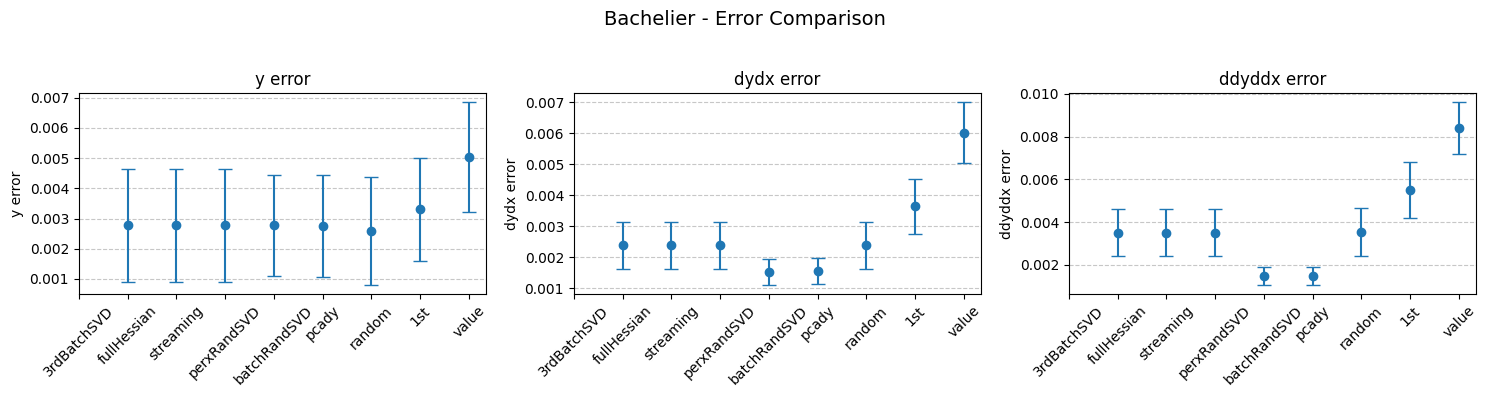

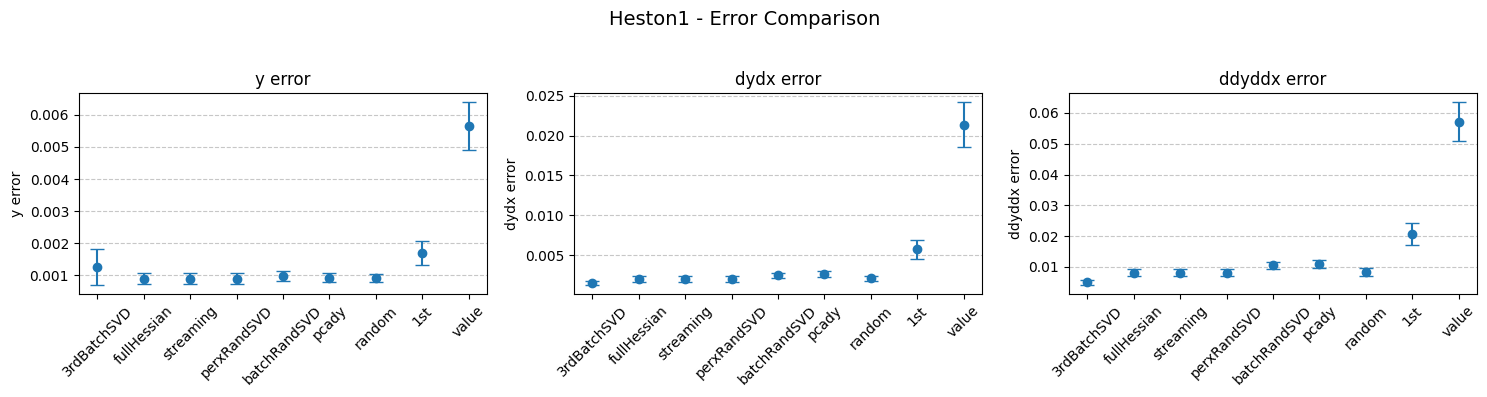

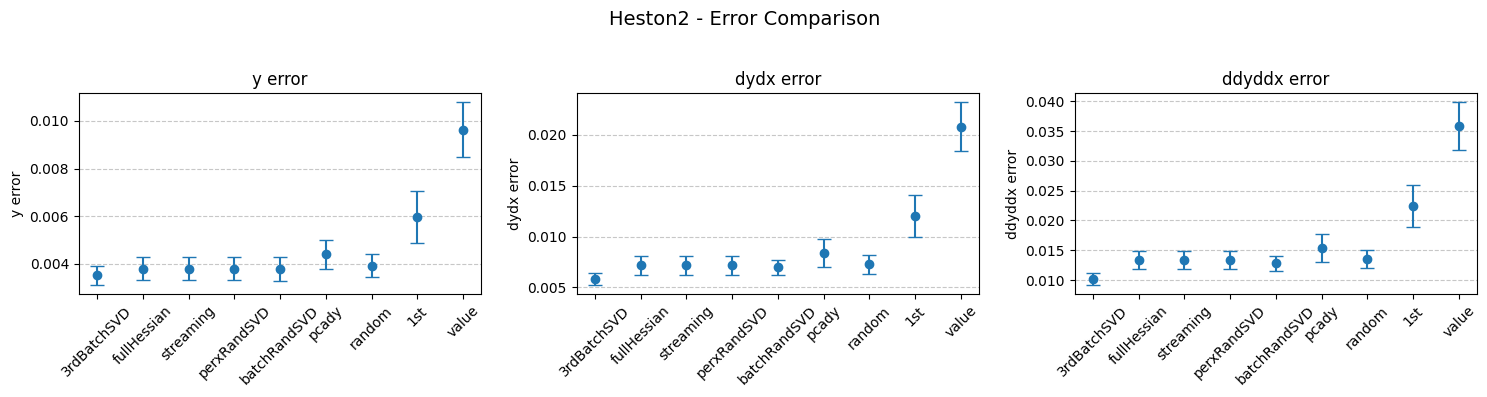

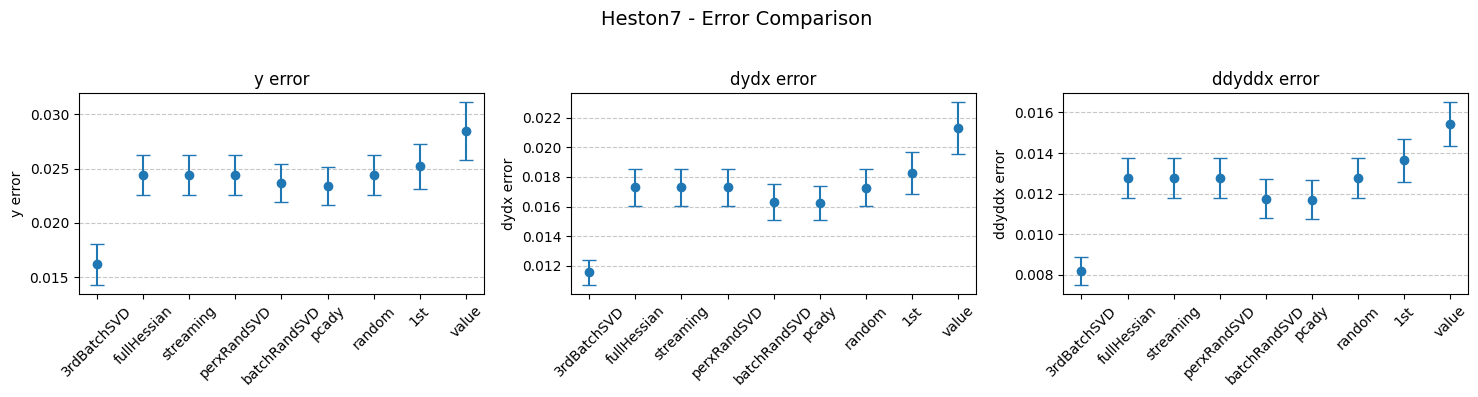

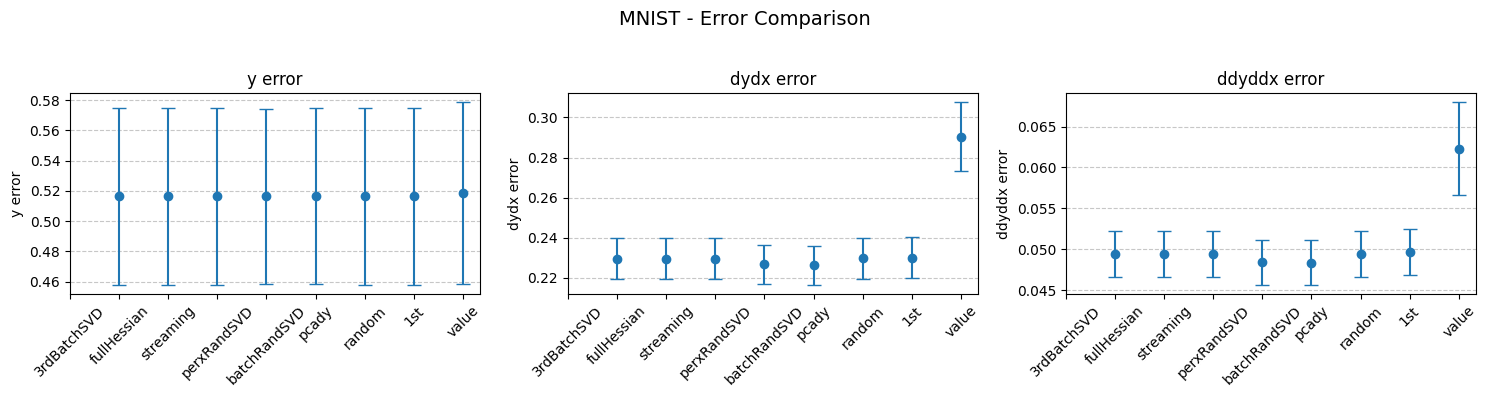

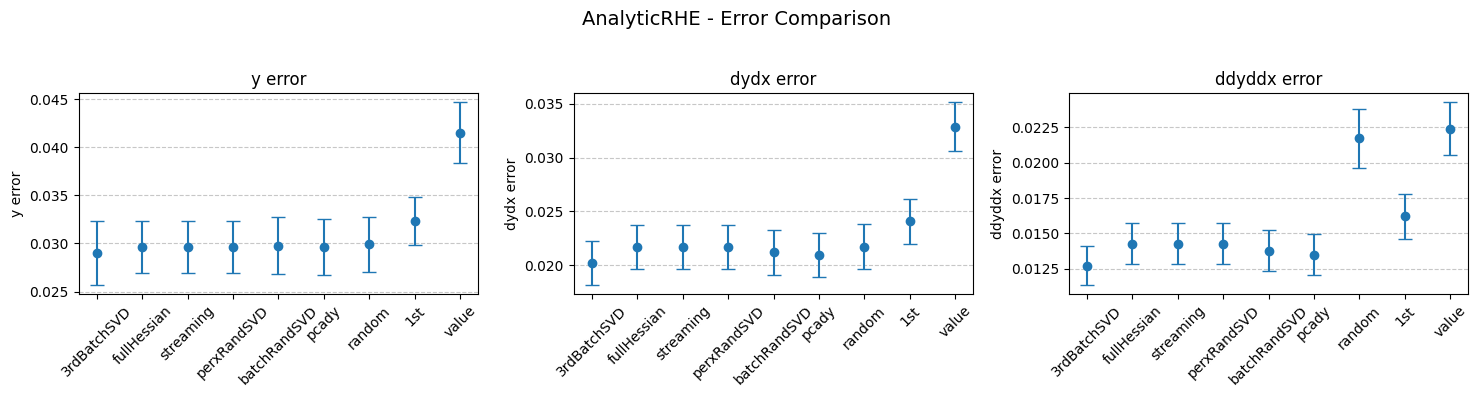

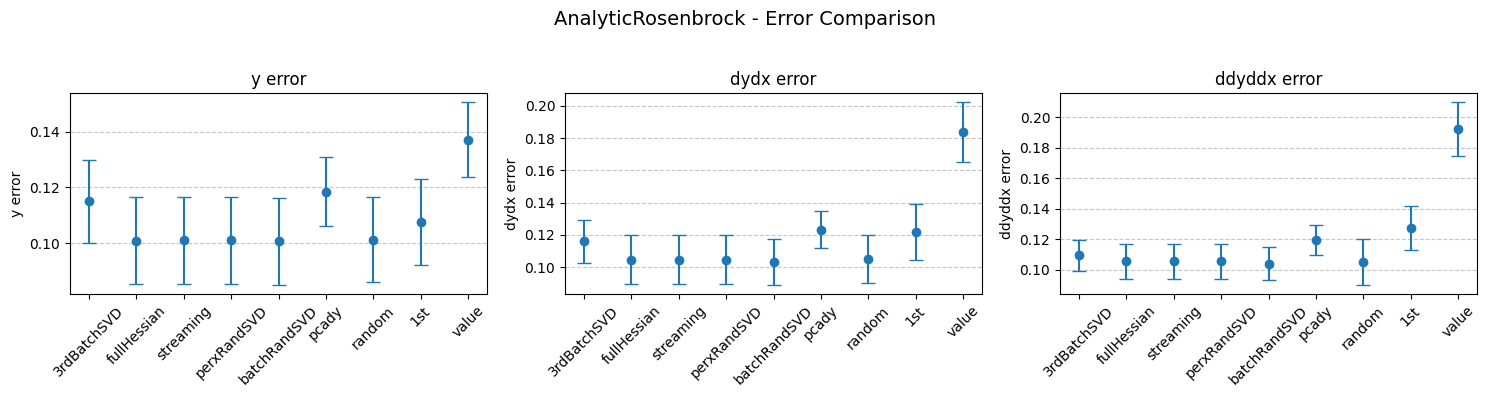

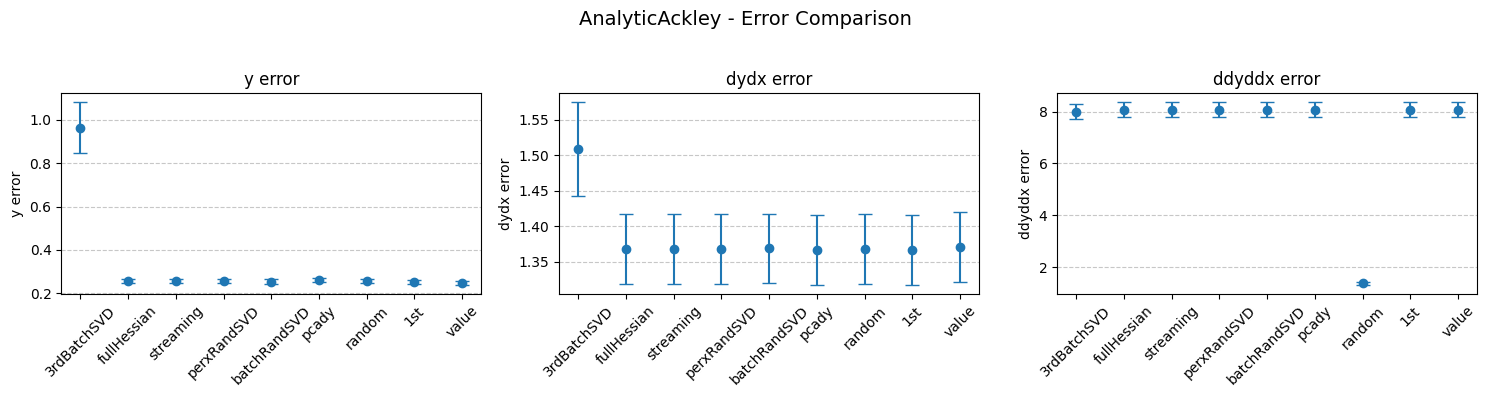

In [12]:
import matplotlib.pyplot as plt
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    error_types = [("y error", "y error"), ("dydx error", "dydx error"), ("ddyddx error", "ddyddx error")]

    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()


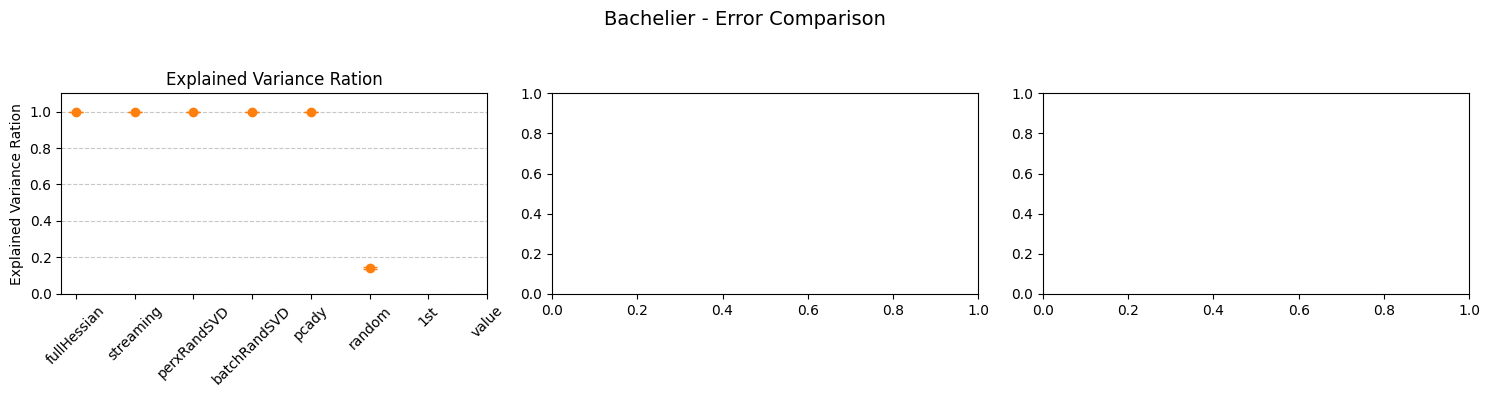

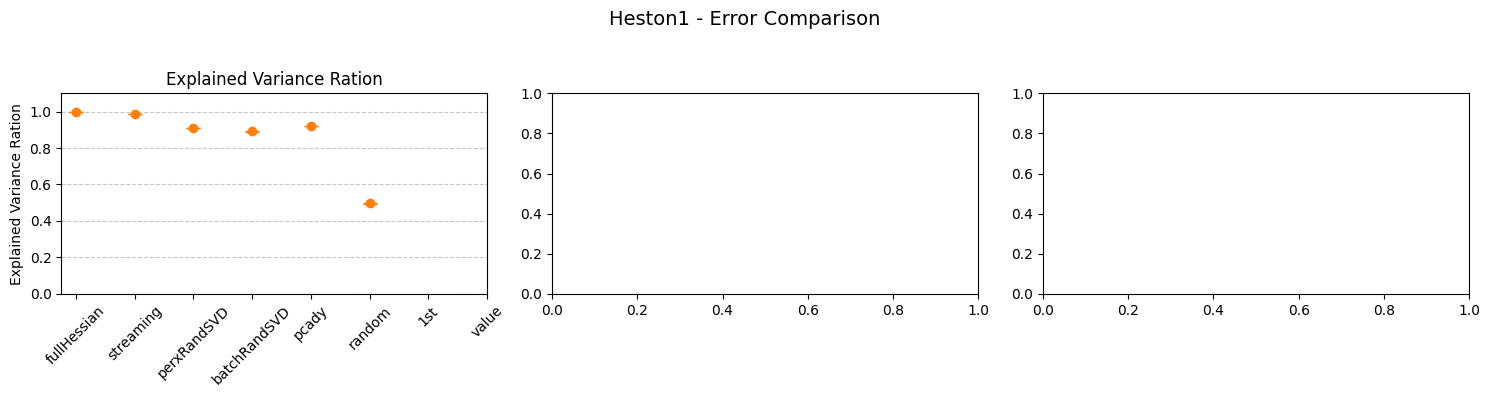

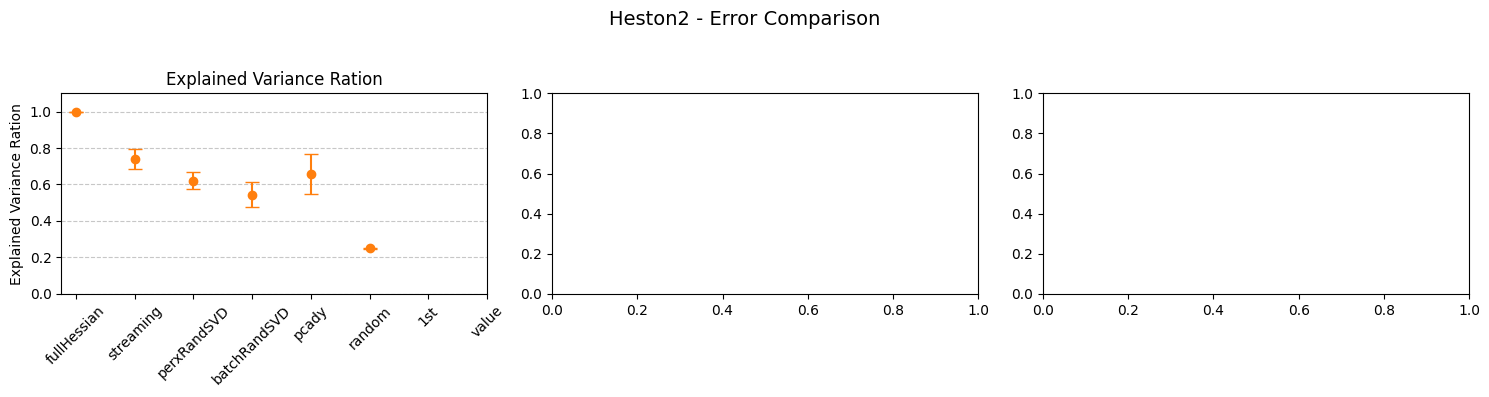

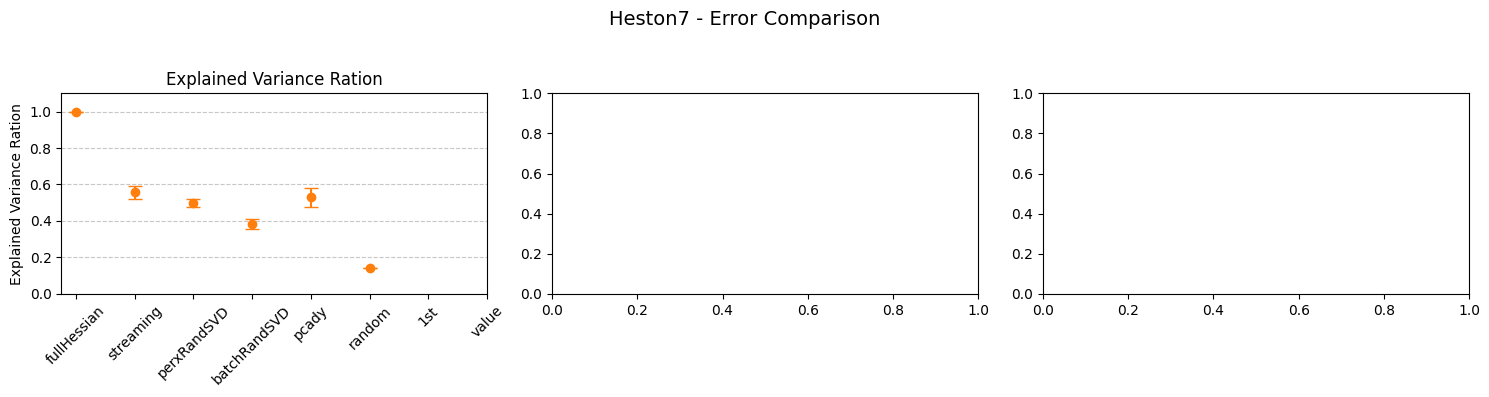

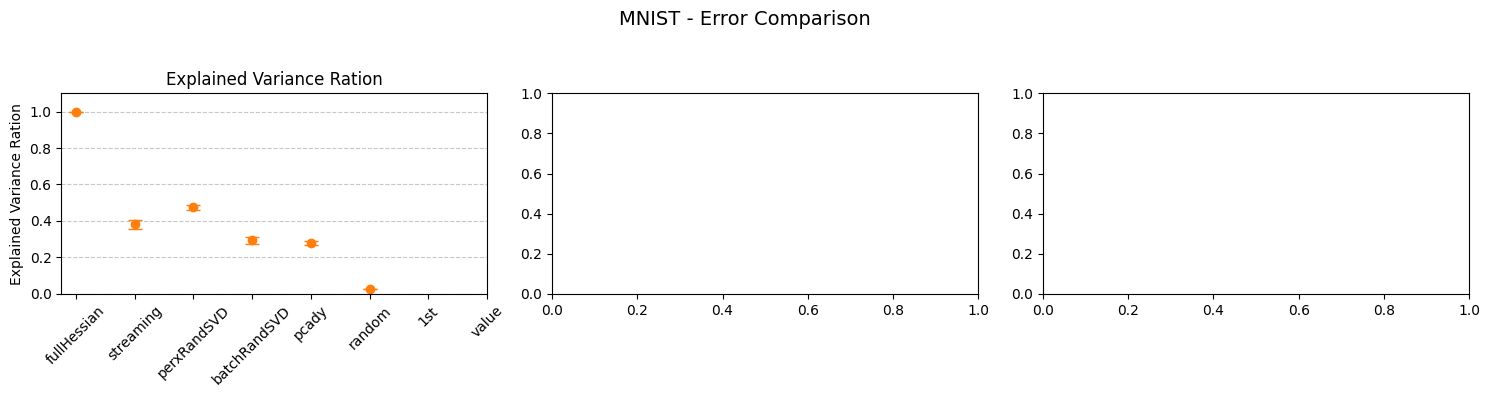

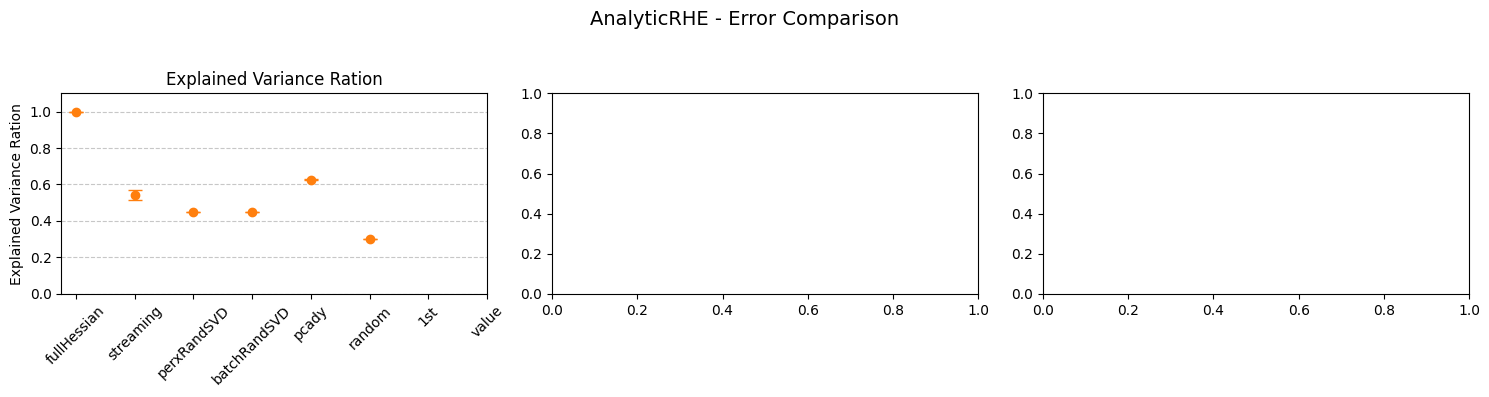

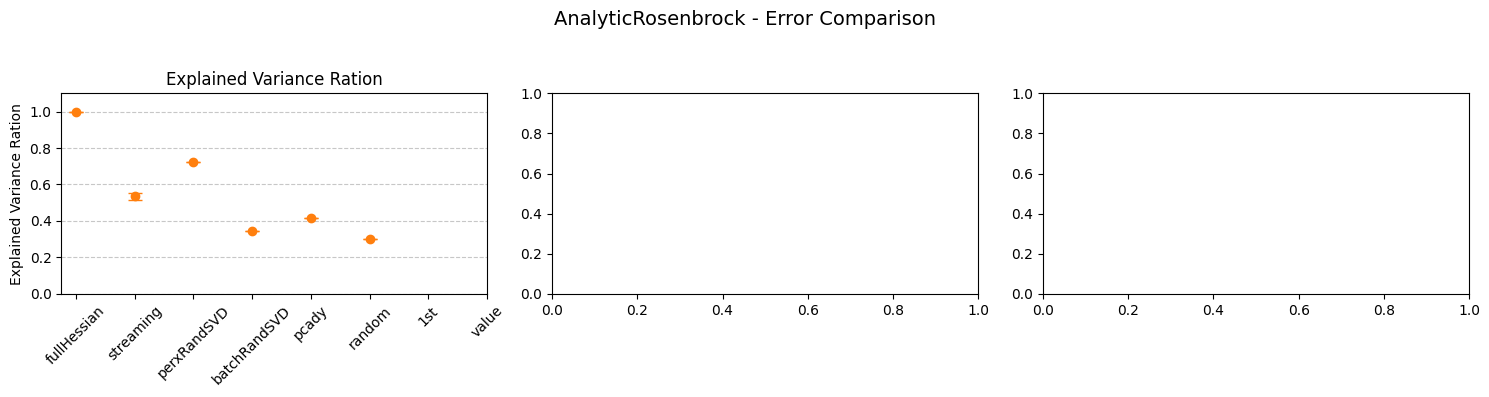

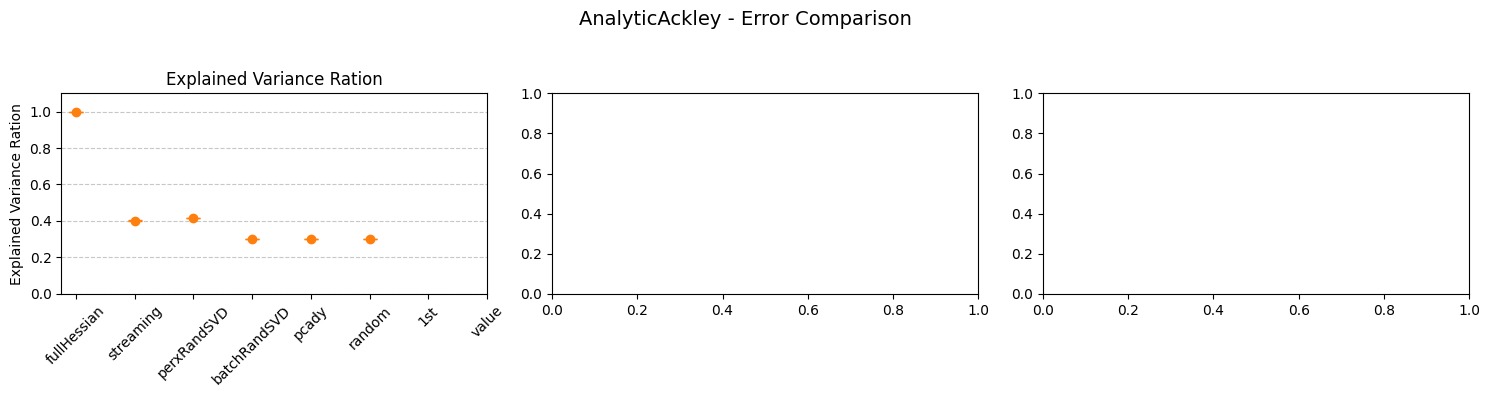

In [5]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
# Create a single figure with 3 subplots (one for each error type) per class

figures = {}

for class_name, class_data in raw_data.items():
    error_types = [("Explained Variance Ration", "evr")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    
    for ax, (display_name, key) in zip(axes, error_types):
        subtypes, means, stds = zip(*class_data[key])
        x = jnp.arange(len(subtypes))
        ax.errorbar(x, means, yerr=stds, fmt='o', capsize=5, color='tab:orange')
        ax.set_xticks(x)
        ax.set_xticklabels(subtypes, rotation=45)
        ax.set_ylabel(display_name)
        ax.set_title(display_name)
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    fig.suptitle(f"{class_name} - Error Comparison", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    figures[class_name] = fig
    plt.show()
